# SpiderNet tutorial: Pancancer example

This notebook demonstrates the **core SpiderNet workflow** on the **Pancancer dataset** and can be used as a **template for applying SpiderNet to a new dataset**.

## Core pipeline
1. **Edit the dataset setup cell**  
   Specify the **input paths**, **resource files**, and key dataset-specific settings.

2. **Check paths and AnnData fields**  
   Verify that all required files, metadata fields, and **AnnData structure** are correctly configured before running the pipeline.

3. **Preprocess the raw data**  
   Convert the input data into the **SpiderNet input format** needed for downstream model training.

4. **Train the model**  
   Run **SpiderNet training** to learn latent **meta-interactions (MIs)** and communication-related representations.

5. **Infer and export results**  
   Generate and save the main outputs, including **MI factors**, **gene / LR loadings**, and other downstream analysis files.

## Optional analyses
- **MI correlation**
- **LR pathway enrichment**
- **sender--receiver cell-type enrichment**

## Before you start

Under `DATA_ROOT`, keep an `adata/` folder with one `.h5ad` file per sample or batch.

Each `.h5ad` should contain:
- Spatial coordinates: `adata.obsm['spatial']`
- Sample IDs: `adata.obs[SAMPLE_ID_COL]`
- Pre-determined cell type labels: `adata.obs[CELL_TYPE_COL]`
- gene symbols in `adata.var_names` (for example `MYC`, `TP53`)



## 0. Dataset setup (edit this cell first)

Put the dataset-specific settings here. In most cases, this is the main cell you need to edit when switching to a new dataset.


In [1]:
from pathlib import Path
import numpy as np

# Paths
DATA_ROOT = Path("D:/SpiderNet/Data/Pancancer")      # path to raw input data
OUTPUT_ROOT = Path("D:/SpiderNet/Results/Pancancer") # path to save outputs and results
ADATA_FOLDER_NAME = "adata_entire"                   # choose from "adata" or "adata_entire"

# Dataset-specific fields
SPECIES = "human"               # "human" or "mouse"
SAMPLE_ID_COL = "SampleID"      # column in adata.obs
CELL_TYPE_COL = "celltype_final" # column in adata.obs
SPATIAL_KEY = "spatial"         # key in adata.obsm

# Preprocessing parameters
N_HVG = 1000
N_HVG_LR = 2000
NUM_NEIGHBORS = 5

# Model parameters
DIM_ENVIR = 11
N_JOBS = 5
MAX_EPOCH = 20000

VERSION = "V1"

# Reference result directory from the subsampled 40-slice training run.
REFERENCE_RESULTS_DIR = Path(
    "D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11"
)

# Trained model checkpoint. Set to a specific file, or leave as None to auto-pick
# the latest model_epoch* checkpoint under REFERENCE_RESULTS_DIR / "Model".
TRAINED_MODEL_PATH = None

# Reuse the exact LR list and gene names saved in the reference results.
USE_REFERENCE_LR_LIST = True
USE_REFERENCE_GENENAMES = True
REFERENCE_LR_LIST_FILENAME = "LR_list.pkl"
REFERENCE_GENENAME_CANDIDATES = ["genenames.pkl", "genenames_train.pkl"]


## 1. Imports and device setup

Load SpiderNet utilities and choose CPU or CUDA.


In [2]:
import gc
import json
import subprocess
import sys

import pandas as pd
import torch

from SpiderNet.utils import *
from SpiderNet.config import *

cuda_available = torch.cuda.is_available()
device = "cuda" if cuda_available else "cpu"
print(f"Using device: {device}")


def release_memory(*var_names, namespace=None, run_gc=True, clear_cuda=True, close_figures=False):
    """
    Delete variables from the provided namespace and optionally trigger
    Python garbage collection / CUDA cache cleanup.
    """
    if namespace is None:
        namespace = globals()

    for name in var_names:
        if name in namespace:
            try:
                del namespace[name]
            except Exception:
                namespace.pop(name, None)

    if close_figures:
        try:
            import matplotlib.pyplot as plt
            plt.close("all")
        except Exception:
            pass

    if run_gc:
        gc.collect()

    if clear_cuda and torch.cuda.is_available():
        torch.cuda.empty_cache()


Using device: cuda


## 2. Build paths from the dataset setup

This cell uses the values from the dataset setup cell above.


In [3]:
paths = PathConfig(
    data_root=DATA_ROOT,
    output_root=OUTPUT_ROOT,
    species=SPECIES,
    version=VERSION,
)

paths


PathConfig(data_root=WindowsPath('D:/SpiderNet/Data/Pancancer'), output_root=WindowsPath('D:/SpiderNet/Results/Pancancer'), species='human', cellchat_db=WindowsPath('D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/SpiderNet/resources/Human_LR_pairs_Cellchatdb.csv'), scseqcomm_db=WindowsPath('D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/SpiderNet/resources/Human_LR_pairs_scSeqComm.csv'), version='V1')

In [4]:
# Copy sample IDs and cell type labels to the expected obs fields if needed,
# and check that the expected fields are present.
import scanpy as sc

adata_dir = Path(DATA_ROOT) / ADATA_FOLDER_NAME
sample_files = sorted(adata_dir.glob("*.h5ad"))

updated_rows = []

for sample_path in sample_files:
    adata_i = sc.read_h5ad(sample_path)

    ok_sample_id_col = SAMPLE_ID_COL in adata_i.obs.columns
    ok_cell_type_col = CELL_TYPE_COL in adata_i.obs.columns

    if ok_sample_id_col:
        adata_i.obs["SAMPLE_ID"] = adata_i.obs[SAMPLE_ID_COL].copy()
    if ok_cell_type_col:
        adata_i.obs["CELL_TYPE"] = adata_i.obs[CELL_TYPE_COL].copy()

    adata_i.write_h5ad(sample_path)

    updated_rows.append({
        "file": sample_path.name,
        f"has obs['{SAMPLE_ID_COL}']": ok_sample_id_col,
        f"has obs['{CELL_TYPE_COL}']": ok_cell_type_col,
        f"created obs['SAMPLE_ID']": ok_sample_id_col,
        f"created obs['CELL_TYPE']": ok_cell_type_col,
    })

display(pd.DataFrame(updated_rows))


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


,file,has obs['SampleID'],has obs['celltype_final'],created obs['SAMPLE_ID'],created obs['CELL_TYPE']
0,HumanBreastCancerPatient1_subslice_0_annotated...,False,True,False,True
1,HumanBreastCancerPatient1_subslice_10_annotate...,False,True,False,True
2,HumanBreastCancerPatient1_subslice_11_annotate...,False,True,False,True
3,HumanBreastCancerPatient1_subslice_12_annotate...,False,True,False,True
4,HumanBreastCancerPatient1_subslice_13_annotate...,False,True,False,True
...,...,...,...,...,...
155,HumanUterineCancerPatient1_subslice_5_annotate...,False,True,False,True
156,HumanUterineCancerPatient1_subslice_6_annotate...,False,True,False,True
157,HumanUterineCancerPatient1_subslice_7_annotate...,False,True,False,True
158,HumanUterineCancerPatient1_subslice_8_annotate...,False,True,False,True


### Check paths and AnnData fields

Use the next cell to confirm that paths exist and the first `.h5ad` file has the expected fields.


In [5]:
adata_dir = Path(DATA_ROOT) / ADATA_FOLDER_NAME
sample_files = sorted(adata_dir.glob("*.h5ad"))
sample_path = sample_files[0] if sample_files else None

rows = [
    {"item": "DATA_ROOT", "value": str(DATA_ROOT), "ok": Path(DATA_ROOT).exists()},
    {"item": "OUTPUT_ROOT", "value": str(OUTPUT_ROOT), "ok": Path(OUTPUT_ROOT).exists()},
    {"item": "ADATA_FOLDER_NAME", "value": ADATA_FOLDER_NAME, "ok": adata_dir.exists()},
    {"item": "CellChat DB", "value": str(paths.cellchat_db), "ok": Path(paths.cellchat_db).exists()},
    {"item": "scSeqComm DB", "value": str(paths.scseqcomm_db), "ok": Path(paths.scseqcomm_db).exists()},
    {"item": "adata folder", "value": str(adata_dir), "ok": adata_dir.exists()},
    {"item": "number of .h5ad files", "value": len(sample_files), "ok": len(sample_files) > 0},
    {"item": "REFERENCE_RESULTS_DIR", "value": str(REFERENCE_RESULTS_DIR), "ok": REFERENCE_RESULTS_DIR.exists()},
]

if sample_path is not None:
    adata_example = sc.read_h5ad(sample_path, backed="r")
    rows.extend([
        {"item": "example file", "value": sample_path.name, "ok": True},
        {"item": f"obs['{SAMPLE_ID_COL}']", "value": SAMPLE_ID_COL, "ok": SAMPLE_ID_COL in adata_example.obs.columns},
        {"item": f"obs['{CELL_TYPE_COL}']", "value": CELL_TYPE_COL, "ok": CELL_TYPE_COL in adata_example.obs.columns},
        {"item": f"obsm['{SPATIAL_KEY}']", "value": SPATIAL_KEY, "ok": SPATIAL_KEY in adata_example.obsm_keys()},
    ])
    adata_example.file.close()
else:
    rows.append({"item": "example file", "value": "No .h5ad file found", "ok": False})

display(pd.DataFrame(rows))


C:\Users\junji\AppData\Local\Temp\ipykernel_19224\837918054.py:22: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  {"item": f"obsm['{SPATIAL_KEY}']", "value": SPATIAL_KEY, "ok": SPATIAL_KEY in adata_example.obsm_keys()},


,item,value,ok
0,DATA_ROOT,D:\SpiderNet\Data\Pancancer,True
1,OUTPUT_ROOT,D:\SpiderNet\Results\Pancancer,True
2,ADATA_FOLDER_NAME,adata_entire,True
3,CellChat DB,D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\...,True
4,scSeqComm DB,D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\...,True
5,adata folder,D:\SpiderNet\Data\Pancancer\adata_entire,True
6,number of .h5ad files,160,True
7,REFERENCE_RESULTS_DIR,D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Re...,True
8,example file,HumanBreastCancerPatient1_subslice_0_annotated...,True
9,obs['SampleID'],SampleID,False


## 3. Build preprocessing and training configs

These values are taken from the dataset setup cell.


In [6]:
preprocess_cfg = PreprocessConfig(
    n_hvg=N_HVG,
    n_hvg_lr=N_HVG_LR,
    num_neighbors=NUM_NEIGHBORS
)

train_cfg = TrainingConfig(
    dim_envir=DIM_ENVIR,
    n_jobs=N_JOBS,
    max_epoch=MAX_EPOCH,
    version=VERSION
)

run_dirs = paths.ensure_dirs(
    dim_envir=train_cfg.dim_envir
)
print(run_dirs)

with open(paths.output_root / "run_dirs.json", "w", encoding="utf-8") as handle:
    json.dump({k: str(v) for k, v in run_dirs.items()}, handle, indent=2)


{'run_dir': WindowsPath('D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11'), 'model_dir': WindowsPath('D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11/Model')}


In [7]:
import re

def resolve_reference_genename_path(reference_results_dir, candidates):
    for candidate in candidates:
        candidate_path = reference_results_dir / candidate
        if candidate_path.exists():
            return candidate_path
    raise FileNotFoundError(
        "Cannot find any reference gene-name file under "
        f"{reference_results_dir}. Checked: {candidates}"
    )


def resolve_model_checkpoint(reference_results_dir, explicit_model_path=None):
    if explicit_model_path is not None:
        explicit_model_path = Path(explicit_model_path)
        if not explicit_model_path.exists():
            raise FileNotFoundError(f"Model checkpoint does not exist: {explicit_model_path}")
        return explicit_model_path

    search_dirs = []
    if (reference_results_dir / "Model").exists():
        search_dirs.append(reference_results_dir / "Model")
    search_dirs.append(reference_results_dir)

    candidates = []
    for search_dir in search_dirs:
        for pattern in ["model_epoch*", "*checkpoint*", "*.pt", "*.pth", "*.pkl"]:
            candidates.extend(search_dir.glob(pattern))

    candidates = [p for p in candidates if p.is_file()]
    if len(candidates) == 0:
        raise FileNotFoundError(
            "Cannot find a trained model checkpoint under "
            f"{reference_results_dir} or {reference_results_dir / 'Model'}"
        )

    def extract_epoch(path):
        match = re.search(r"epoch(\d+)", path.stem)
        return int(match.group(1)) if match else -1

    candidates = sorted(
        candidates,
        key=lambda p: (extract_epoch(p), p.stat().st_mtime)
    )
    return candidates[-1]


reference_lr_list_path = (
    REFERENCE_RESULTS_DIR / REFERENCE_LR_LIST_FILENAME
    if USE_REFERENCE_LR_LIST else None
)
if reference_lr_list_path is not None and not reference_lr_list_path.exists():
    raise FileNotFoundError(f"Reference LR list not found: {reference_lr_list_path}")

reference_genename_path = (
    resolve_reference_genename_path(REFERENCE_RESULTS_DIR, REFERENCE_GENENAME_CANDIDATES)
    if USE_REFERENCE_GENENAMES else None
)

reference_model_path = resolve_model_checkpoint(
    REFERENCE_RESULTS_DIR,
    TRAINED_MODEL_PATH
)

display(pd.DataFrame([
    {
        "item": "reference_lr_list_path",
        "value": str(reference_lr_list_path) if reference_lr_list_path is not None else "None",
        "ok": True if reference_lr_list_path is None else reference_lr_list_path.exists(),
    },
    {
        "item": "reference_genename_path",
        "value": str(reference_genename_path) if reference_genename_path is not None else "None",
        "ok": True if reference_genename_path is None else reference_genename_path.exists(),
    },
    {
        "item": "reference_model_path",
        "value": str(reference_model_path),
        "ok": reference_model_path.exists(),
    },
]))


,item,value,ok
0,reference_lr_list_path,D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Re...,True
1,reference_genename_path,D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Re...,True
2,reference_model_path,D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Re...,True


## 4. Preprocess raw data and load processed data

Convert raw input data into SpiderNet-ready objects and save them to the run directory.


In [ ]:
subprocess.run(
    [
        sys.executable,
        "-m",
        "SpiderNet.dataloading_Pancancer",
        str(paths.data_root),
        str(preprocess_cfg.n_hvg),
        str(preprocess_cfg.n_hvg_lr),
        str(paths.cellchat_db),
        str(paths.scseqcomm_db),
        str(preprocess_cfg.num_neighbors),
        str(paths.output_root),
        str(str(run_dirs["run_dir"]) + "/"),
        str(reference_lr_list_path) if reference_lr_list_path is not None else "None",
        str(reference_genename_path) if reference_genename_path is not None else "None",
        ADATA_FOLDER_NAME,
    ],
    check=True,
)


Reloads processed objects for training and downstream analysis.

Check that the number of batches, LR pairs, and training genes is reasonable.


In [8]:
from SpiderNet.io import load_processed_data
processed = load_processed_data(run_dirs["run_dir"])

print("Number of batches:", len(processed.spidernet_data))
print("Number of LR pairs:", len(processed.lr_list))
print("Number of training genes:", processed.genenames_train.shape[0])


Number of batches: 160
Number of LR pairs: 106
Number of training genes: 500


Check whether the processed data are non-empty and internally consistent before training.


In [9]:
summary_rows = []
for i in range(len(processed.adata_list)):
    adata_i = processed.adata_list[i]
    edge_index_max = torch.max(processed.spidernet_data[i]["edge_index"]).cpu().item()
    summary_rows.append(
        {
            "batch_index": i,
            "n_cells": adata_i.n_obs,
            "n_genes": adata_i.n_vars,
            "edge_index_max": edge_index_max,
            "edge_index_matches_n_cells": adata_i.n_obs == (edge_index_max + 1),
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

issues = []
if len(processed.spidernet_data) == 0:
    issues.append("No processed batches were loaded.")
if len(processed.lr_list) == 0:
    issues.append("No ligand-receptor pairs were retained.")
if processed.genenames_train.shape[0] == 0:
    issues.append("No training genes were retained.")
if not summary_df["edge_index_matches_n_cells"].all():
    issues.append("At least one batch has an edge index / cell-count mismatch.")

if issues:
    print("Sanity check flagged the following issues:")
    for issue in issues:
        print("-", issue)
else:
    print("Sanity checks passed. The processed data appear internally consistent.")


,batch_index,n_cells,n_genes,edge_index_max,edge_index_matches_n_cells
0,0,47423,500,47422,True
1,1,40606,500,40605,True
2,2,30419,500,30418,True
3,3,43955,500,43954,True
4,4,30654,500,30653,True
...,...,...,...,...,...
155,155,47838,500,47837,True
156,156,28462,500,28461,True
157,157,47280,500,47279,True
158,158,31677,500,31676,True


Sanity checks passed. The processed data appear internally consistent.


## 5. Build and train the SpiderNet model

Initialize the model using the processed data and training settings.


In [10]:
from SpiderNet.api import build_model
model = build_model(
    processed=processed,
    train_cfg=train_cfg,
    device=device,
)

print(model)


Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 4070
SpiderNet_model(
  (dropout_fun): Dropout(p=0.1, inplace=False)
  (Relu): ReLU()
  (Sigmoid): Sigmoid()
  (enc_factor_envir_pre_receiver): Sequential(
    (0): Linear(in_features=500, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
  )
  (enc_factor_envir_pre_sender): Sequential(
    (0): Linear(in_features=500, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
  )
  (enc_factor_envir): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=11, bias=True)
  )
)


Runs model training and saves checkpoints.

In [11]:
checkpoint = torch.load(reference_model_path, map_location=device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
elif isinstance(checkpoint, dict):
    state_dict = checkpoint
else:
    raise ValueError(
        "Unsupported checkpoint format. Expected a state-dict-like object, "
        f"but got: {type(checkpoint)}"
    )

load_result = model.load_state_dict(state_dict, strict=True)
model = model.to(device)
model.eval()

print(f"Loaded pretrained model from: {reference_model_path}")
print(load_result)


release_memory(
    "checkpoint",
    "state_dict",
    "load_result",
    namespace=globals(),
    run_gc=True,
    clear_cuda=False
)


Loaded pretrained model from: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\Model\model_epoch19999.pth
<All keys matched successfully>


### Extract the inferred meta-interactions and loadings

This step generates the main outputs:
- MI activities
- LR loadings
- sender loadings
- receiver loadings


In [12]:
from SpiderNet.api import infer_meta_interactions, normalize_outputs
results = infer_meta_interactions(model=model, processed=processed)
results = normalize_outputs(results)

print("Factor_envir shape:", results["factor_envir"].shape)
print("LR loading shape:", results["loading_lr"].shape)
print("Receiver loading shape:", results["loading_receiver"].shape)
print("Sender loading shape:", results["loading_sender"].shape)


Factor_envir shape: (23538755, 11)
LR loading shape: (11, 106)
Receiver loading shape: (11, 500)
Sender loading shape: (11, 500)


In [13]:
np.sum(results["loading_receiver"],axis = 1)

array([0.0000000e+00, 1.8365070e+02, 1.2842408e-01, 1.3392618e+02,
       1.3642932e+02, 5.6588569e+00, 4.4734073e-01, 3.1299084e-01,
       1.5677444e+02, 4.1735625e+00, 5.3045862e+02], dtype=float32)

Saves the main outputs and config files.

In [14]:
from SpiderNet.api import export_results
export_results(
    results=results,
    processed=processed,
    output_dir=run_dirs["run_dir"],
)

with open(run_dirs["model_dir"] / "SpiderNet_model_config.json", "w", encoding="utf-8") as handle:
    json.dump(train_cfg.to_dict(), handle, indent=2)

with open(run_dirs["model_dir"] / "SpiderNet_preprocess_config.json", "w", encoding="utf-8") as handle:
    json.dump(preprocess_cfg.to_dict(), handle, indent=2)

with open(run_dirs["run_dir"] / "Pancancer_inference_source_config.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "adata_folder_name": ADATA_FOLDER_NAME,
            "reference_results_dir": str(REFERENCE_RESULTS_DIR),
            "reference_lr_list_path": str(reference_lr_list_path) if reference_lr_list_path is not None else None,
            "reference_genename_path": str(reference_genename_path) if reference_genename_path is not None else None,
            "reference_model_path": str(reference_model_path),
        },
        handle,
        indent=2,
    )

print(f"Results saved to: {run_dirs['run_dir']}")


# The downstream analysis cells read results from disk, so the in-memory
# result dictionary and model object can be released here.
release_memory(
    "results",
    "model",
    namespace=globals(),
    run_gc=True,
    clear_cuda=True
)


Results saved to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11


## Key output files

Most important outputs:
- `Factor_envir_use.npy`
- `loading_LR_use.npy`
- `loading_sender_use.npy`
- `loading_receiver_use.npy`

Check these before running optional analyses.


## Optional downstream analyses

The remaining sections help interpret results, but are not required to run SpiderNet on a new dataset.


## Optional 1. MI correlation analysis

Explores relationships among inferred meta-interactions.


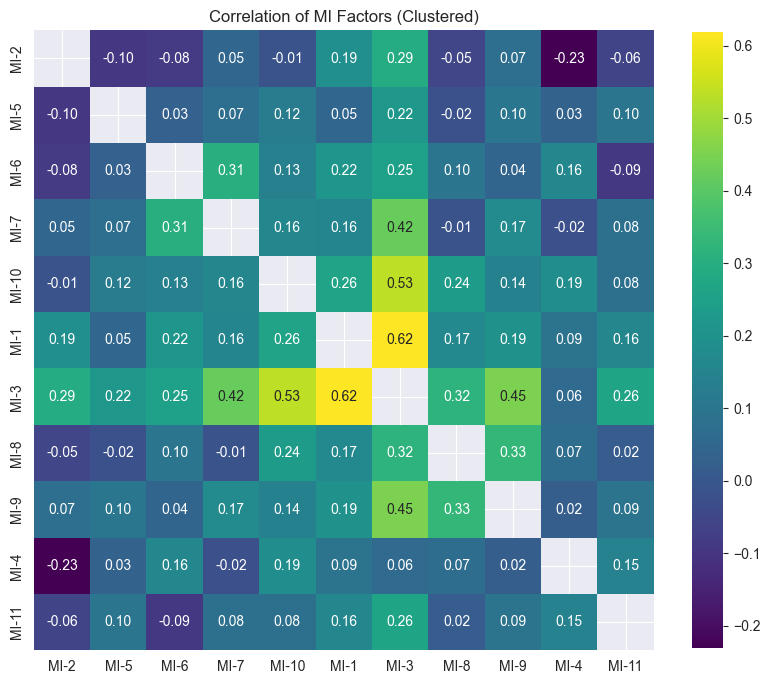

✅ Saved heatmap to D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI_correlation_heatmap_clustered.png


In [15]:
from SpiderNet.analysis import MI_correlation

mi_results = MI_correlation(run_dirs['run_dir'], run_dirs['run_dir'] / "Factor_envir_use.npy", show=True)


release_memory('mi_results', namespace=globals(), run_gc=True, clear_cuda=False)


## Optional 2. LR loading-based pathway enrichment

Interprets each MI using ligand--receptor pathway content.


ANGPT: 1 LR pairs (filtered out)
CCL: 7 LR pairs (kept)
PD-L1: 1 LR pairs (filtered out)
CD40: 3 LR pairs (kept)
CD70: 1 LR pairs (filtered out)
CD80: 1 LR pairs (filtered out)
CD86: 1 LR pairs (filtered out)
CDH: 1 LR pairs (filtered out)
CDH1: 2 LR pairs (kept)
CDH5: 1 LR pairs (filtered out)
COLLAGEN: 6 LR pairs (kept)
CSF: 1 LR pairs (filtered out)
CXCL: 9 LR pairs (kept)
EGF: 2 LR pairs (kept)
FGF: 6 LR pairs (kept)
FN1: 4 LR pairs (kept)
MHC-I: 4 LR pairs (kept)
MHC-II: 6 LR pairs (kept)
ICAM: 5 LR pairs (kept)
ITGB2: 2 LR pairs (kept)
LAMININ: 4 LR pairs (kept)
GALECTIN: 1 LR pairs (filtered out)
NCAM: 2 LR pairs (kept)
PDL2: 1 LR pairs (filtered out)
PDGF: 5 LR pairs (kept)
PECAM1: 1 LR pairs (filtered out)
CD45: 2 LR pairs (kept)
SPP1: 3 LR pairs (kept)
TGFb: 9 LR pairs (kept)
TENASCIN: 1 LR pairs (filtered out)
VCAM: 3 LR pairs (kept)
VTN: 1 LR pairs (filtered out)
WNT: 8 LR pairs (kept)
ncWNT: 1 LR pairs (filtered out)


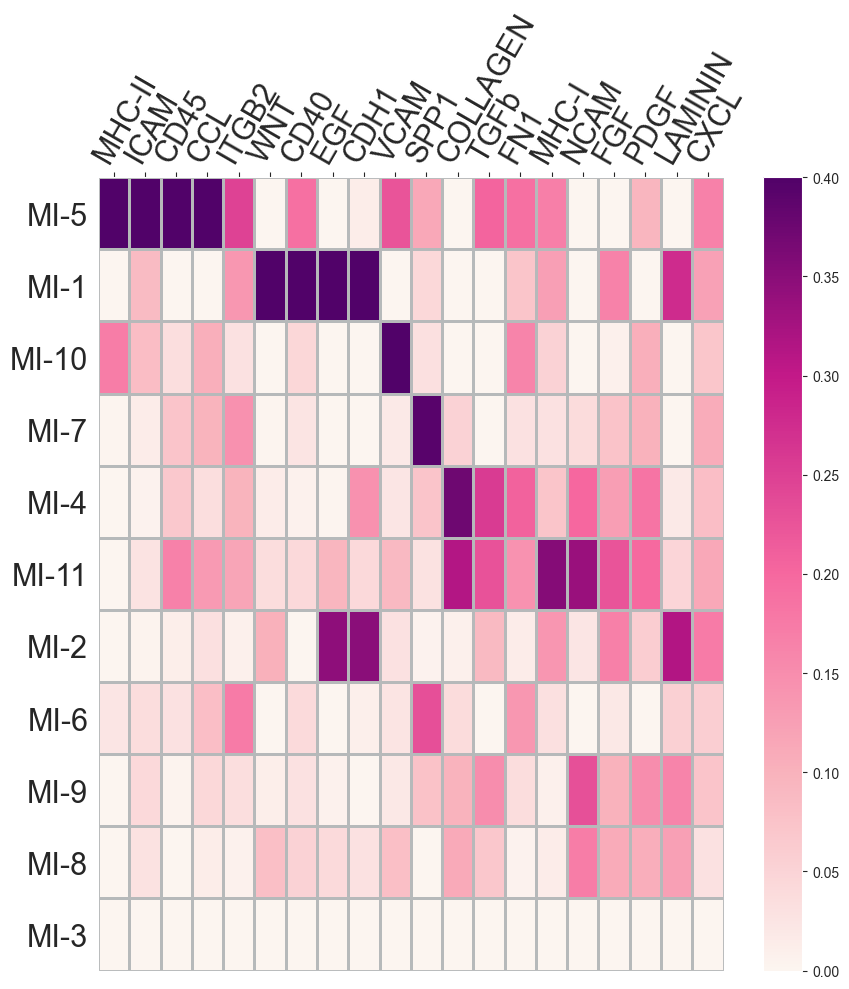

{'loading_LR_use_df':        ANGPT2 -> ITGA5+ITGB1  CCL3 -> CCR1  CCL3 -> CCR5  CCL5 -> CCR1  \
 MI-1            0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
 MI-2            0.000000e+00  2.058221e-02  1.653471e-02  0.000000e+00   
 MI-3            7.108109e-08  3.579353e-08  1.952994e-08  5.801368e-08   
 MI-4            2.111437e-01  1.490289e-02  1.633427e-02  2.360118e-02   
 MI-5            0.000000e+00  1.579555e-01  6.902444e-02  6.224200e-01   
 MI-6            1.283539e-01  3.670269e-02  1.400368e-02  5.372263e-02   
 MI-7            1.109791e-01  6.608034e-02  2.978176e-02  5.236213e-02   
 MI-8            6.404980e-02  0.000000e+00  0.000000e+00  3.830322e-02   
 MI-9            5.021538e-02  2.668520e-02  7.904904e-03  3.479898e-02   
 MI-10           0.000000e+00  3.881872e-02  3.310949e-02  7.252821e-02   
 MI-11           1.081478e-01  5.268963e-02  2.649402e-02  1.131212e-01   
 
        CCL5 -> CCR4  CCL5 -> CCR5  CCL7 -> CCR1  CCL8 -> CCR1  CD274 -> PDCD

In [16]:
from SpiderNet.analysis import LRLoading_enrichment
LRLoading_enrichment(
    loading_LR_use_path=run_dirs['run_dir'] / "loading_LR_use.npy",
    lr_list_path=run_dirs['run_dir'] / "LR_list.pkl",
    lr_list_cellchatdb_path=run_dirs['run_dir'] / "LR_list_cellchatdb.pkl",
    lr_meta_cellchatdb_path=run_dirs['run_dir'] / "LR_meta_cellchatdb.pkl",
    Factor_envir_use_path=run_dirs['run_dir'] / "Factor_envir_use.npy",
    file_savepath_main=run_dirs['run_dir'],
    show=True,
    min_lr_pairs_per_pathway = 2
)


## Optional 3. Sender-cell-type--receiver-cell-type interaction analysis

Summarizes MI enrichment across sender--receiver cell-type pairs.


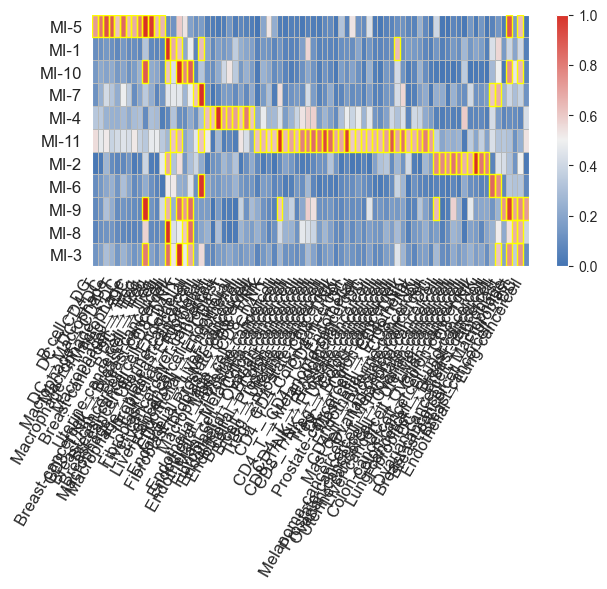

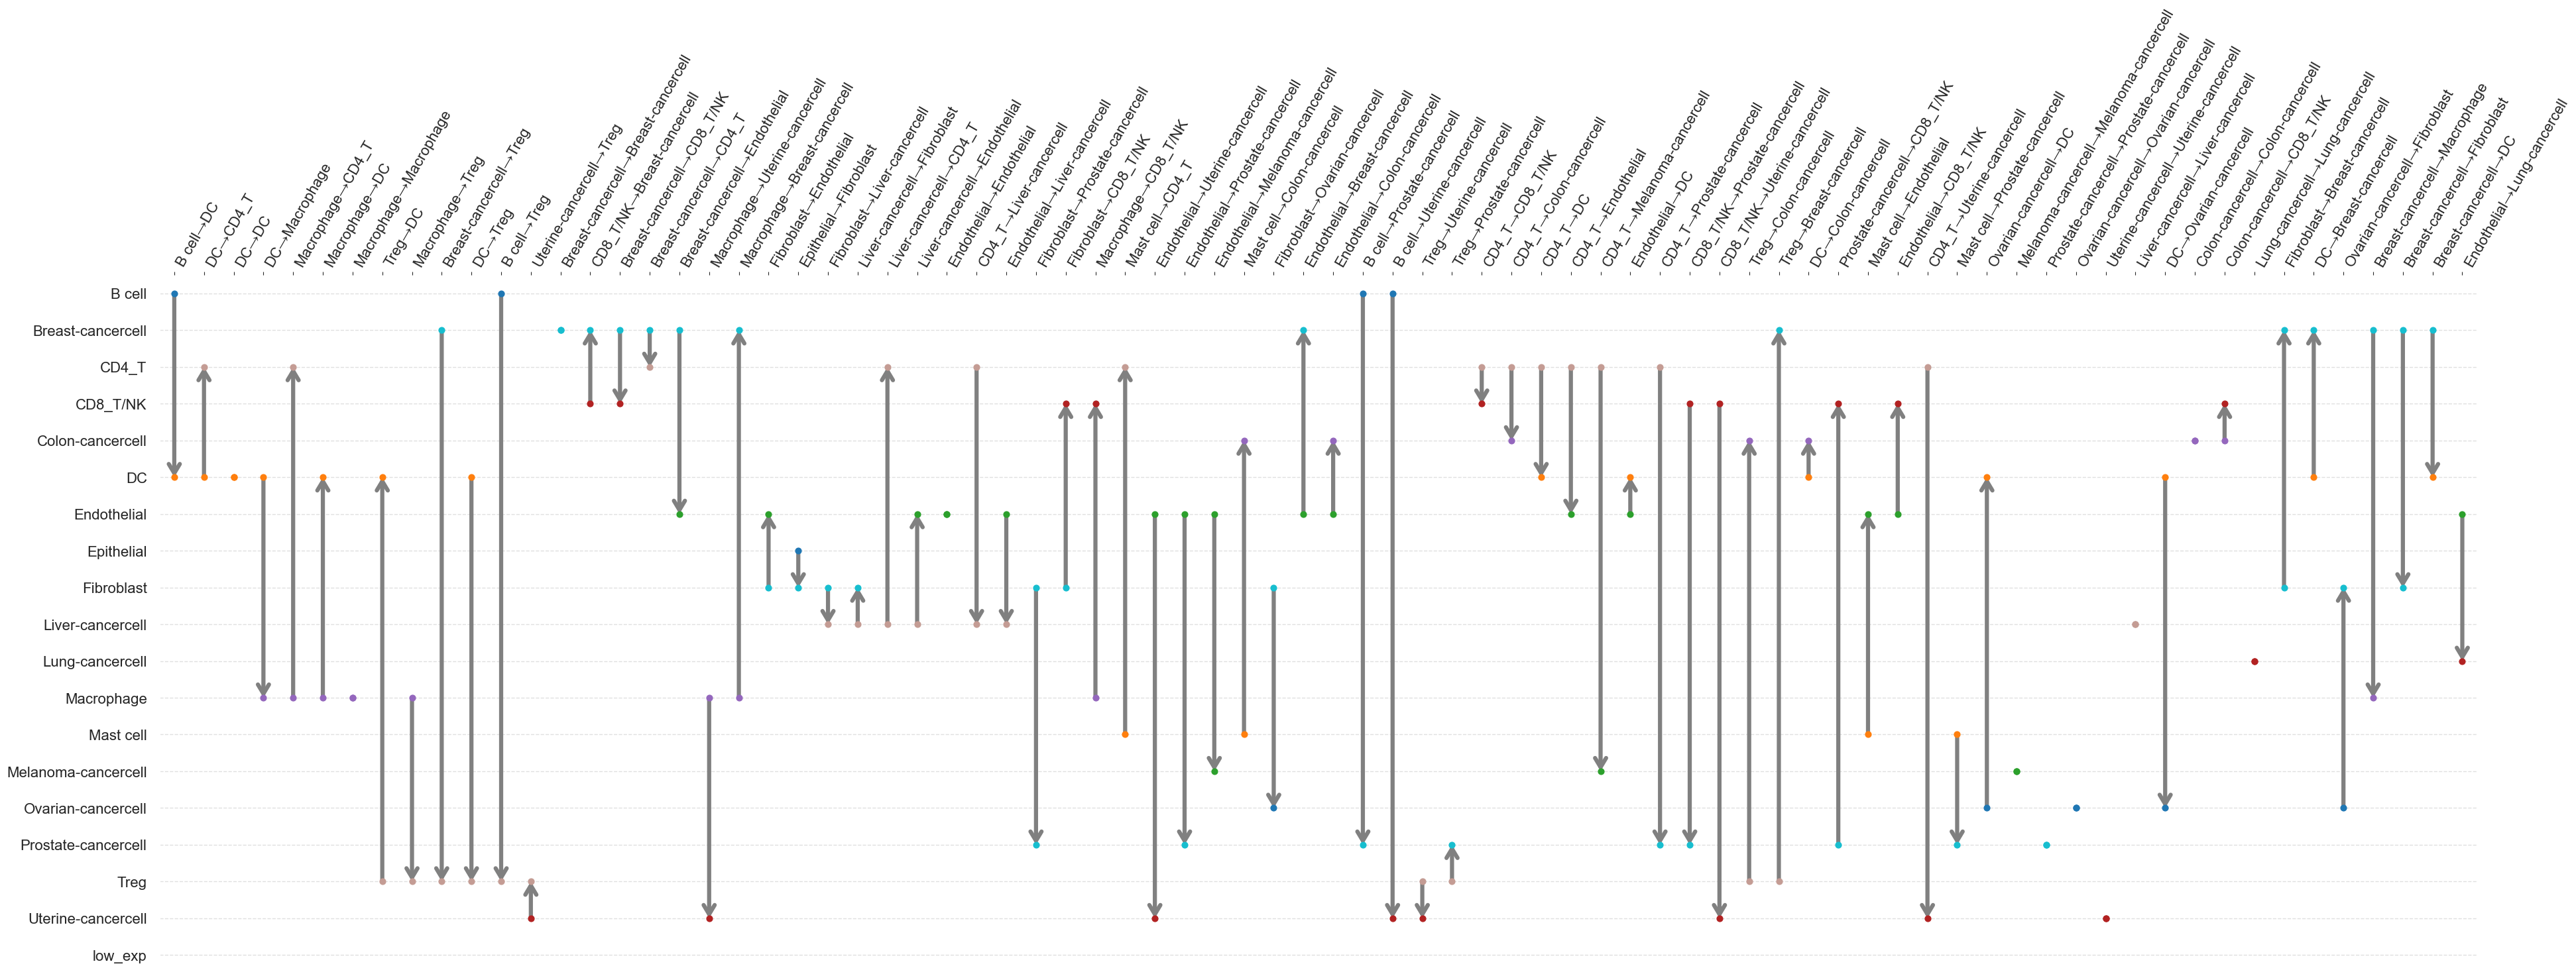

D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\analysis.py:1077: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.7235049605369568' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Avg_MI_cellclass_pair_merge_zscored_ctagg_sender.iloc[idx, :] = list(
D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\analysis.py:1077: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5761411190032959' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Avg_MI_cellclass_pair_merge_zscored_ctagg_sender.iloc[idx, :] = list(
D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\analysis.py:1077: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2895810008049011' has dtype inc

{'Avg_MI_cellclass_pair_merge_use_csv': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Avg_MI_cellclass_pair_merge_use.csv',
 'Avg_MI_cellclass_pair_png': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Avg_MI_cellclass_pair.png',
 'Avg_MI_cellclass_pair_onlymalignant_png': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Avg_MI_cellclass_pair_onlymalignant_highlight.png',
 'Sender_vs_Receiver_scatter_png': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Sender_vs_Receiver_MI_Strength.png',
 'Celltype_pair_example_png': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Celltype_pair_example.png',
 'Agg_heatmap_png': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Avg_MI_cellclass_pair_agg.png',
 'Site_dotplot_png': None,
 'Site_dotplot_top_hits_csv': None,
 'Agg_sender_receiver_csv': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Avg_MI_cellclass_pair_merge_zscored_ctagg.csv',

In [17]:
from SpiderNet.analysis import MI_Celltypepair_enrichment
MI_Celltypepair_enrichment(
    SpiderNet_data_pyg_list_path=run_dirs['run_dir'] / "SpiderNet_data_pyg_list.pkl",
    Factor_envir_use_path=run_dirs['run_dir'] / "Factor_envir_use.npy",
    file_savepath_main=run_dirs['run_dir'],
    metadata_sample_path="None",
    LR_loading_pathway_path=run_dirs['run_dir'] / "LR_loading_pathway.csv",
    dim_envir=train_cfg.dim_envir,
    MIlevel_agg_threshold=0.6,
    batch_cell_unique_path=run_dirs['run_dir'] / "batch_cell_unique.pkl",
    adata_list_path=run_dirs['run_dir'] / "adata_list.pkl",
    adata_copy_path=run_dirs['run_dir'] / "adata_all.h5ad",
    show=True
)


## Get the mean MI activity log fold change between tumor-invloving and non-tumor-involving interactions

In [48]:
##load data
Factor_envir_use = np.load(run_dirs['run_dir'] / "Factor_envir_use.npy")
batch_cell = pd.read_pickle(run_dirs['run_dir'] / "batch_cell.pkl")

In [49]:
# tumor_MI_threshold = 0.1
tumor_MI_threshold = 0.03

In [50]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy.stats import wilcoxon


# ============================================================
# Step 1. Collect edge-level metadata from processed batches
# ============================================================
def collect_edge_metadata(processed):
    """
    Extract, for every edge across all batches:
    1) the slice/sample ID of the sender cell,
    2) the sender cell type,
    3) the receiver cell type.
    """
    edge_sample_list = []
    sender_celltype_list = []
    receiver_celltype_list = []

    for batch_idx in range(len(processed.spidernet_data)):
        data_cur = processed.spidernet_data[batch_idx]
        edge_index_cur = data_cur["edge_index"].cpu().numpy()

        sample_cur = np.asarray(data_cur["sample"]).astype(str)
        celltype_cur = np.asarray(data_cur["cell_class"]).astype(str)

        edge_sample_list.append(sample_cur[edge_index_cur[:, 0]])
        sender_celltype_list.append(celltype_cur[edge_index_cur[:, 0]])
        receiver_celltype_list.append(celltype_cur[edge_index_cur[:, 1]])

    edge_sample = np.hstack(edge_sample_list)
    sender_celltype = np.hstack(sender_celltype_list)
    receiver_celltype = np.hstack(receiver_celltype_list)

    return edge_sample, sender_celltype, receiver_celltype


# ============================================================
# Step 2. Summarize MI activity at the slice level
# ============================================================
def summarize_mi_by_slice(factor_matrix, edge_sample, edge_has_cancer_cell, use_tumor_edges=True):
    """
    Compute slice-level MI summaries using the median MI value across edges.

    Parameters
    ----------
    factor_matrix : np.ndarray
        Edge-by-MI matrix.
    edge_sample : np.ndarray
        Slice/sample ID for each edge.
    edge_has_cancer_cell : np.ndarray of bool
        Whether each edge involves at least one cancer cell.
    use_tumor_edges : bool
        If True, summarize edges that involve cancer cells.
        If False, summarize edges that do not involve cancer cells.
    """
    slice_ids = np.sort(np.unique(edge_sample))
    mi_summary_list = []

    base_mask = edge_has_cancer_cell if use_tumor_edges else ~edge_has_cancer_cell

    for slice_id in slice_ids:
        mask_cur = (edge_sample == slice_id) & base_mask

        if np.any(mask_cur):
            mi_summary = np.median(factor_matrix[mask_cur, :], axis=0)
        else:
            mi_summary = np.full(factor_matrix.shape[1], np.nan)

        mi_summary_list.append(mi_summary)

    mi_summary_df = pd.DataFrame(
        np.vstack(mi_summary_list),
        index=slice_ids,
        columns=[f"MI_{i + 1}" for i in range(factor_matrix.shape[1])]
    )

    return mi_summary_df


# ============================================================
# Step 3. Aggregate slice-level MI summaries to the sample level
# ============================================================
def aggregate_slice_to_sample(mi_slice_df, slice_cell_count):
    """
    Aggregate slice-level MI summaries into sample-level summaries using
    cell-count-weighted averaging across slices from the same sample.
    """
    slice_ids = mi_slice_df.index.astype(str).tolist()
    sample_ids = [slice_id.split("_")[0] for slice_id in slice_ids]
    unique_samples = np.sort(np.unique(sample_ids))

    mi_sample_df = pd.DataFrame(
        np.nan,
        index=unique_samples,
        columns=mi_slice_df.columns,
        dtype=float
    )

    for sample_id in unique_samples:
        slice_ids_cur = [sid for sid in slice_ids if sid.split("_")[0] == sample_id]
        weights_cur = slice_cell_count.loc[slice_ids_cur].values.astype(float)
        values_cur = mi_slice_df.loc[slice_ids_cur, :].values.astype(float)

        # Remove slices with all-NaN MI summaries
        valid_rows = ~np.isnan(values_cur).all(axis=1)
        values_cur = values_cur[valid_rows]
        weights_cur = weights_cur[valid_rows]

        if values_cur.shape[0] == 0:
            continue

        weighted_mean = (
            np.sum(values_cur * weights_cur[:, np.newaxis], axis=0) /
            (np.sum(weights_cur) + 1e-10)
        )
        mi_sample_df.loc[sample_id, :] = weighted_mean

    return mi_sample_df


# ============================================================
# Step 4. Compute tumor and non-tumor slice-level MI summaries
# ============================================================
Factor_envir_use_show = Factor_envir_use

edge_sample, sender_celltype, receiver_celltype = collect_edge_metadata(processed)

# Mark edges that involve at least one cancer cell
edge_has_cancer_cell = np.logical_or(
    np.char.find(sender_celltype, "-cancercell") >= 0,
    np.char.find(receiver_celltype, "-cancercell") >= 0
)

MI_mean_pd_tumor = summarize_mi_by_slice(
    factor_matrix=Factor_envir_use_show,
    edge_sample=edge_sample,
    edge_has_cancer_cell=edge_has_cancer_cell,
    use_tumor_edges=True
)

MI_mean_pd_nontumor = summarize_mi_by_slice(
    factor_matrix=Factor_envir_use_show,
    edge_sample=edge_sample,
    edge_has_cancer_cell=edge_has_cancer_cell,
    use_tumor_edges=False
)

print("Tumor-edge slice-level MI summary:")
display(MI_mean_pd_tumor)

print("Non-tumor-edge slice-level MI summary:")
display(MI_mean_pd_nontumor)


# ============================================================
# Step 5. Get the number of cells in each slice
# ============================================================
# This assumes processed.adata_list is batch-aligned with processed.spidernet_data.
slice_ids_processed = [
    str(np.asarray(processed.spidernet_data[i]["sample"])[0])
    for i in range(len(processed.spidernet_data))
]
numcell_list = [processed.adata_list[i].n_obs for i in range(len(processed.adata_list))]

slice_cell_count = pd.Series(numcell_list, index=slice_ids_processed, dtype=float)

print("Number of cells in each slice:")
display(slice_cell_count)


# ============================================================
# Step 6. Aggregate tumor and non-tumor MI summaries to sample level
# ============================================================
MI_mean_pd_tumor_sample = aggregate_slice_to_sample(
    mi_slice_df=MI_mean_pd_tumor,
    slice_cell_count=slice_cell_count
)

MI_mean_pd_nontumor_sample = aggregate_slice_to_sample(
    mi_slice_df=MI_mean_pd_nontumor,
    slice_cell_count=slice_cell_count
)

print("Tumor-edge sample-level MI summary:")
display(MI_mean_pd_tumor_sample)

print("Non-tumor-edge sample-level MI summary:")
display(MI_mean_pd_nontumor_sample)


# ============================================================
# Step 7. Compute log2(tumor / non-tumor) at the sample level
# ============================================================
MI_mean_pd_tumor_vs_nontumor = (
    MI_mean_pd_tumor_sample + 1e-6
) / (
    MI_mean_pd_nontumor_sample + 1e-6
)

MI_mean_pd_tumor_vs_nontumor_log2 = np.log2(MI_mean_pd_tumor_vs_nontumor)

# Order MIs by the mean log2 ratio across samples
colmean = MI_mean_pd_tumor_vs_nontumor_log2.mean(axis=0)
MI_mean_pd_tumor_vs_nontumor_log2 = MI_mean_pd_tumor_vs_nontumor_log2.loc[
    :, colmean.sort_values(ascending=False).index
]

print("Sample-level log2(tumor / non-tumor):")
display(MI_mean_pd_tumor_vs_nontumor_log2)

MI_mean_pd_tumor_sample_colmax = MI_mean_pd_tumor_sample.max(axis=0)
print("Maximum tumor-edge MI value across samples:")
display(MI_mean_pd_tumor_sample_colmax)


# ============================================================
# Step 8. Plot the maximum tumor-versus-non-tumor difference for each MI
# ============================================================
# Keep MIs with relatively large absolute tumor-edge activity for highlighting
MI_mean_pd_tumor_sample_colmax_large = MI_mean_pd_tumor_sample_colmax[
    MI_mean_pd_tumor_sample_colmax > tumor_MI_threshold
].index.tolist()

print("MIs with tumor-edge sample-level max > " + str(tumor_MI_threshold) + ":")
print(MI_mean_pd_tumor_sample_colmax_large)

df = MI_mean_pd_tumor_vs_nontumor_log2.copy()


# Release edge-level helper arrays after slice- and sample-level summaries
# are created. Keep the summary tables because they are reused below.
release_memory(
    "Factor_envir_use_show",
    "edge_sample",
    "sender_celltype",
    "receiver_celltype",
    "edge_has_cancer_cell",
    "slice_ids_processed",
    "numcell_list",
    "slice_cell_count",
    "colmean",
    namespace=globals(),
    run_gc=True,
    clear_cuda=False
)


Tumor-edge slice-level MI summary:


,MI_1,MI_2,MI_3,MI_4,MI_5,MI_6,MI_7,MI_8,MI_9,MI_10,MI_11
HumanBreastCancerPatient1_subslice0,0.057926,0.098837,0.138572,0.027181,0.004823,0.053690,0.121110,0.112177,0.054381,0.117194,0.018140
HumanBreastCancerPatient1_subslice1,0.063212,0.136398,0.147570,0.024662,0.004823,0.048092,0.109883,0.124490,0.064193,0.117903,0.018357
HumanBreastCancerPatient1_subslice10,0.064750,0.130202,0.143071,0.024862,0.004174,0.041715,0.058831,0.131284,0.058285,0.123783,0.018430
HumanBreastCancerPatient1_subslice11,0.063925,0.084226,0.140672,0.029162,0.004839,0.046924,0.089949,0.122707,0.058630,0.122871,0.021859
HumanBreastCancerPatient1_subslice12,0.060925,0.118192,0.141872,0.022036,0.005033,0.042348,0.096446,0.115489,0.049371,0.122567,0.017109
...,...,...,...,...,...,...,...,...,...,...,...
HumanUterineCancerPatient1_subslice5,0.005099,0.284272,0.032693,0.001575,0.001840,0.000142,0.000161,0.010954,0.004496,0.000239,0.030309
HumanUterineCancerPatient1_subslice6,0.004626,0.296818,0.033593,0.001434,0.002333,0.000151,0.000198,0.013927,0.007523,0.000243,0.024862
HumanUterineCancerPatient1_subslice7,0.003794,0.283201,0.033293,0.001515,0.003077,0.000172,0.000211,0.013767,0.008827,0.000237,0.021280
HumanUterineCancerPatient1_subslice8,0.004415,0.288709,0.030294,0.001480,0.001520,0.000167,0.000153,0.012027,0.004077,0.000235,0.020067


Non-tumor-edge slice-level MI summary:


,MI_1,MI_2,MI_3,MI_4,MI_5,MI_6,MI_7,MI_8,MI_9,MI_10,MI_11
HumanBreastCancerPatient1_subslice0,0.004180,0.000660,0.028494,0.085749,0.014859,0.017316,0.013636,0.002712,0.002494,0.002414,0.015046
HumanBreastCancerPatient1_subslice1,0.004330,0.000691,0.026995,0.065663,0.017967,0.013057,0.009846,0.002155,0.002150,0.001866,0.016910
HumanBreastCancerPatient1_subslice10,0.003763,0.000587,0.027594,0.133047,0.011949,0.019300,0.008868,0.003646,0.002803,0.002462,0.014874
HumanBreastCancerPatient1_subslice11,0.003808,0.000573,0.027594,0.108108,0.014804,0.014895,0.008564,0.003336,0.002654,0.002207,0.014992
HumanBreastCancerPatient1_subslice12,0.003482,0.000569,0.024595,0.066953,0.020188,0.006620,0.001852,0.003959,0.002205,0.002056,0.019615
...,...,...,...,...,...,...,...,...,...,...,...
HumanUterineCancerPatient1_subslice5,0.005554,0.002275,0.037492,0.027396,0.031403,0.000572,0.000369,0.006167,0.004897,0.000976,0.141430
HumanUterineCancerPatient1_subslice6,0.007911,0.002864,0.039592,0.081572,0.014181,0.001196,0.000788,0.006438,0.007946,0.000923,0.164157
HumanUterineCancerPatient1_subslice7,0.005643,0.001199,0.036293,0.093366,0.030550,0.001009,0.000389,0.009662,0.005625,0.001287,0.133324
HumanUterineCancerPatient1_subslice8,0.004279,0.002797,0.032394,0.014519,0.022245,0.000697,0.000488,0.003662,0.003714,0.000526,0.079328


Number of cells in each slice:


...

Sample-level log2(tumor / non-tumor):


,MI_2,MI_3,MI_8,MI_9,MI_1,MI_10,MI_7,MI_6,MI_11,MI_5,MI_4
HumanBreastCancerPatient1,7.365797,2.444930,5.383425,4.645661,4.114526,5.895336,3.360359,1.793733,0.472861,-1.707104,-1.623658
HumanColonCancerPatient2,9.036963,1.050781,1.716572,1.606475,1.264469,-0.831230,-0.090315,-1.953522,-1.318370,-2.305825,-5.263488
HumanLiverCancerPatient2,7.525430,1.242386,-0.480218,-1.711784,1.414631,3.009712,0.218441,2.641082,-1.560664,-2.587012,1.176446
HumanLungCancerPatient1,8.803849,1.167682,2.319829,2.830777,-0.031375,-0.400462,0.139015,-2.080100,0.057493,-2.578677,-2.704437
HumanMelanomaCancerPatient1,8.852782,0.491273,-2.327630,-2.134510,-0.297347,-0.534927,-0.873422,-2.456106,-1.512843,-2.316775,-3.739713
HumanOvarianCancerPatient2Slice3,7.919996,0.710677,-0.165048,1.810291,-0.087075,-0.989941,1.217981,-1.827292,-2.016951,1.972380,-6.373552
HumanProstateCancerPatient1,8.259234,0.706470,-0.745520,-1.401310,-0.250702,-0.254445,-1.409216,-0.979392,-0.758066,-0.510884,-1.365921
HumanUterineCancerPatient1,7.221081,-0.007588,1.015771,0.649646,-0.181862,-1.814738,-1.106896,-2.184719,-2.270500,-3.502971,-4.758350


Maximum tumor-edge MI value across samples:


MI_1     0.061603
MI_2     0.354920
MI_3     0.139711
MI_4     0.250239
MI_5     0.004951
MI_6     0.045955
MI_7     0.082131
MI_8     0.119881
MI_9     0.056447
MI_10    0.119300
MI_11    0.029860
dtype: float64

MIs with tumor-edge sample-level max > 0.03:
['MI_1', 'MI_2', 'MI_3', 'MI_4', 'MI_6', 'MI_7', 'MI_8', 'MI_9', 'MI_10']


MI plotting order:
['MI_2', 'MI_10', 'MI_8', 'MI_9', 'MI_1', 'MI_7', 'MI_6', 'MI_3', 'MI_5', 'MI_4', 'MI_11']


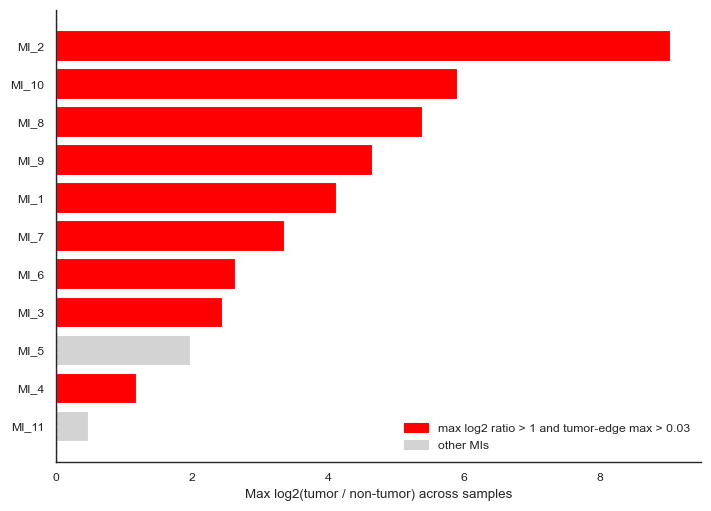

One-sided Wilcoxon signed-rank p-values (H1: median > 0):


MI_2     0.003906
MI_10    0.679688
MI_8     0.273438
MI_9     0.230469
MI_1     0.371094
MI_7     0.472656
MI_6     0.875000
MI_3     0.007812
MI_5     0.988281
MI_4     0.996094
MI_11    0.988281
dtype: float64

In [51]:
# Nature-style plotting settings
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})
sns.set_theme(style="white", context="paper")

# For each MI, use the maximum log2(tumor / non-tumor) value across samples
max_s = df.max(axis=0)

plot_df = max_s.reset_index()
plot_df.columns = ["MI", "max_value"]
plot_df["MI"] = plot_df["MI"].astype(str)

# Order MIs by descending maximum effect size
plot_df = plot_df.sort_values("max_value", ascending=False).reset_index(drop=True)
mi_order = plot_df["MI"].tolist()
df = df.loc[:, mi_order]

print("MI plotting order:")
print(mi_order)

mi_large_set = set([str(x) for x in MI_mean_pd_tumor_sample_colmax_large])

# Optional one-sided Wilcoxon signed-rank test: H1 median > 0
pvals = {}
for mi in mi_order:
    x = df[mi].astype(float).dropna().values

    if x.size == 0 or np.allclose(x, 0):
        pvals[mi] = 1.0
        continue

    try:
        _, p = wilcoxon(
            x,
            zero_method="wilcox",
            alternative="greater",
            mode="auto"
        )
        pvals[mi] = float(p)
    except ValueError:
        pvals[mi] = 1.0

pval_s = pd.Series(pvals)

# Highlight MIs that satisfy both:
# 1) max log2(tumor / non-tumor) > 1
# 2) tumor-edge sample-level max > tumor_MI_threshold
colors = [
    "red" if (row.max_value > 1 and row.MI in mi_large_set) else "lightgrey"
    for _, row in plot_df.iterrows()
]

plt.close("all")
fig, ax = plt.subplots(figsize=(7.2, 5.2))

ax.barh(plot_df["MI"], plot_df["max_value"], color=colors)
ax.invert_yaxis()
ax.axvline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Max log2(tumor / non-tumor) across samples")
ax.set_ylabel("")

red_patch = mpatches.Patch(
    color="red",
    label="max log2 ratio > 1 and tumor-edge max > " + str(tumor_MI_threshold)
)
grey_patch = mpatches.Patch(
    color="lightgrey",
    label="other MIs"
)
ax.legend(handles=[red_patch, grey_patch], frameon=False, loc="lower right")

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(
    str(run_dirs["run_dir"]) + "/MI_tumor_vs_nontumor_max_barplot.pdf",
    bbox_inches="tight"
)
plt.show()
plt.close()

print("One-sided Wilcoxon signed-rank p-values (H1: median > 0):")
display(pval_s.loc[mi_order])

release_memory(
    "df",
    "max_s",
    "plot_df",
    "mi_large_set",
    "pvals",
    "colors",
    "red_patch",
    "grey_patch",
    "fig",
    "ax",
    namespace=globals(),
    run_gc=True,
    clear_cuda=False,
    close_figures=True
)


## Show the mean MI activity for both tumor and non-tumor edges across samples

In [52]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches


# ============================================================
# Step 1. Get the number of cells in each slice
# ============================================================
# This assumes that processed.adata_list is aligned with the slice-level MI summary table.
numcell_list = [processed.adata_list[i].n_obs for i in range(len(processed.adata_list))]
print("Number of cells in each slice:")
print(numcell_list)


# ============================================================
# Step 2. Aggregate slice-level MI summaries to the sample level
# ============================================================
def aggregate_slice_mi_to_sample(mi_slice_df, numcell_list):
    """
    Aggregate slice-level MI summaries into sample-level summaries
    using cell-count-weighted averaging.

    Parameters
    ----------
    mi_slice_df : pd.DataFrame
        Slice-level MI summary table.
        Rows are slices and columns are MI features.
    numcell_list : list
        Number of cells in each slice, aligned with mi_slice_df rows.

    Returns
    -------
    pd.DataFrame
        Sample-level MI summary table.
    """
    slice_names = mi_slice_df.index.tolist()
    sample_names = [slice_name.split("_")[0] for slice_name in slice_names]
    unique_samples = np.unique(sample_names)

    mi_sample_df = pd.DataFrame(
        0.0,
        index=unique_samples,
        columns=mi_slice_df.columns
    )

    for sample_name_cur in unique_samples:
        slice_index_cur = [
            i for i in range(len(slice_names))
            if sample_names[i] == sample_name_cur
        ]
        numcell_slice_cur = [numcell_list[i] for i in slice_index_cur]

        weighted_mean = (
            np.sum(
                mi_slice_df.iloc[slice_index_cur, :].values *
                np.array(numcell_slice_cur)[:, np.newaxis],
                axis=0
            ) / (np.sum(numcell_slice_cur) + 1e-10)
        )

        mi_sample_df.loc[sample_name_cur, :] = weighted_mean

    return mi_sample_df


MI_mean_pd_tumor_sample = aggregate_slice_mi_to_sample(
    mi_slice_df=MI_mean_pd_tumor,
    numcell_list=numcell_list
)

MI_mean_pd_nontumor_sample = aggregate_slice_mi_to_sample(
    mi_slice_df=MI_mean_pd_nontumor,
    numcell_list=numcell_list
)

print("Tumor sample-level MI summary:")
display(MI_mean_pd_tumor_sample)

print("Non-tumor sample-level MI summary:")
display(MI_mean_pd_nontumor_sample)

Number of cells in each slice:
[47423, 40606, 30419, 43955, 30654, 39448, 31743, 36315, 33601, 31646, 34220, 29570, 42502, 31827, 37125, 31251, 42542, 30661, 32772, 31793, 45114, 34468, 29900, 40323, 36382, 42478, 42149, 34114, 39088, 34727, 42303, 43100, 53402, 37891, 39533, 48455, 38181, 51702, 34055, 44984, 32707, 26452, 30618, 22650, 32338, 31258, 37249, 26129, 34335, 30584, 27141, 29229, 30638, 32035, 22971, 30944, 28066, 25484, 30725, 33286, 16426, 17808, 17123, 23018, 22078, 14093, 19209, 15831, 14921, 20797, 17968, 18409, 18063, 15117, 13131, 20459, 17589, 18388, 15419, 17648, 26004, 26105, 33605, 24401, 25997, 29903, 26640, 16215, 14519, 25583, 28133, 11460, 23816, 29996, 13915, 32988, 27301, 10963, 25742, 12457, 13304, 14902, 9338, 5672, 7790, 11520, 12561, 9948, 13152, 11907, 9439, 10911, 13418, 8140, 10366, 9088, 14062, 7816, 10695, 7910, 36375, 46850, 29488, 30078, 42150, 36009, 36606, 32353, 37440, 32466, 27906, 37368, 36654, 35115, 40710, 39363, 35884, 29686, 42957, 3276

,MI_1,MI_2,MI_3,MI_4,MI_5,MI_6,MI_7,MI_8,MI_9,MI_10,MI_11
HumanBreastCancerPatient1,0.061603,0.095945,0.139711,0.028544,0.004951,0.045955,0.082131,0.119881,0.056447,0.119300,0.020876
HumanColonCancerPatient2,0.006487,0.354920,0.034353,0.001963,0.002330,0.000400,0.000268,0.007624,0.004919,0.000302,0.012774
HumanLiverCancerPatient2,0.007931,0.205422,0.041411,0.250239,0.001359,0.014632,0.000230,0.000967,0.000187,0.012550,0.002282
HumanLungCancerPatient1,0.002056,0.209952,0.020636,0.000817,0.000655,0.000277,0.000258,0.011197,0.008638,0.000149,0.007368
HumanMelanomaCancerPatient1,0.002762,0.299163,0.020374,0.001055,0.001070,0.000219,0.000085,0.000949,0.000383,0.000182,0.014682
HumanOvarianCancerPatient2Slice3,0.007003,0.225112,0.042958,0.002334,0.003425,0.000670,0.000823,0.023814,0.050316,0.000250,0.029860
HumanProstateCancerPatient1,0.003711,0.199425,0.018524,0.002723,0.000582,0.000130,0.000043,0.003874,0.000694,0.000193,0.023345
HumanUterineCancerPatient1,0.004446,0.294719,0.033389,0.001394,0.002912,0.000155,0.000200,0.012282,0.007279,0.000237,0.023535


Non-tumor sample-level MI summary:


,MI_1,MI_2,MI_3,MI_4,MI_5,MI_6,MI_7,MI_8,MI_9,MI_10,MI_11
HumanBreastCancerPatient1,0.003555,0.000581,0.025658,0.087962,0.016166,0.013254,0.007996,0.002871,0.002254,0.002003,0.015042
HumanColonCancerPatient2,0.002700,0.000675,0.016582,0.075458,0.011524,0.001553,0.000286,0.002319,0.001615,0.000538,0.031858
HumanLiverCancerPatient2,0.002974,0.001114,0.017503,0.110715,0.008172,0.002345,0.000198,0.001349,0.000615,0.001557,0.006732
HumanLungCancerPatient1,0.002101,0.000469,0.009185,0.005330,0.003917,0.001174,0.000234,0.002242,0.001213,0.000197,0.007080
HumanMelanomaCancerPatient1,0.003395,0.000646,0.014494,0.014112,0.005337,0.001205,0.000156,0.004770,0.001685,0.000264,0.041901
HumanOvarianCancerPatient2Slice3,0.007438,0.000928,0.026249,0.193635,0.000872,0.002382,0.000353,0.026700,0.014346,0.000497,0.120854
HumanProstateCancerPatient1,0.004416,0.000650,0.011351,0.007020,0.000830,0.000257,0.000115,0.006496,0.001834,0.000230,0.039482
HumanUterineCancerPatient1,0.005044,0.001974,0.033565,0.037744,0.033026,0.000707,0.000432,0.006074,0.004639,0.000838,0.113558


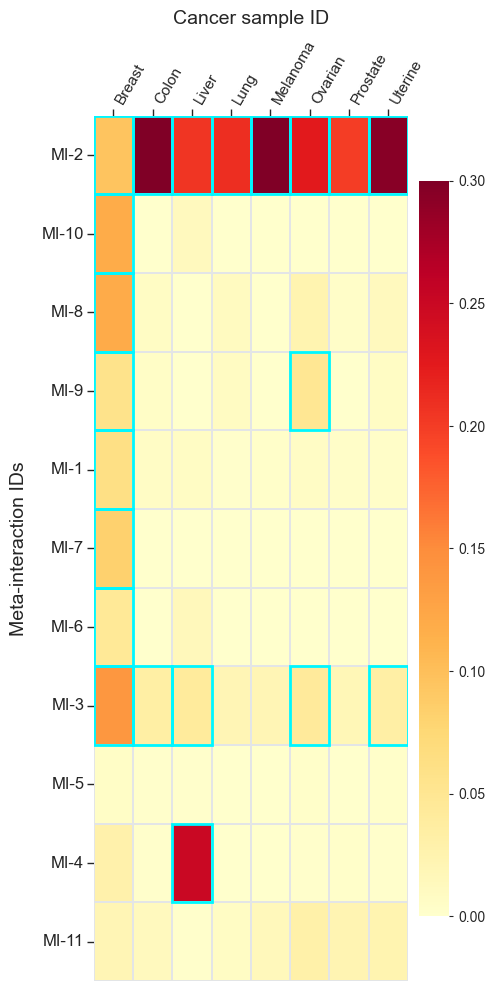

In [53]:
# ============================================================
# Step 3. Define a reusable heatmap plotting function
# ============================================================
def format_sample_labels(sample_ids):
    """
    Simplify sample labels for plotting.
    """
    sample_ids_new = []
    for sample_id in sample_ids:
        sample_id_new = str(sample_id)

        if "Patient" in sample_id_new:
            sample_id_new = sample_id_new.split("Patient")[0].rstrip("_- ")

        sample_id_new = sample_id_new.replace("Human", "").replace("Cancer", "").strip()
        sample_ids_new.append(sample_id_new)

    return sample_ids_new


def plot_mi_sample_heatmap(
    mi_sample_df,
    mi_order,
    xlabel,
    out_prefix,
    file_savepath_main,
    vmax=0.5,
    highlight_threshold=0.2,
    cmap="inferno"
):
    """
    Plot a sample-level MI heatmap and highlight cells above a threshold.
    """
    mi_sample_df_use = mi_sample_df.copy()

    # Keep only MI columns that appear in the requested order
    mi_order_use = [mi for mi in mi_order if mi in mi_sample_df_use.columns]
    mi_sample_df_use = mi_sample_df_use.loc[:, mi_order_use]

    # Save the reordered matrix
    mi_sample_df_use.to_csv(
        file_savepath_main + "/" + f"{out_prefix}_matrix.csv",
        index=True
    )

    # Prepare plotting labels
    ytick_labels = [
        str(mi).replace("MI_", "MI-")
        for mi in mi_sample_df_use.T.index
    ]
    xtick_labels = format_sample_labels(mi_sample_df_use.T.columns)

    data_plot = mi_sample_df_use.T  # rows = MI, columns = samples

    fig, ax = plt.subplots(figsize=(5, 10))

    hm = sns.heatmap(
        data_plot,
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        ax=ax,
        linewidths=0.30,
        linecolor="#E3E5E6",
        cbar=True,
        rasterized=True,
        cbar_kws=dict(shrink=0.85, aspect=25, pad=0.03)
    )

    # Highlight cells with values above the threshold
    arr = np.asarray(data_plot.values, dtype=float)
    n_rows, n_cols = arr.shape

    for i in range(n_rows):
        for j in range(n_cols):
            if np.isfinite(arr[i, j]) and (arr[i, j] > highlight_threshold):
                rect = patches.Rectangle(
                    (j, i), 1, 1,
                    fill=False,
                    edgecolor="#00F7FF",
                    linewidth=2.0
                )
                ax.add_patch(rect)

    # Apply axis labels and tick labels
    ax.set_yticklabels(ytick_labels, fontsize=12, rotation=0)
    ax.set_xticklabels(xtick_labels, fontsize=11, rotation=60, ha="left")

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False, pad=2)
    ax.tick_params(axis="y", left=True, right=False, pad=2)

    ax.set_xlabel(xlabel, fontsize=14, labelpad=10)
    ax.set_ylabel("Meta-interaction IDs", fontsize=14, labelpad=10)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10, width=0.8, length=3)

    fig.tight_layout()

    fig.savefig(
        file_savepath_main + "/" + f"{out_prefix}.pdf",
        format="pdf",
        bbox_inches="tight",
        transparent=True
    )
    fig.savefig(
        file_savepath_main + "/" + f"{out_prefix}.png",
        format="png",
        bbox_inches="tight",
        dpi=300,
        transparent=True
    )

    plt.show()
    plt.close(fig)

    # Release local plotting objects before the next heatmap call.
    del arr, data_plot, hm, fig, ax, mi_sample_df_use, ytick_labels, xtick_labels, mi_order_use
    gc.collect()


# ============================================================
# Step 4. Set plotting style
# ============================================================
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})
sns.set_theme(style="white", context="paper")

# from matplotlib.colors import LinearSegmentedColormap
# cmap = LinearSegmentedColormap.from_list(
#     "custom_coolwarm_graycenter",
#     ["#4575b4", "#f0f0f0", "#d73027"],
#     N=256
# )
import matplotlib.pyplot as plt

cmap = plt.get_cmap("YlOrRd")

# ============================================================
# Step 5. Plot tumor sample-level MI heatmap
# ============================================================
plot_mi_sample_heatmap(
    mi_sample_df=MI_mean_pd_tumor_sample,
    mi_order=mi_order,
    xlabel="Cancer sample ID",
    out_prefix="MI_heatmap_tumor_sampleagg",
    file_savepath_main=str(run_dirs['run_dir']),
    vmax=0.3,
    # vmax=0.2,
    highlight_threshold=tumor_MI_threshold,
    # highlight_threshold=0.03,
    cmap=cmap
)

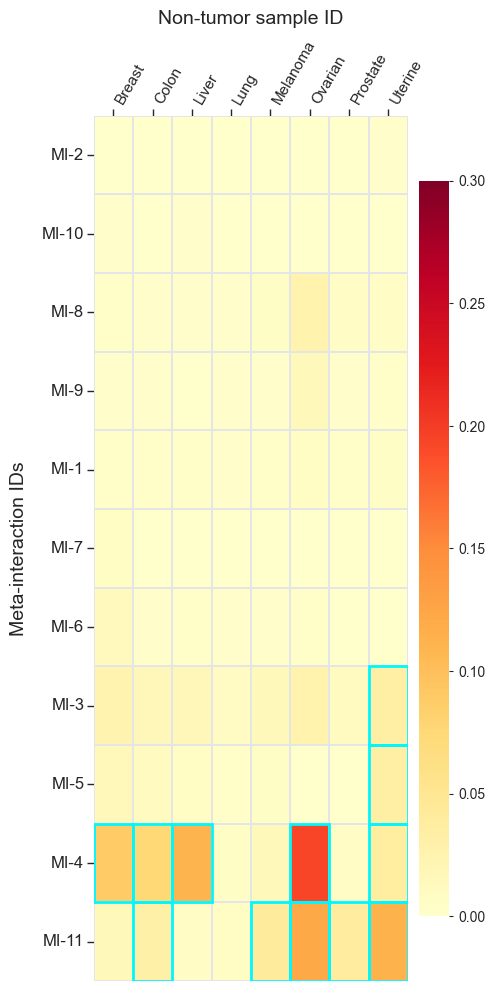

In [54]:
# ============================================================
# Step 6. Plot non-tumor sample-level MI heatmap
# ============================================================
plot_mi_sample_heatmap(
    mi_sample_df=MI_mean_pd_nontumor_sample,
    mi_order=mi_order,
    xlabel="Non-tumor sample ID",
    out_prefix="MI_heatmap_nontumor_sampleagg",
    file_savepath_main=str(run_dirs['run_dir']),
    vmax=0.3,
    highlight_threshold=tumor_MI_threshold,
    cmap=cmap
)

## Re-show the LR pathway enrichment results

In [55]:
mi_order

['MI_2',
 'MI_10',
 'MI_8',
 'MI_9',
 'MI_1',
 'MI_7',
 'MI_6',
 'MI_3',
 'MI_5',
 'MI_4',
 'MI_11']

In [56]:
##Load LR_loading_pathway
# LR_loading_pathway.to_csv(os.path.join(file_savepath_main, "LR_loading_pathway.csv"))
LR_loading_pathway = pd.read_csv(run_dirs['run_dir'] / "LR_loading_pathway.csv",index_col=0)
MI_orderbyage = mi_order
##Change the "MI_" to "MI-" in the index of LR_loading_pathway
MI_orderbyage = [x.replace("MI_", "MI-") for x in MI_orderbyage]
LR_loading_pathway = LR_loading_pathway.loc[MI_orderbyage, :]
LR_loading_pathway = LR_loading_pathway.iloc[:,
                     np.argsort(np.array(np.max(LR_loading_pathway, axis=0)))[::-1]
                     ]
# Refined pathway ordering
argmax_1 = np.argmax(np.array(LR_loading_pathway), axis=0)
max_1 = np.max(np.array(LR_loading_pathway), axis=0)
order_index_LRpathway = []
for argmax_1_cur in np.sort(np.unique(argmax_1)):
    index_cur = np.where(argmax_1 == argmax_1_cur)[0]
    index_cur = index_cur[np.argsort(max_1[index_cur])[::-1]]
    index_cur = index_cur.tolist()
    order_index_LRpathway.extend(index_cur)

LR_loading_pathway = LR_loading_pathway.iloc[:, order_index_LRpathway]


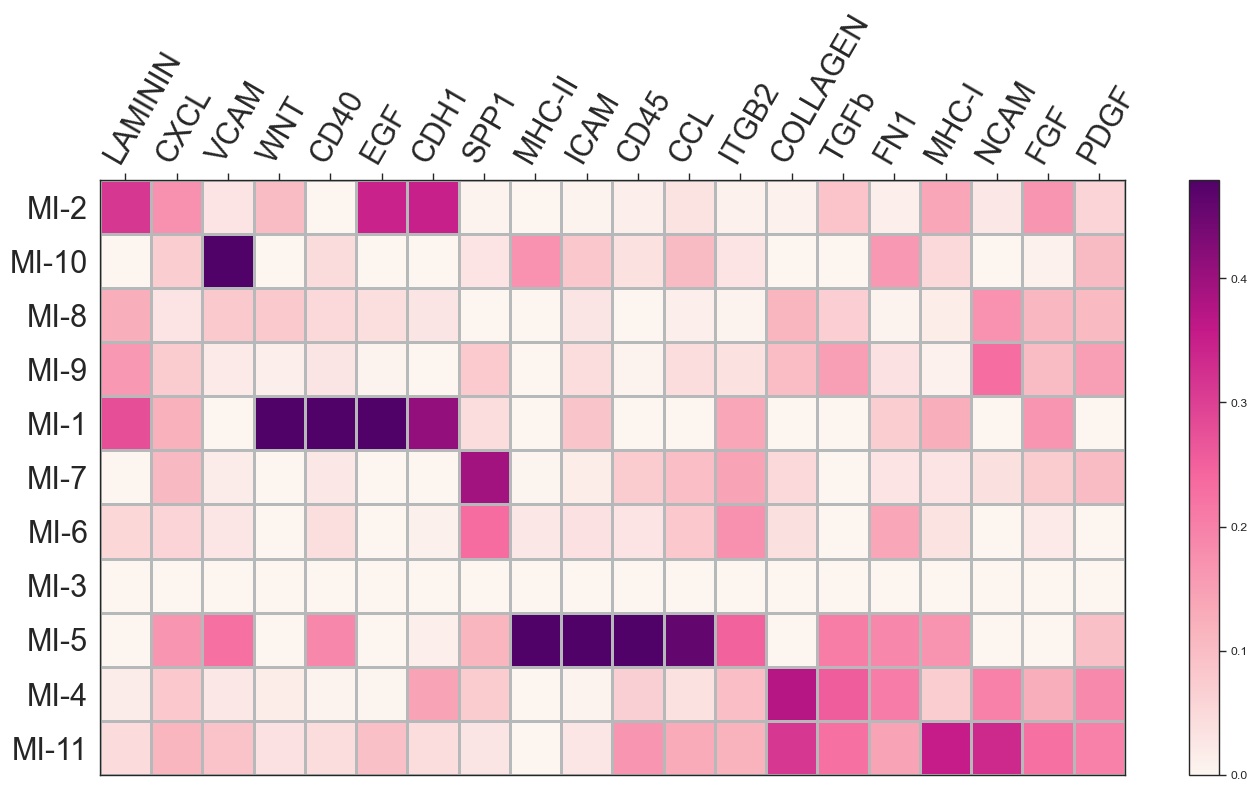

In [57]:
# Visualization
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import os
plt.close()
fig, ax = plt.subplots(figsize=(14, 8))
# cmap = LinearSegmentedColormap.from_list(
#     "white_red", ["white", "#FFDFEF", "#EABDE6", "#D69ADE", "#AA60C8"], N=256
# )
cmap = LinearSegmentedColormap.from_list(
    "white_red", ["#FCF5F0", "#F9B2BC", "#F6689F", "#C31988", "#510269"], N=256
)

data = LR_loading_pathway.values
vmin = data.min()
# vmax = min(0.4, np.max(data) * 0.7)
vmax = np.max(data) * 0.6
norm = TwoSlopeNorm(vmin=vmin, vcenter=(vmin + vmax) / 2, vmax=vmax)

mesh = ax.pcolormesh(
    np.arange(data.shape[1] + 1),
    np.arange(data.shape[0] + 1),
    data,
    cmap=cmap,
    norm=norm,
    edgecolors="#B6B9BA",
    linewidth=1.0
)

ax.set_xticks(np.arange(data.shape[1]) + 0.5)
# ax.set_xticklabels(LR_loading_pathway.columns, rotation=60, fontsize=22)
ax.set_xticklabels(
    LR_loading_pathway.columns,
    rotation=60,
    fontsize=22,
    ha="left",
    rotation_mode="anchor"
)
ax.set_yticks(np.arange(data.shape[0]) + 0.5)
ax.set_yticklabels(LR_loading_pathway.index, fontsize=22)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.invert_yaxis()

plt.colorbar(mesh, ax=ax)
plt.tight_layout()

save_png = os.path.join(run_dirs['run_dir'], "LR_loading_pathway.png")
plt.savefig(save_png, format="png", bbox_inches="tight", dpi=300)

save_pdf = os.path.join(run_dirs['run_dir'], "LR_loading_pathway.pdf")
plt.savefig(save_pdf, format="pdf", bbox_inches="tight", dpi=300)

plt.show()
plt.close()


release_memory(
    "data",
    "vmin",
    "vmax",
    "norm",
    "mesh",
    "fig",
    "ax",
    namespace=globals(),
    run_gc=True,
    clear_cuda=False,
    close_figures=True
)


In [28]:
# Release large intermediate objects before the in-situ plotting section.
# Keep `processed`, `run_dirs`, and `mi_order` because they are still needed.
release_memory(
    "Factor_envir_use",
    "batch_cell",
    "MI_mean_pd_tumor",
    "MI_mean_pd_nontumor",
    "MI_mean_pd_tumor_vs_nontumor",
    "MI_mean_pd_tumor_vs_nontumor_log2",
    "MI_mean_pd_tumor_sample",
    "MI_mean_pd_nontumor_sample",
    "MI_mean_pd_tumor_sample_colmax",
    "MI_mean_pd_tumor_sample_colmax_large",
    "pval_s",
    "LR_loading_pathway",
    namespace=globals(),
    run_gc=True,
    clear_cuda=True,
    close_figures=True
)


## in-situ plot of meta-interaction dimension

In [ ]:
##Show the in-situ meta-interaction plot
save_path_insituMI = str(run_dirs['run_dir']) + "/In_situ_meta_interaction/"
if not os.path.exists(save_path_insituMI):
    os.makedirs(save_path_insituMI)

In [ ]:
##MI of interest
MI_OI = "MI-2"

In [30]:
MI_index = int(MI_OI.replace("MI-", "")) - 1
##
gray_other_cells = True 
##
# vis_mode = 2
vis_mode = 1

In [31]:
# ============================================================
# In-situ plot of one meta-interaction dimension
# - Plot only one MI at a time
# - Read MI strengths from a memory-mapped .npy file
# - Release per-sample temporary objects immediately after saving
# - Use more conservative default DPI to reduce memory pressure
# - Print progress only every 10% of slices
# ============================================================

Sender_celltype_list_choose = [
    "Breast-cancercell",
    "Colon-cancercell",
    "Liver-cancercell",
    "Lung-cancercell",
    "Melanoma-cancercell",
    "Ovarian-cancercell",
    "Prostate-cancercell",
    "Uterine-cancercell",
]

Receiver_celltype_list_choose = [
    "Endothelial",
    "Fibroblast",
]

import gc
import os
import math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import FancyArrowPatch

batch_cell_unique = np.asarray(pd.read_pickle(run_dirs["run_dir"] / "batch_cell_unique.pkl"))
factor_envir_path = run_dirs["run_dir"] / "Factor_envir_use.npy"
Factor_envir_use_mmap = np.load(factor_envir_path, mmap_mode="r")

# Pre-compute edge offsets so each sample can read only its own MI slice.
edge_counts = np.asarray(
    [processed.spidernet_data[i]["edge_index"].shape[0] for i in range(len(processed.spidernet_data))],
    dtype=np.int64
)
edge_offsets = np.concatenate(([0], np.cumsum(edge_counts)))

edge_sample_random_state = 2026

if vis_mode == 1:
    base_size = 18
    ratio_size = 1
    arrow_lw_base = 1.2
    arrow_ms = 10
    figure_size = (24, 20)
    dpi_png = 250
    dpi_pdf = 300
elif vis_mode == 2:
    base_size = 10
    ratio_size = 1
    arrow_lw_base = 0.8
    arrow_ms = 8
    figure_size = (24, 20)
    dpi_png = 300
    dpi_pdf = 300
else:
    base_size = 14
    ratio_size = 1
    arrow_lw_base = 1.0
    arrow_ms = 9
    figure_size = (24, 20)
    dpi_png = 250
    dpi_pdf = 300

dot_base = base_size * (2.0 / 3.0)
arrow_ms_eff = arrow_ms * 0.5

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})

cell_types = [
    "B cell", "Breast-cancercell", "CD4_T", "CD8_T/NK", "Colon-cancercell", "DC",
    "Endothelial", "Epithelial", "Fibroblast", "Liver-cancercell", "Lung-cancercell",
    "Macrophage", "Mast cell", "Melanoma-cancercell", "Ovarian-cancercell",
    "Prostate-cancercell", "Treg", "Uterine-cancercell", "low_exp",
]
color_set = [
    "#8894F1", "#7F3480", "#FF259E", "#FF52DB", "#F7B2EF", "#2C5E1A",
    "#029991", "#E384FF", "#944E13", "#FF8B6C", "#B37166", "#74650F",
    "#7228B8", "#009D4E", "#DD0303", "#028DCE", "#DE0878", "#FAB12F", "#BBC58F",
]
celltype_to_color = dict(zip(cell_types, color_set))
default_gray = "#BFBFBF"
cmap_edge = LinearSegmentedColormap.from_list("white_to_red", ["white", "red"], N=256)

os.makedirs(save_path_insituMI, exist_ok=True)

# Print progress only at 10%, 20%, ..., 100%
n_samples_total = len(batch_cell_unique)
progress_points = sorted(set([
    max(1, math.ceil(n_samples_total * frac / 10))
    for frac in range(1, 11)
]))

for sample_index_cur, sample_cur in enumerate(batch_cell_unique):
    sample_num = sample_index_cur + 1
    should_report = sample_num in progress_points

    try:
        adata_cursample = processed.adata_list[sample_index_cur]
        data_pyg_cursample = processed.spidernet_data[sample_index_cur]

        spatial_xy = np.asarray(adata_cursample.obsm["spatial"], dtype=np.float32)
        edge_index = data_pyg_cursample["edge_index"].cpu().numpy().astype(np.int32, copy=False)

        if edge_index.ndim != 2 or edge_index.shape[1] != 2:
            raise ValueError(f"edge_index expected shape (E, 2), got {edge_index.shape}")

        start_idx = edge_offsets[sample_index_cur]
        end_idx = edge_offsets[sample_index_cur + 1]
        factor_edge = np.asarray(Factor_envir_use_mmap[start_idx:end_idx, MI_index], dtype=np.float32)

        if factor_edge.shape[0] != edge_index.shape[0]:
            raise ValueError(
                f"Mismatch between edge count and MI edge weights for sample {sample_cur}: "
                f"{edge_index.shape[0]} edges versus {factor_edge.shape[0]} MI values."
            )

        cellclass = np.asarray(data_pyg_cursample["cell_class"]).astype(str)

        src = edge_index[:, 0]
        dst = edge_index[:, 1]
        sender_ct = cellclass[src]
        receiver_ct = cellclass[dst]

        factor_thr = 0.3
        mask_sr = np.isin(sender_ct, Sender_celltype_list_choose) & np.isin(receiver_ct, Receiver_celltype_list_choose)
        mask_thr = factor_edge > factor_thr
        passed_edge_idx = np.flatnonzero(mask_sr & mask_thr)

        n_pass = passed_edge_idx.size
        if n_pass > 2000:
            rng = np.random.default_rng(edge_sample_random_state + sample_index_cur)
            passed_edge_idx = np.sort(rng.choice(passed_edge_idx, size=2000, replace=False))

        if should_report:
            progress_pct = int(round(sample_num / n_samples_total * 100))
            print(f"Progress: {progress_pct}% ({sample_num}/{n_samples_total})")
            # print(f"  passed edges before sampling: {n_pass}")
            # print(f"  edges drawn (after sampling): {passed_edge_idx.size}")

        if passed_edge_idx.size > 0:
            passed_vals = factor_edge[passed_edge_idx]
            if passed_vals.size >= 20:
                vmin = float(np.percentile(passed_vals, 5))
                vmax = float(np.percentile(passed_vals, 95))
            else:
                vmin = float(np.min(passed_vals))
                vmax = float(np.max(passed_vals))
        else:
            passed_vals = factor_edge
            if passed_vals.size == 0:
                vmin, vmax = 0.0, 1.0
            else:
                vmin = float(np.min(passed_vals))
                vmax = float(np.max(passed_vals))

        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-8

        norm_edge = Normalize(vmin=vmin, vmax=vmax, clip=True)

        plt.close("all")
        fig, ax = plt.subplots(figsize=figure_size, facecolor="white")
        ax.set_facecolor("white")

        node_in_edge_mask = np.zeros(len(cellclass), dtype=bool)
        if passed_edge_idx.size > 0:
            involved_nodes = np.unique(np.concatenate([src[passed_edge_idx], dst[passed_edge_idx]]))
            node_in_edge_mask[involved_nodes] = True
        else:
            involved_nodes = np.array([], dtype=np.int32)

        sizes = np.full(len(cellclass), dot_base, dtype=np.float32)
        sizes[node_in_edge_mask] = dot_base * ratio_size

        non_involved_mask = ~node_in_edge_mask
        if np.any(non_involved_mask):
            ax.scatter(
                spatial_xy[non_involved_mask, 0],
                spatial_xy[non_involved_mask, 1],
                c=default_gray,
                s=sizes[non_involved_mask],
                zorder=2,
                rasterized=True,
                alpha=1.0,
                edgecolors="none",
                linewidths=0,
            )

        for ct in cell_types:
            mask_ct = node_in_edge_mask & (cellclass == ct)
            if not np.any(mask_ct):
                continue
            ax.scatter(
                spatial_xy[mask_ct, 0],
                spatial_xy[mask_ct, 1],
                c=celltype_to_color.get(ct, default_gray),
                s=sizes[mask_ct],
                zorder=3,
                rasterized=True,
                alpha=1.0,
                edgecolors="none",
                linewidths=0,
            )

        arrowstyle = "-|>"
        edge_zorder = 10

        for ei in passed_edge_idx:
            s = int(src[ei])
            t = int(dst[ei])

            x0, y0 = spatial_xy[s, 0], spatial_xy[s, 1]
            x1, y1 = spatial_xy[t, 0], spatial_xy[t, 1]

            w01 = float(norm_edge(float(factor_edge[ei])))
            edge_color = cmap_edge(w01)

            arr = FancyArrowPatch(
                (x0, y0),
                (x1, y1),
                arrowstyle=arrowstyle,
                mutation_scale=arrow_ms_eff,
                linewidth=arrow_lw_base * 0.8,
                color=edge_color,
                alpha=0.35 + 0.55 * w01,
                shrinkA=0,
                shrinkB=0,
                capstyle="round",
                joinstyle="round",
                zorder=edge_zorder,
            )
            ax.add_patch(arr)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        out_png = os.path.join(
            save_path_insituMI,
            f"Insitu_sample{sample_cur}_MI{MI_index + 1}_celltype_Mode{vis_mode}.png"
        )
        out_pdf = os.path.join(
            save_path_insituMI,
            f"Insitu_sample{sample_cur}_MI{MI_index + 1}_celltype_Mode{vis_mode}.pdf"
        )

        fig.savefig(out_png, dpi=dpi_png, bbox_inches="tight", facecolor="white")
        fig.savefig(out_pdf, dpi=dpi_pdf, bbox_inches="tight", facecolor="white")

    finally:
        plt.close("all")
        for _name in [
            "adata_cursample",
            "data_pyg_cursample",
            "spatial_xy",
            "edge_index",
            "factor_edge",
            "cellclass",
            "src",
            "dst",
            "sender_ct",
            "receiver_ct",
            "mask_sr",
            "mask_thr",
            "passed_edge_idx",
            "passed_vals",
            "norm_edge",
            "node_in_edge_mask",
            "involved_nodes",
            "sizes",
            "non_involved_mask",
            "fig",
            "ax",
            "arr",
        ]:
            if _name in globals():
                del globals()[_name]

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

release_memory(
    "Factor_envir_use_mmap",
    "edge_counts",
    "edge_offsets",
    "batch_cell_unique",
    namespace=globals(),
    run_gc=True,
    clear_cuda=True,
    close_figures=True
)

Progress: 10% (16/160)
Progress: 20% (32/160)
Progress: 30% (48/160)
Progress: 40% (64/160)
Progress: 50% (80/160)
Progress: 60% (96/160)
Progress: 70% (112/160)
Progress: 80% (128/160)
Progress: 90% (144/160)
Progress: 100% (160/160)


## Output the result for circle plot of specific MI dimension

In [32]:
##Load the adata_all
adata_all = sc.read_h5ad(run_dirs['run_dir'] / "adata_all.h5ad")
celltype_all = np.unique(adata_all.obs['celltype_final'].values)
cellclass_unique = np.unique(celltype_all)
target_cellclass_pair_df_all = pd.DataFrame({"Sender": np.repeat(cellclass_unique.tolist(), len(cellclass_unique)).tolist(),
                                         "Receiver": np.tile(cellclass_unique.tolist(), len(cellclass_unique)).tolist()})
# target_cellclass_pair_df_all = target_cellclass_pair_df_all[target_cellclass_pair_df_all['Sender'] != target_cellclass_pair_df_all['Receiver']]
# print(target_cellclass_pair_df_all)
# print(cellclass_unique)

sender_cellclass = []
receiver_cellclass = []
for batch_index in range(len(processed.spidernet_data)):
    edge_index_cur = processed.spidernet_data[batch_index]['edge_index'].to("cpu").numpy()
    cellclass_cursample = np.array(processed.adata_list[batch_index].obs['celltype_final'])
    sender_cellclass_cur = cellclass_cursample[edge_index_cur[:,0]]
    receiver_cellclass_cur = cellclass_cursample[edge_index_cur[:,1]]
    sender_cellclass.extend(sender_cellclass_cur.tolist())
    receiver_cellclass.extend(receiver_cellclass_cur.tolist())
sender_cellclass = np.array(sender_cellclass)
receiver_cellclass = np.array(receiver_cellclass)
# print(sender_cellclass.shape)
# print(receiver_cellclass.shape)
del adata_all, celltype_all, cellclass_unique

MemoryError: Unable to allocate 682. MiB for an array with shape (19, 4707751) and data type float64

In [33]:
import gc
import numpy as np
import pandas as pd
from scipy import sparse

# --------------------------------------------------
# Fast mean aggregation by (sender, receiver) pair
# using only a random 20% subset of edges
# --------------------------------------------------

sample_ratio = 0.20
random_seed = 2026

# --------------------------------------------------
# Step 1. Read MI matrix with memory mapping
# --------------------------------------------------
factor_path = run_dirs["run_dir"] / "Factor_envir_use.npy"
Factor_envir_use_mmap = np.load(factor_path, mmap_mode="r")
E, M = Factor_envir_use_mmap.shape

# --------------------------------------------------
# Step 2. Randomly sample 20% of edges
# --------------------------------------------------
n_sample = max(1, int(E * sample_ratio))
rng = np.random.default_rng(random_seed)
edge_idx_sample = np.sort(rng.choice(E, size=n_sample, replace=False))

print(f"Original number of edges: {E}")
print(f"Sampled number of edges: {n_sample}")

# Read only the sampled rows into memory
Factor_envir_use = np.asarray(Factor_envir_use_mmap[edge_idx_sample, :], dtype=np.float32)

# sender_cellclass and receiver_cellclass should already exist in memory
sender_arr = np.asarray(sender_cellclass, dtype=object)[edge_idx_sample]
receiver_arr = np.asarray(receiver_cellclass, dtype=object)[edge_idx_sample]

# The full mmap object is no longer needed
del Factor_envir_use_mmap
gc.collect()

# --------------------------------------------------
# Step 3. Define the target sender-receiver pair order
# --------------------------------------------------
pair_list = (
    target_cellclass_pair_df_all["Sender"].astype(str).to_numpy()
    + "_to_"
    + target_cellclass_pair_df_all["Receiver"].astype(str).to_numpy()
)
P = len(pair_list)

# --------------------------------------------------
# Step 4. Build edge-level pair labels
# --------------------------------------------------
sender_str = sender_arr.astype(str)
receiver_str = receiver_arr.astype(str)
edge_pairs = np.char.add(np.char.add(sender_str, "_to_"), receiver_str)

# These object arrays are no longer needed
del sender_arr, receiver_arr, sender_str, receiver_str
gc.collect()

# --------------------------------------------------
# Step 5. Map sampled edges to target pair indices
# --------------------------------------------------
pair_index = pd.Index(pair_list)
codes = pair_index.get_indexer(edge_pairs).astype(np.int32)
mask = codes >= 0

# edge_pairs is no longer needed
del edge_pairs, pair_index
gc.collect()

codes_use = codes[mask]
Factor_use = Factor_envir_use[mask, :]

# These are no longer needed
del codes, mask, Factor_envir_use
gc.collect()

# --------------------------------------------------
# Step 6. Aggregate MI values by pair
# --------------------------------------------------
rows = np.arange(codes_use.size, dtype=np.int64)
cols = codes_use.astype(np.int64)
data = np.ones(codes_use.size, dtype=np.float32)

G = sparse.csr_matrix((data, (rows, cols)), shape=(codes_use.size, P))

# These temporary arrays are no longer needed
del rows, cols, data, codes_use
gc.collect()

sums = G.T.dot(Factor_use)                  # shape = (P, M)
counts = np.asarray(G.sum(axis=0)).ravel() # shape = (P,)

# G and Factor_use are no longer needed after aggregation
del G, Factor_use
gc.collect()

means = np.full_like(sums, np.nan, dtype=np.float32)
np.divide(sums, counts[:, None], out=means, where=(counts[:, None] > 0))

# sums and counts are no longer needed
del sums, counts
gc.collect()

# --------------------------------------------------
# Step 7. Build output matrix
# rows = MI, columns = sender-receiver pairs
# --------------------------------------------------
mean_MI_cellclasspair_all = pd.DataFrame(
    means.T,
    index=[f"MI-{i+1}" for i in range(M)],
    columns=pair_list
)

# means is no longer needed after the DataFrame is created
del means
gc.collect()

# --------------------------------------------------
# Step 8. Export MI-2 links
# --------------------------------------------------
df_plot_all = pd.DataFrame({
    "MI": np.repeat(mean_MI_cellclasspair_all.index, mean_MI_cellclasspair_all.shape[1]),
    "Pair": np.tile(mean_MI_cellclasspair_all.columns, mean_MI_cellclasspair_all.shape[0]),
    "Mean": mean_MI_cellclasspair_all.values.flatten()
})

df_MI2_all = df_plot_all[df_plot_all["MI"] == "MI-2"].copy()
df_MI2_all["Receiver"] = df_MI2_all["Pair"].str.split("_to_").str[1]
df_MI2_all["Sender"] = df_MI2_all["Pair"].str.split("_to_").str[0]

csv_path = str(run_dirs["run_dir"]) + "/MI2_all_links.csv"
df_MI2_all.to_csv(csv_path, index=False)

print(f"Saved: {csv_path}")

# Optional cleanup for large temporary tables
del df_plot_all
gc.collect()

Original number of edges: 23538755
Sampled number of edges: 4707751


NameError: name 'sender_cellclass' is not defined

## Optional GO enrichment analyses of the top regulators and targets

This section performs GO enrichment on the top regulators and target genes identified from the loading analysis. 

In [28]:
import gseapy as gp

In [29]:
MI_OI = "MI2"

In [30]:
## Identify candidate regulator and target genes for knockout
loading_receiver_use = np.load(run_dirs['run_dir'] / "loading_receiver_use.npy")
loading_sender_use = np.load(run_dirs['run_dir'] / "loading_sender_use.npy")
loading_receiver_use_df = pd.DataFrame(loading_receiver_use, index=["MI" + str(i+1) for i in range(loading_receiver_use.shape[0])],
                                        columns=processed.adata_list[0].var_names)
loading_sender_use_df = pd.DataFrame(loading_sender_use, index=["MI" + str(i+1) for i in range(loading_sender_use.shape[0])],
                                        columns=processed.adata_list[0].var_names)
loading_receiver_use_df_colsum = loading_receiver_use_df.abs().sum(axis=0)
loading_sender_use_df_colsum = loading_sender_use_df.abs().sum(axis=0)
loading_receiver_use_df_norm = loading_receiver_use_df.div(loading_receiver_use_df_colsum, axis=1)
loading_sender_use_df_norm = loading_sender_use_df.div(loading_sender_use_df_colsum, axis=1)


In [31]:
loading_receiver_use_df_norm_choose = loading_receiver_use_df_norm.loc[MI_OI]
loading_sender_use_df_norm_choose = loading_sender_use_df_norm.loc[MI_OI]
loading_receiver_use_df_norm_choose = loading_receiver_use_df_norm_choose.sort_values(ascending=False)
loading_sender_use_df_norm_choose = loading_sender_use_df_norm_choose.sort_values(ascending=False)

In [32]:
##Get the top regulators and targets based on the loading
top_targetgene_MIOI = loading_receiver_use_df_norm_choose.index[loading_receiver_use_df_norm_choose > 0.4].tolist()
print(top_targetgene_MIOI)
top_regulatorgene_MIOI = loading_sender_use_df_norm_choose.index[loading_sender_use_df_norm_choose > 0.4].tolist()
print(top_regulatorgene_MIOI)

['NOS2', 'CA9', 'MUC2', 'CDH1', 'IL17A', 'PGLYRP1', 'IL21', 'TNFSF9', 'NDUFA4L2', 'PKIB', 'MUC1', 'PLOD2', 'CCL7', 'CEACAM1', 'EGF', 'MMP1', 'BRCA1', 'AURKA', 'KIR3DL2', 'FOXM1', 'CHEK1', 'BIRC5', 'IL1B', 'CDCA7', 'CCNB1', 'MCM2', 'WNT3']
['MUC2', 'NOS2', 'CA9', 'FGFR3', 'CDH1', 'PPARGC1A', 'CCL28', 'CCR6', 'CEACAM1', 'LAMB3', 'AURKA', 'WNT3', 'LGR6', 'FOXM1', 'BIRC5', 'CCNB1', 'ERBB3', 'MKI67', 'PLK1', 'MCM2', 'IL1B', 'E2F1', 'TNFSF9', 'CHEK1', 'CEACAM8', 'MMP1', 'BRCA1', 'XCL1', 'MUC1', 'CCL1', 'TMEM59', 'LAMC2', 'MET', 'EGF', 'PKIB', 'IL22', 'SMARCA4', 'IL17A', 'SRPRB', 'MYBL2', 'CDCA7', 'NDUFA4L2', 'IL21', 'PGLYRP1', 'AURKB', 'IFNB1', 'KIR3DL2', 'FFAR2', 'DDIT3', 'CD1B', 'SOX2', 'TP63']


### Top regulators

In [33]:
go_res = gp.enrichr(
    gene_list=top_regulatorgene_MIOI,
    gene_sets=['GO_Biological_Process_2021'],
    organism="human",
    outdir="GO_MIOI_target",
    cutoff=0.05 
)

df_filter = go_res.results[
    (go_res.results['Adjusted P-value'] < 0.05)]

print(df_filter)

                       Gene_set  \
0    GO_Biological_Process_2021   
1    GO_Biological_Process_2021   
2    GO_Biological_Process_2021   
3    GO_Biological_Process_2021   
4    GO_Biological_Process_2021   
..                          ...   
213  GO_Biological_Process_2021   
214  GO_Biological_Process_2021   
215  GO_Biological_Process_2021   
216  GO_Biological_Process_2021   
217  GO_Biological_Process_2021   

                                                  Term  Overlap       P-value  \
0     cytokine-mediated signaling pathway (GO:0019221)   15/621  3.145402e-11   
1    cellular response to cytokine stimulus (GO:007...   12/482  2.882339e-09   
2    regulation of mitotic nuclear division (GO:000...     6/57  7.519578e-09   
3    positive regulation of transcription, DNA-temp...  16/1183  2.779321e-08   
4    positive regulation of nucleic acid-templated ...   11/511  6.374476e-08   
..                                                 ...      ...           ...   
213  positiv

In [34]:
df_filter["Term"].tolist()

['cytokine-mediated signaling pathway (GO:0019221)',
 'cellular response to cytokine stimulus (GO:0071345)',
 'regulation of mitotic nuclear division (GO:0007088)',
 'positive regulation of transcription, DNA-templated (GO:0045893)',
 'positive regulation of nucleic acid-templated transcription (GO:1903508)',
 'positive regulation of cytokine production (GO:0001819)',
 'positive regulation of histone acetylation (GO:0035066)',
 'positive regulation of transcription by RNA polymerase II (GO:0045944)',
 'regulation of cell cycle (GO:0051726)',
 'DNA damage response, signal transduction by p53 class mediator (GO:0030330)',
 'regulation of histone acetylation (GO:0035065)',
 'positive regulation of transferase activity (GO:0051347)',
 'positive regulation of cell population proliferation (GO:0008284)',
 'negative regulation of transcription, DNA-templated (GO:0045892)',
 'positive regulation of leukocyte mediated cytotoxicity (GO:0001912)',
 'positive regulation of cell cycle process (GO:0

In [35]:
GO_term_choose = [
    # [1] Inflammatory / cytokine output axis (Sender)
    "positive regulation of interleukin-6 production (GO:0032755)",
    "positive regulation of interleukin-8 production (GO:0032757)",
    "positive regulation of chemokine production (GO:0032722)",

    # [2] Growth signal / kinase activation axis (Sender)
    "regulation of ERBB signaling pathway (GO:1901184)",
    "positive regulation of protein kinase B signaling (GO:0051897)",
    "positive regulation of MAPK cascade (GO:0043410)",

    # # [3] VEGF-remodeling coupling
    # "positive regulation of vascular endothelial growth factor production (GO:0010575)",
]

df_filter = df_filter[df_filter['Term'].isin(GO_term_choose)]
print(df_filter)
df_filter.to_csv(str(run_dirs['run_dir']) + '/GO_enrichment_topregulator_MI2.csv')

                       Gene_set  \
20   GO_Biological_Process_2021   
66   GO_Biological_Process_2021   
95   GO_Biological_Process_2021   
96   GO_Biological_Process_2021   
97   GO_Biological_Process_2021   
104  GO_Biological_Process_2021   

                                                  Term Overlap   P-value  \
20   positive regulation of interleukin-8 productio...    4/61  0.000019   
66   positive regulation of chemokine production (G...    3/53  0.000354   
95    positive regulation of MAPK cascade (GO:0043410)   5/274  0.000715   
96   regulation of ERBB signaling pathway (GO:1901184)    2/16  0.000777   
97   positive regulation of protein kinase B signal...   4/161  0.000811   
104  positive regulation of interleukin-6 productio...    3/76  0.001019   

     Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
20           0.001045            0                     0   29.080409   
66           0.005884            0                     0   24.364898   
95   

### Top targets

In [36]:
go_res = gp.enrichr(
    gene_list=top_targetgene_MIOI,
    gene_sets=['GO_Biological_Process_2021'],
    organism="human",
    outdir="GO_MIOI_target", 
    cutoff=0.05
)

df_filter = go_res.results[
    (go_res.results['Adjusted P-value'] < 0.05)]

print(df_filter)

                       Gene_set  \
0    GO_Biological_Process_2021   
1    GO_Biological_Process_2021   
2    GO_Biological_Process_2021   
3    GO_Biological_Process_2021   
4    GO_Biological_Process_2021   
..                          ...   
252  GO_Biological_Process_2021   
253  GO_Biological_Process_2021   
254  GO_Biological_Process_2021   
255  GO_Biological_Process_2021   
256  GO_Biological_Process_2021   

                                                  Term Overlap       P-value  \
0     cytokine-mediated signaling pathway (GO:0019221)  10/621  4.058016e-09   
1    regulation of mitotic nuclear division (GO:000...    5/57  1.208936e-08   
2    cellular response to cytokine stimulus (GO:007...   8/482  1.593327e-07   
3    DNA damage response, signal transduction by p5...    4/74  2.840591e-06   
4    positive regulation of histone acetylation (GO...    3/23  3.816084e-06   
..                                                 ...     ...           ...   
252  positive regul

In [37]:
df_filter["Term"].tolist()

['cytokine-mediated signaling pathway (GO:0019221)',
 'regulation of mitotic nuclear division (GO:0007088)',
 'cellular response to cytokine stimulus (GO:0071345)',
 'DNA damage response, signal transduction by p53 class mediator (GO:0030330)',
 'positive regulation of histone acetylation (GO:0035066)',
 'positive regulation of nuclear division (GO:0051785)',
 'positive regulation of cell cycle process (GO:0090068)',
 'regulation of histone acetylation (GO:0035065)',
 'positive regulation of mitotic nuclear division (GO:0045840)',
 'response to indole-3-methanol (GO:0071680)',
 'cellular response to indole-3-methanol (GO:0071681)',
 'positive regulation of histone H4 acetylation (GO:0090240)',
 'regulation of cell cycle (GO:0051726)',
 'DNA damage response, signal transduction by p53 class mediator resulting in cell cycle arrest (GO:0006977)',
 'positive regulation of cytokine production (GO:0001819)',
 'DNA damage response, signal transduction by p53 class mediator resulting in transc

In [38]:
GO_term_choose = [
    # [1-1] Inflammatory / STAT response program (Receiver)
    "cellular response to cytokine stimulus (GO:0071345)",
    "regulation of receptor signaling pathway via STAT (GO:1904892)",

    # [1-2] Inflammation-driven remodeling program (Receiver)
    "extracellular matrix organization (GO:0030198)",
    
    # [2] Cell-cycle / proliferative execution program (Receiver)
    "DNA replication (GO:0006260)",
    "G2/M transition of mitotic cell cycle (GO:0000086)",
    
    # # [3] VEGF-remodeling coupling
    # "positive regulation of vascular endothelial growth factor receptor signaling pathway (GO:0030949)", 
]
df_filter = df_filter[df_filter['Term'].isin(GO_term_choose)]
print(df_filter)
df_filter.to_csv(str(run_dirs['run_dir']) + '/GO_enrichment_toptarget_MI2.csv')

                       Gene_set  \
2    GO_Biological_Process_2021   
35   GO_Biological_Process_2021   
46   GO_Biological_Process_2021   
122  GO_Biological_Process_2021   
247  GO_Biological_Process_2021   

                                                  Term Overlap       P-value  \
2    cellular response to cytokine stimulus (GO:007...   8/482  1.593327e-07   
35                        DNA replication (GO:0006260)   3/108  4.075493e-04   
46   G2/M transition of mitotic cell cycle (GO:0000...   3/130  7.002102e-04   
122     extracellular matrix organization (GO:0030198)   3/300  7.487352e-03   
247  regulation of receptor signaling pathway via S...    1/13  1.741359e-02   

     Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
2            0.000039            0                     0   17.320897   
35           0.008179            0                     0   23.652381   
46           0.010876            0                     0   19.533465   
122          0.04240

In [39]:
df_filter

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
2,GO_Biological_Process_2021,cellular response to cytokine stimulus (GO:007...,8/482,1.593327e-07,0.000039,0,0,17.320897,271.111383,MUC1;CCL7;NOS2;MMP1;IL1B;BIRC5;BRCA1;IL17A
35,GO_Biological_Process_2021,DNA replication (GO:0006260),3/108,4.075493e-04,0.008179,0,0,23.652381,184.615077,CHEK1;BRCA1;MCM2
46,GO_Biological_Process_2021,G2/M transition of mitotic cell cycle (GO:0000...,3/130,7.002102e-04,0.010876,0,0,19.533465,141.893626,CCNB1;FOXM1;AURKA
122,GO_Biological_Process_2021,extracellular matrix organization (GO:0030198),3/300,7.487352e-03,0.042401,0,0,8.281145,40.532395,CDH1;MMP1;PLOD2
247,GO_Biological_Process_2021,regulation of receptor signaling pathway via S...,1/13,1.741359e-02,0.049463,0,0,63.977564,259.141409,EGF


## Cell-level MI-2 versus GO-program expression correlations

This section evaluates whether cell-level MI-2 activity is coupled to the mean expression of the MI-2-associated up-regulated GO programs defined above.  
For each tumor cell, we compute:

- **sending MI-2**: the mean MI-2 strength across edges where the cell is the sender;
- **receiver MI-2**: the mean MI-2 strength across edges where the cell is the receiver;
- **GO-program score**: the per-cell mean expression of genes belonging to each enriched GO term, using the same gene-set averaging logic as in the in-silico perturbation analysis below.

The analysis reports pooled and cancer-type-specific correlations and exports a sampled table for scatter plots.

In [40]:
import gc
import os
import re
from collections import OrderedDict

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import pearsonr, spearmanr


MI_GO_OUTPUT_DIR = run_dirs["run_dir"] / "MI2_GO_correlation"
MI_GO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

factor_path = run_dirs["run_dir"] / "Factor_envir_use.npy"
sender_go_path = run_dirs["run_dir"] / "GO_enrichment_topregulator_MI2.csv"
receiver_go_path = run_dirs["run_dir"] / "GO_enrichment_toptarget_MI2.csv"

if not factor_path.exists():
    raise FileNotFoundError(f"Could not find: {factor_path}")

if not sender_go_path.exists() or not receiver_go_path.exists():
    raise FileNotFoundError(
        "GO enrichment tables for MI2 were not found. "
        "Please run the GO enrichment cells above before this section."
    )


def go_result_to_gene_table(go_result_df):
    """Expand a GO enrichment result table into a GO-term-to-gene mapping."""
    gene_table = (
        go_result_df.loc[:, ["Term", "Genes"]]
        .assign(
            Gene=lambda d: (
                d["Genes"]
                .fillna("")
                .astype(str)
                .str.split(r"\s*;\s*")
            )
        )
        .explode("Gene")
        .rename(columns={"Term": "GO_Term"})
        .drop(columns=["Genes"])
    )
    gene_table["Gene"] = gene_table["Gene"].astype(str).str.strip()
    gene_table = gene_table[gene_table["Gene"] != ""].drop_duplicates(["Gene", "GO_Term"])
    return gene_table.reset_index(drop=True)


def keep_unique_genesets(go_gene_df):
    """Keep only one GO term for duplicated gene sets while preserving GO-term order."""
    keep_terms = []
    seen_gene_sets = set()

    for go_term in pd.unique(go_gene_df["GO_Term"]):
        genes_cur = (
            go_gene_df.loc[go_gene_df["GO_Term"] == go_term, "Gene"]
            .astype(str)
            .dropna()
            .tolist()
        )
        gene_set_cur = frozenset(g.strip() for g in genes_cur if str(g).strip() != "")
        if gene_set_cur not in seen_gene_sets:
            keep_terms.append(go_term)
            seen_gene_sets.add(gene_set_cur)

    return go_gene_df[go_gene_df["GO_Term"].isin(keep_terms)].copy().reset_index(drop=True)


def safe_corr(x, y):
    """Return both Pearson and Spearman correlations with NaN-safe guards."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    out = {
        "n_cells": int(x.size),
        "pearson_r": np.nan,
        "pearson_p": np.nan,
        "spearman_r": np.nan,
        "spearman_p": np.nan,
        "mean_mi": np.nan,
        "mean_go_expr": np.nan,
    }

    if x.size == 0:
        return out

    out["mean_mi"] = float(np.mean(x))
    out["mean_go_expr"] = float(np.mean(y))

    if x.size < 3:
        return out

    if np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return out

    try:
        out["pearson_r"], out["pearson_p"] = pearsonr(x, y)
    except Exception:
        pass

    try:
        out["spearman_r"], out["spearman_p"] = spearmanr(x, y)
    except Exception:
        pass

    return out


def ensure_edge_index_e_by_2(edge_index):
    """Convert edge_index to shape (E, 2) if needed."""
    edge_index = np.asarray(edge_index)
    if edge_index.ndim != 2:
        raise ValueError(f"edge_index must be 2D, got shape {edge_index.shape}")

    if edge_index.shape[1] == 2:
        return edge_index.astype(np.int64, copy=False)

    if edge_index.shape[0] == 2:
        return edge_index.T.astype(np.int64, copy=False)

    raise ValueError(f"Unsupported edge_index shape: {edge_index.shape}")


def compute_cell_level_mi(mi_edge, edge_index, n_cells, valid_edge_mask=None):
    """
    Aggregate edge-level MI values into cell-level sending and receiving scores.

    If valid_edge_mask is provided, only edges with valid_edge_mask == True
    are used for the aggregation.
    """
    edge_index = np.asarray(edge_index)
    mi_edge = np.asarray(mi_edge, dtype=np.float32)

    if valid_edge_mask is None:
        valid_edge_mask = np.ones(edge_index.shape[0], dtype=bool)
    else:
        valid_edge_mask = np.asarray(valid_edge_mask, dtype=bool)

    src = edge_index[valid_edge_mask, 0]
    dst = edge_index[valid_edge_mask, 1]
    mi_edge_use = mi_edge[valid_edge_mask]

    send_sum = np.bincount(src, weights=mi_edge_use, minlength=n_cells).astype(np.float64, copy=False)
    send_cnt = np.bincount(src, minlength=n_cells).astype(np.float64, copy=False)
    recv_sum = np.bincount(dst, weights=mi_edge_use, minlength=n_cells).astype(np.float64, copy=False)
    recv_cnt = np.bincount(dst, minlength=n_cells).astype(np.float64, copy=False)

    send_score = np.full(n_cells, np.nan, dtype=np.float32)
    recv_score = np.full(n_cells, np.nan, dtype=np.float32)

    np.divide(send_sum, send_cnt, out=send_score, where=send_cnt > 0)
    np.divide(recv_sum, recv_cnt, out=recv_score, where=recv_cnt > 0)

    return send_score, recv_score


def compute_go_average_expression_from_adata(adata_obj, cell_idx, go_gene_table):
    """
    Compute per-cell mean expression for each GO program from the observed expression matrix.
    This matches the definition used in the in-silico perturbation section, but is applied to adata.X.
    """
    gene_names = np.asarray(adata_obj.var_names).astype(str)
    gene_index_map = {gene: idx for idx, gene in enumerate(gene_names)}
    expr_matrix = adata_obj.X
    go_avg = OrderedDict()

    for go_term in pd.unique(go_gene_table["GO_Term"]):
        genes_cur = (
            go_gene_table.loc[go_gene_table["GO_Term"] == go_term, "Gene"]
            .astype(str)
            .tolist()
        )
        gene_idx_cur = [gene_index_map[g] for g in genes_cur if g in gene_index_map]
        if len(gene_idx_cur) == 0:
            continue

        if sparse.issparse(expr_matrix):
            vals = np.asarray(expr_matrix[cell_idx][:, gene_idx_cur].mean(axis=1)).ravel()
        else:
            vals = np.asarray(expr_matrix[np.ix_(cell_idx, gene_idx_cur)].mean(axis=1)).ravel()

        go_avg[go_term] = vals.astype(np.float32, copy=False)

    return go_avg


def append_batch_values(store_dict, cancer_type, go_term, mi_values, expr_values):
    """Append one batch of paired MI and GO-expression values."""
    if cancer_type not in store_dict:
        store_dict[cancer_type] = {}

    if go_term not in store_dict[cancer_type]:
        store_dict[cancer_type][go_term] = {"mi": [], "expr": []}

    store_dict[cancer_type][go_term]["mi"].append(np.asarray(mi_values, dtype=np.float32))
    store_dict[cancer_type][go_term]["expr"].append(np.asarray(expr_values, dtype=np.float32))


def concatenate_store_arrays(store_entry):
    """Concatenate all batch arrays for one cancer type and one GO term."""
    mi_vals = (
        np.concatenate(store_entry["mi"])
        if len(store_entry["mi"]) > 0
        else np.array([], dtype=np.float32)
    )
    expr_vals = (
        np.concatenate(store_entry["expr"])
        if len(store_entry["expr"]) > 0
        else np.array([], dtype=np.float32)
    )
    return mi_vals, expr_vals


def summarize_correlation_store(store_dict, side_label):
    """Build a cancer-type-resolved correlation table with both Pearson and Spearman."""
    rows = []

    for cancer_type in store_dict:
        for go_term in store_dict[cancer_type]:
            mi_vals, expr_vals = concatenate_store_arrays(store_dict[cancer_type][go_term])
            corr_stats = safe_corr(mi_vals, expr_vals)
            rows.append(
                {
                    "Side": side_label,
                    "CancerType": cancer_type,
                    "GO_Term": go_term,
                    **corr_stats,
                }
            )

    return pd.DataFrame(rows)


sender_go_gene_table = keep_unique_genesets(
    go_result_to_gene_table(pd.read_csv(sender_go_path))
)
receiver_go_gene_table = keep_unique_genesets(
    go_result_to_gene_table(pd.read_csv(receiver_go_path))
)

sender_go_terms_order = list(pd.unique(sender_go_gene_table["GO_Term"]))
receiver_go_terms_order = list(pd.unique(receiver_go_gene_table["GO_Term"]))

mi_label = str(MI_OI)
mi_digits = re.findall(r"\d+", mi_label)
if len(mi_digits) == 0:
    raise ValueError(f"Could not parse MI index from MI_OI={MI_OI!r}")
mi_index = int(mi_digits[0]) - 1

batch_sample_ids = [
    str(np.asarray(processed.spidernet_data[i]["sample"]).astype(str)[0])
    for i in range(len(processed.spidernet_data))
]
batch_cancer_types = [sample_id.split("_")[0] for sample_id in batch_sample_ids]
cancer_type_order = list(dict.fromkeys(batch_cancer_types))

edge_counts = np.asarray(
    [
        ensure_edge_index_e_by_2(
            processed.spidernet_data[i]["edge_index"].cpu().numpy()
        ).shape[0]
        for i in range(len(processed.spidernet_data))
    ],
    dtype=np.int64,
)
edge_offsets = np.concatenate(([0], np.cumsum(edge_counts)))

Factor_envir_use_mmap = np.load(factor_path, mmap_mode="r")

sender_corr_store = OrderedDict()
receiver_corr_store = OrderedDict()
mi_go_batch_summary = []

for batch_idx in range(len(processed.adata_list)):
    adata_batch = processed.adata_list[batch_idx]
    cell_types_batch = adata_batch.obs[CELL_TYPE_COL].astype(str).to_numpy()
    tumor_idx = np.flatnonzero(np.char.endswith(cell_types_batch.astype(str), "-cancercell"))

    sample_id_cur = batch_sample_ids[batch_idx]
    cancer_type_cur = batch_cancer_types[batch_idx]

    if tumor_idx.size == 0:
        mi_go_batch_summary.append(
            {
                "BatchIndex": batch_idx,
                "SampleID": sample_id_cur,
                "CancerType": cancer_type_cur,
                "n_tumor_cells": 0,
                "n_tumor_tumor_edges": 0,
                "status": "skipped_no_tumor_cells",
            }
        )
        continue

    edge_index_cur = ensure_edge_index_e_by_2(
        processed.spidernet_data[batch_idx]["edge_index"].cpu().numpy()
    )
    start_idx = edge_offsets[batch_idx]
    end_idx = edge_offsets[batch_idx + 1]
    mi_edge_cur = np.asarray(Factor_envir_use_mmap[start_idx:end_idx, mi_index], dtype=np.float32)

    if mi_edge_cur.shape[0] != edge_index_cur.shape[0]:
        raise ValueError(
            f"Mismatch between edge counts and MI values for batch {batch_idx}: "
            f"{edge_index_cur.shape[0]} edges versus {mi_edge_cur.shape[0]} MI rows."
        )

    # Only keep cancercell-cancercell edges when computing cell-level MI
    src_idx = edge_index_cur[:, 0]
    dst_idx = edge_index_cur[:, 1]

    src_is_tumor = np.char.endswith(cell_types_batch[src_idx].astype(str), "-cancercell")
    dst_is_tumor = np.char.endswith(cell_types_batch[dst_idx].astype(str), "-cancercell")
    tumor_tumor_edge_mask = src_is_tumor & dst_is_tumor

    if not np.any(tumor_tumor_edge_mask):
        mi_go_batch_summary.append(
            {
                "BatchIndex": batch_idx,
                "SampleID": sample_id_cur,
                "CancerType": cancer_type_cur,
                "n_tumor_cells": int(tumor_idx.size),
                "n_tumor_tumor_edges": 0,
                "status": "skipped_no_tumor_tumor_edges",
            }
        )
        continue

    sending_mi_cur, receiver_mi_cur = compute_cell_level_mi(
        mi_edge=mi_edge_cur,
        edge_index=edge_index_cur,
        n_cells=adata_batch.n_obs,
        valid_edge_mask=tumor_tumor_edge_mask,
    )

    sending_mi_tumor = sending_mi_cur[tumor_idx]
    receiver_mi_tumor = receiver_mi_cur[tumor_idx]

    sender_go_avg_cur = compute_go_average_expression_from_adata(
        adata_obj=adata_batch,
        cell_idx=tumor_idx,
        go_gene_table=sender_go_gene_table,
    )
    receiver_go_avg_cur = compute_go_average_expression_from_adata(
        adata_obj=adata_batch,
        cell_idx=tumor_idx,
        go_gene_table=receiver_go_gene_table,
    )

    for go_term, expr_vals in sender_go_avg_cur.items():
        valid_mask = np.isfinite(sending_mi_tumor) & np.isfinite(expr_vals)
        if np.any(valid_mask):
            append_batch_values(
                sender_corr_store,
                cancer_type_cur,
                go_term,
                sending_mi_tumor[valid_mask],
                expr_vals[valid_mask],
            )

    for go_term, expr_vals in receiver_go_avg_cur.items():
        valid_mask = np.isfinite(receiver_mi_tumor) & np.isfinite(expr_vals)
        if np.any(valid_mask):
            append_batch_values(
                receiver_corr_store,
                cancer_type_cur,
                go_term,
                receiver_mi_tumor[valid_mask],
                expr_vals[valid_mask],
            )

    mi_go_batch_summary.append(
        {
            "BatchIndex": batch_idx,
            "SampleID": sample_id_cur,
            "CancerType": cancer_type_cur,
            "n_tumor_cells": int(tumor_idx.size),
            "n_tumor_tumor_edges": int(np.sum(tumor_tumor_edge_mask)),
            "status": "finished",
        }
    )

    release_memory(
        "adata_batch",
        "cell_types_batch",
        "tumor_idx",
        "edge_index_cur",
        "mi_edge_cur",
        "src_idx",
        "dst_idx",
        "src_is_tumor",
        "dst_is_tumor",
        "tumor_tumor_edge_mask",
        "sending_mi_cur",
        "receiver_mi_cur",
        "sending_mi_tumor",
        "receiver_mi_tumor",
        "sender_go_avg_cur",
        "receiver_go_avg_cur",
        namespace=globals(),
        run_gc=True,
        clear_cuda=True,
    )

mi_go_batch_summary_df = pd.DataFrame(mi_go_batch_summary)
sender_corr_summary_df = summarize_correlation_store(sender_corr_store, "Sender")
receiver_corr_summary_df = summarize_correlation_store(receiver_corr_store, "Receiver")

mi_go_corr_summary_df = pd.concat(
    [sender_corr_summary_df, receiver_corr_summary_df],
    axis=0,
    ignore_index=True,
)

mi_go_batch_summary_df.to_csv(
    MI_GO_OUTPUT_DIR / f"{mi_label}_celllevel_go_batch_summary.csv",
    index=False,
)
mi_go_corr_summary_df.to_csv(
    MI_GO_OUTPUT_DIR / f"{mi_label}_celllevel_go_correlation_summary_per_cancertype.csv",
    index=False,
)

print(f"Saved batch summary to: {MI_GO_OUTPUT_DIR / f'{mi_label}_celllevel_go_batch_summary.csv'}")
print(
    "Saved cancer-type-resolved correlation summary to: "
    f"{MI_GO_OUTPUT_DIR / f'{mi_label}_celllevel_go_correlation_summary_per_cancertype.csv'}"
)

display(
    mi_go_corr_summary_df
    .sort_values(["Side", "GO_Term", "CancerType"])
    .reset_index(drop=True)
)

Saved batch summary to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_celllevel_go_batch_summary.csv
Saved cancer-type-resolved correlation summary to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_celllevel_go_correlation_summary_per_cancertype.csv


,Side,CancerType,GO_Term,n_cells,pearson_r,pearson_p,spearman_r,spearman_p,mean_mi,mean_go_expr
0,Receiver,HumanBreastCancerPatient1,DNA replication (GO:0006260),347229,0.423810,0.000000e+00,0.403028,0.000000e+00,0.288993,1.827419
1,Receiver,HumanColonCancerPatient2,DNA replication (GO:0006260),509923,0.419415,0.000000e+00,0.412513,0.000000e+00,0.426361,1.730023
2,Receiver,HumanLiverCancerPatient2,DNA replication (GO:0006260),264303,0.300393,0.000000e+00,0.296825,0.000000e+00,0.286854,0.700127
3,Receiver,HumanLungCancerPatient1,DNA replication (GO:0006260),247470,0.234409,0.000000e+00,0.227801,0.000000e+00,0.330247,0.846381
4,Receiver,HumanMelanomaCancerPatient1,DNA replication (GO:0006260),234461,0.230732,0.000000e+00,0.222247,0.000000e+00,0.328847,0.772128
...,...,...,...,...,...,...,...,...,...,...
83,Sender,HumanLungCancerPatient1,regulation of ERBB signaling pathway (GO:1901184),248546,0.104270,0.000000e+00,0.128545,0.000000e+00,0.330003,0.247287
84,Sender,HumanMelanomaCancerPatient1,regulation of ERBB signaling pathway (GO:1901184),235673,0.102310,0.000000e+00,0.121487,0.000000e+00,0.328835,0.161043
85,Sender,HumanOvarianCancerPatient2Slice3,regulation of ERBB signaling pathway (GO:1901184),116776,0.078740,5.855947e-160,0.087620,9.988032e-198,0.354923,0.212609
86,Sender,HumanProstateCancerPatient1,regulation of ERBB signaling pathway (GO:1901184),406088,0.137803,0.000000e+00,0.153363,0.000000e+00,0.315396,0.457604


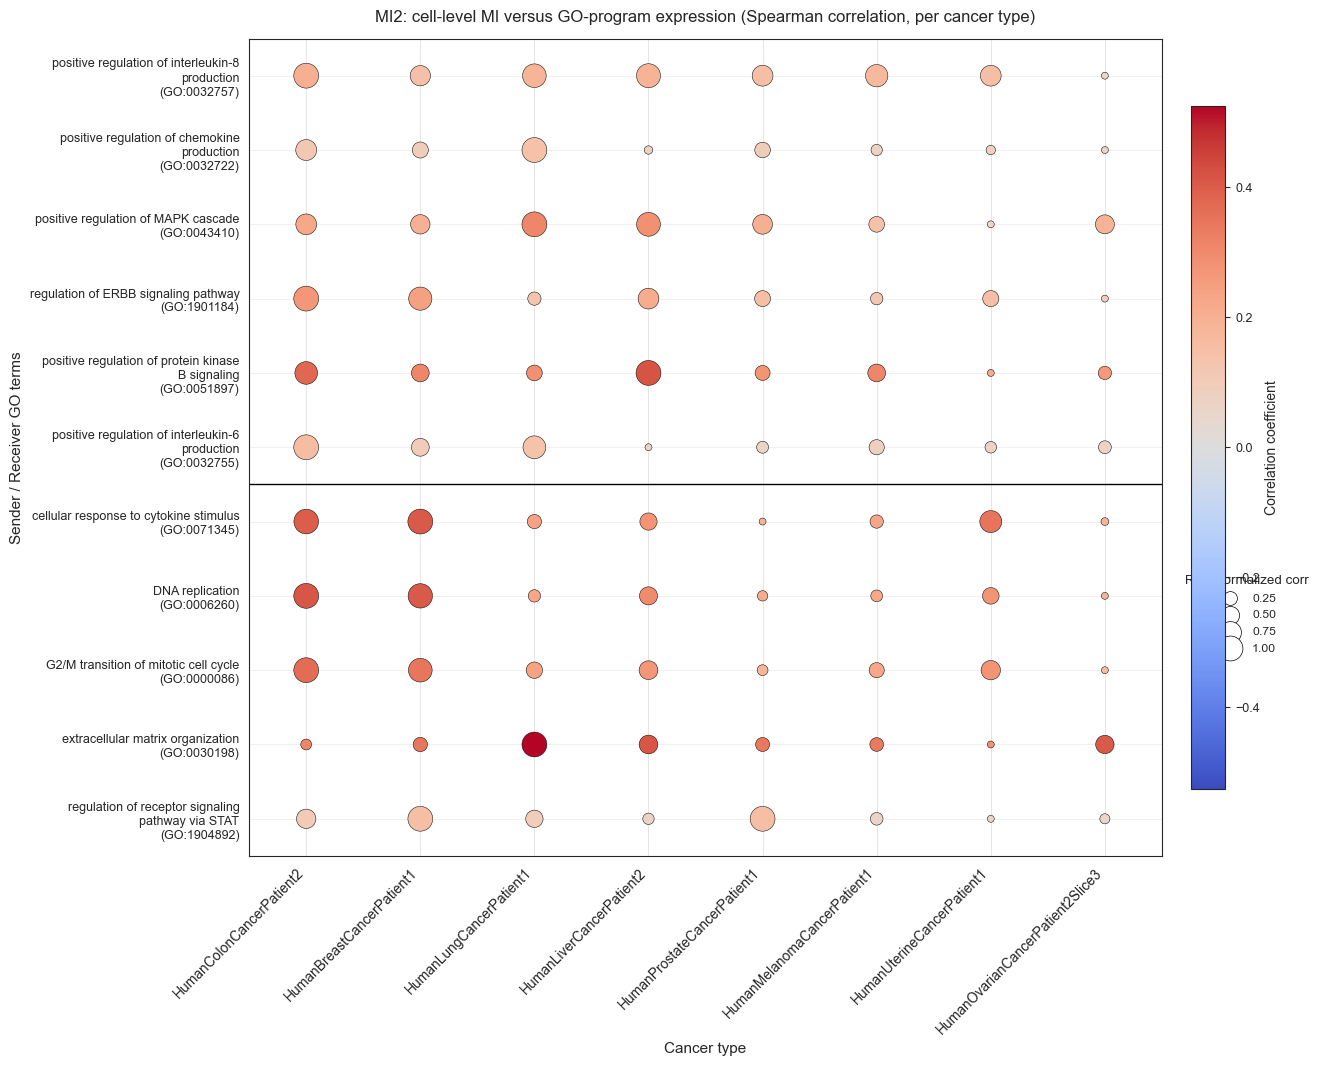

Saved dot plot to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_correlation_dotplot_rowNormSize_spearman_r.png and D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_correlation_dotplot_rowNormSize_spearman_r.pdf
Saved row-normalized table to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_correlation_dotplot_table_rowNorm_spearman_r.csv
Saved column order to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_correlation_column_order_by_meanRowNorm_spearman_r.csv


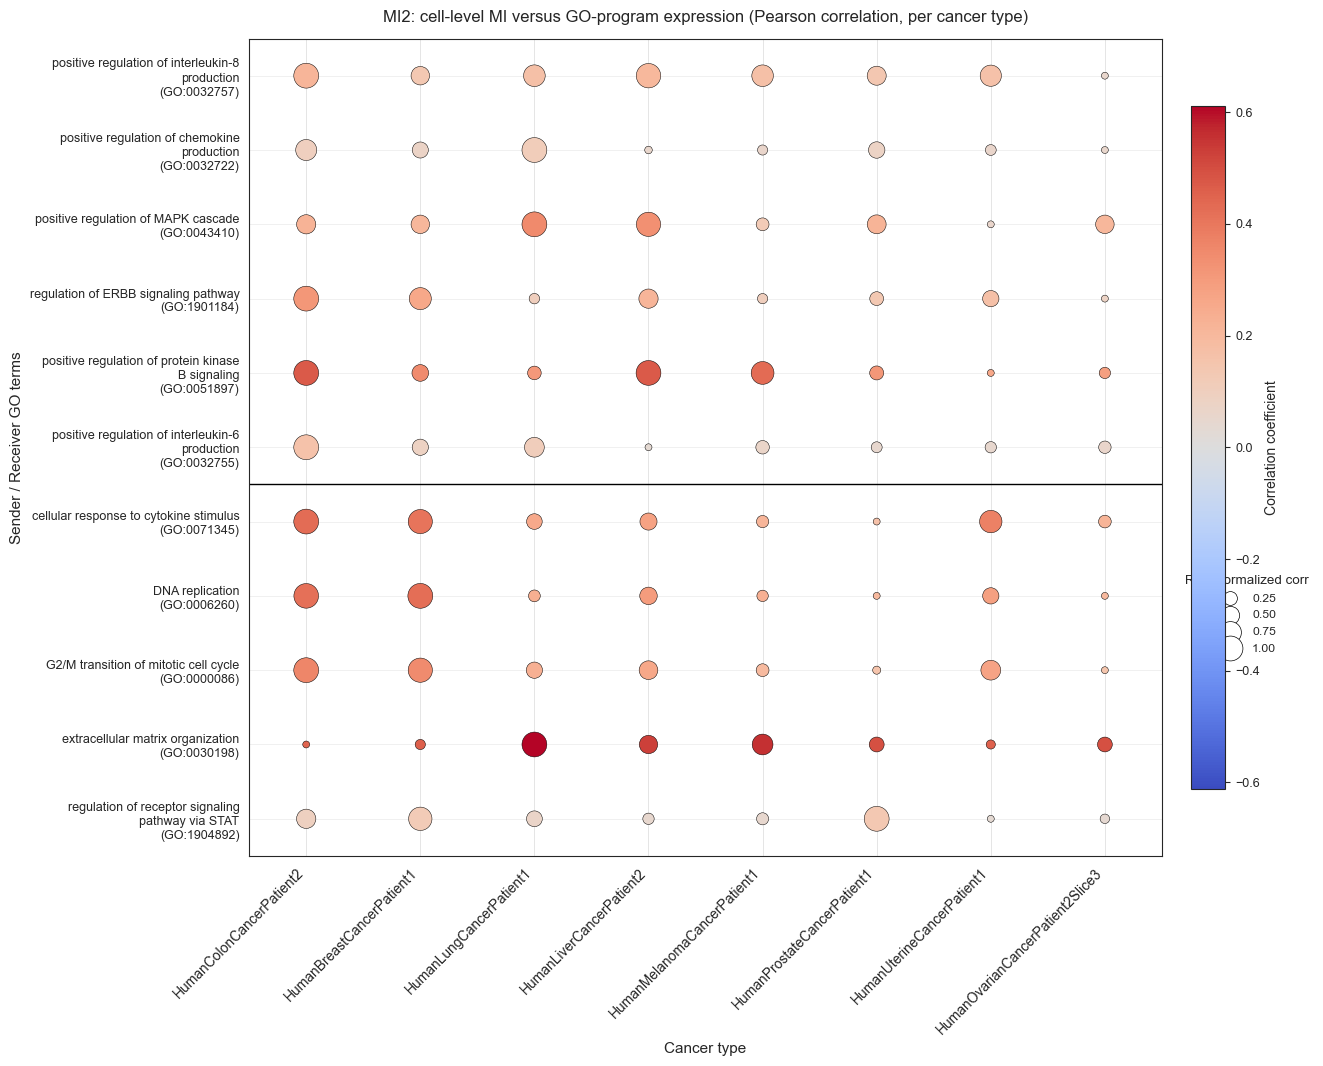

Saved dot plot to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_correlation_dotplot_rowNormSize_pearson_r.png and D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_correlation_dotplot_rowNormSize_pearson_r.pdf
Saved row-normalized table to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_correlation_dotplot_table_rowNorm_pearson_r.csv
Saved column order to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_correlation_column_order_by_meanRowNorm_pearson_r.csv


In [41]:
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
    }
)


def wrap_go_label(go_term, width=38):
    """Wrap GO-term text and move the accession to a separate line."""
    go_term = str(go_term).strip()
    m = re.match(r"^(.*?)(\s*\(\s*GO:\d+\s*\))$", go_term)
    if m:
        main_text = m.group(1).strip()
        go_id = m.group(2).strip()
    else:
        main_text = go_term
        go_id = ""

    wrapped = "\n".join(textwrap.wrap(main_text, width=width))
    if go_id != "":
        wrapped = wrapped + "\n" + go_id
    return wrapped


def make_row_label(side, go_term):
    return f"{side} | {go_term}"


def rowwise_minmax_norm(x):
    """
    Row-wise min-max normalization.
    Returns values in [0, 1].
    If a row has constant values or <2 finite values, assign 1.0 to finite entries.
    """
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    finite_mask = np.isfinite(x)
    if finite_mask.sum() == 0:
        return out

    vals = x[finite_mask]
    vmin = np.min(vals)
    vmax = np.max(vals)

    if np.isclose(vmax, vmin):
        out[finite_mask] = 1.0
    else:
        out[finite_mask] = (vals - vmin) / (vmax - vmin)

    return out


def plot_mi_go_dotplot(
    mi_go_corr_summary_df,
    sender_go_terms_order,
    receiver_go_terms_order,
    mi_label,
    MI_GO_OUTPUT_DIR,
    corr_metric="spearman_r",
):
    """
    Dot plot:
    - color = raw correlation
    - size = row-wise min-max normalized correlation
    - columns sorted by mean normalized correlation
    """
    if corr_metric not in ["spearman_r", "pearson_r"]:
        raise ValueError("corr_metric must be 'spearman_r' or 'pearson_r'")

    plot_rows = []
    for _, row in mi_go_corr_summary_df.iterrows():
        plot_rows.append(
            {
                "Side": row["Side"],
                "CancerType": row["CancerType"],
                "GO_Term": row["GO_Term"],
                "RowLabel": make_row_label(row["Side"], row["GO_Term"]),
                "corr_value": row[corr_metric],
                "n_cells": row["n_cells"],
                "pearson_r": row["pearson_r"],
                "spearman_r": row["spearman_r"],
                "pearson_p": row["pearson_p"],
                "spearman_p": row["spearman_p"],
            }
        )

    mi_go_plot_summary_df = pd.DataFrame(plot_rows)

    plot_df = mi_go_plot_summary_df.copy()
    plot_df = plot_df[plot_df["CancerType"].astype(str) != "Pooled"].copy()
    plot_df = plot_df.dropna(subset=["corr_value"]).copy()

    row_order = (
        [make_row_label("Sender", go_term) for go_term in sender_go_terms_order]
        + [make_row_label("Receiver", go_term) for go_term in receiver_go_terms_order]
    )

    row_to_term = {
        make_row_label("Sender", go_term): go_term for go_term in sender_go_terms_order
    }
    row_to_term.update(
        {make_row_label("Receiver", go_term): go_term for go_term in receiver_go_terms_order}
    )

    plot_df = plot_df[plot_df["RowLabel"].isin(row_order)].copy()

    plot_df["corr_norm_row"] = np.nan
    for row_label in row_order:
        idx = plot_df["RowLabel"] == row_label
        if idx.any():
            plot_df.loc[idx, "corr_norm_row"] = rowwise_minmax_norm(
                plot_df.loc[idx, "corr_value"].to_numpy(dtype=float)
            )

    col_order_df = (
        plot_df.groupby("CancerType", as_index=False)["corr_norm_row"]
        .mean()
        .rename(columns={"corr_norm_row": "mean_normalized_corr"})
        .sort_values("mean_normalized_corr", ascending=False)
        .reset_index(drop=True)
    )
    cancer_type_order_sorted = col_order_df["CancerType"].tolist()

    plot_df["CancerType"] = pd.Categorical(
        plot_df["CancerType"],
        categories=cancer_type_order_sorted,
        ordered=True,
    )
    plot_df["RowLabel"] = pd.Categorical(
        plot_df["RowLabel"],
        categories=row_order,
        ordered=True,
    )
    plot_df = plot_df.sort_values(["RowLabel", "CancerType"]).reset_index(drop=True)

    x_pos = {ct: i for i, ct in enumerate(cancer_type_order_sorted)}
    y_pos = {row_label: i for i, row_label in enumerate(row_order)}

    plot_df["x"] = plot_df["CancerType"].map(x_pos).astype(float)
    plot_df["y"] = plot_df["RowLabel"].map(y_pos).astype(float)

    max_abs_corr = np.nanmax(np.abs(plot_df["corr_value"].to_numpy(dtype=float)))
    if not np.isfinite(max_abs_corr) or max_abs_corr == 0:
        max_abs_corr = 1.0

    norm = TwoSlopeNorm(vmin=-max_abs_corr, vcenter=0.0, vmax=max_abs_corr)

    size_min = 25
    size_max = 320
    plot_df["dot_size"] = size_min + plot_df["corr_norm_row"].fillna(0.0) * (size_max - size_min)

    fig_width = max(8.0, 1.1 * len(cancer_type_order_sorted) + 4.5)
    fig_height = max(6.0, 0.75 * len(row_order) + 2.5)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    sc = ax.scatter(
        plot_df["x"],
        plot_df["y"],
        s=plot_df["dot_size"],
        c=plot_df["corr_value"],
        cmap="coolwarm",
        norm=norm,
        edgecolors="black",
        linewidths=0.35,
    )

    ax.set_xticks(range(len(cancer_type_order_sorted)))
    ax.set_xticklabels(cancer_type_order_sorted, rotation=45, ha="right", fontsize=10)

    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(
        [wrap_go_label(row_to_term[row_label]) for row_label in row_order],
        fontsize=9,
    )

    ax.set_ylim(len(row_order) - 0.5, -0.5)
    ax.set_xlim(-0.5, len(cancer_type_order_sorted) - 0.5)

    for x in np.arange(-0.5, len(cancer_type_order_sorted), 1):
        ax.axvline(x=x + 0.5, color="#E5E5E5", linewidth=0.7, zorder=0)
    for y in np.arange(-0.5, len(row_order), 1):
        ax.axhline(y=y + 0.5, color="#F0F0F0", linewidth=0.7, zorder=0)

    if len(sender_go_terms_order) > 0 and len(receiver_go_terms_order) > 0:
        ax.axhline(y=len(sender_go_terms_order) - 0.5, color="black", linewidth=1.0)

    ax.set_xlabel("Cancer type", fontsize=11)
    ax.set_ylabel("Sender / Receiver GO terms", fontsize=11)

    metric_title = "Spearman correlation" if corr_metric == "spearman_r" else "Pearson correlation"
    ax.set_title(
        f"{mi_label}: cell-level MI versus GO-program expression ({metric_title}, per cancer type)",
        fontsize=12,
        pad=12,
    )

    cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("Correlation coefficient", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    legend_norm_vals = [0.25, 0.50, 0.75, 1.00]
    legend_handles = [
        plt.scatter(
            [],
            [],
            s=size_min + v * (size_max - size_min),
            facecolor="white",
            edgecolor="black",
            linewidth=0.5,
        )
        for v in legend_norm_vals
    ]
    legend_labels = [f"{v:.2f}" for v in legend_norm_vals]

    ax.legend(
        legend_handles,
        legend_labels,
        title="Row-normalized corr",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 0.35),
        borderaxespad=0.0,
    )

    fig.tight_layout()

    plot_base = MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_correlation_dotplot_rowNormSize_{corr_metric}"
    fig.savefig(f"{plot_base}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{plot_base}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    plot_df.to_csv(
        MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_correlation_dotplot_table_rowNorm_{corr_metric}.csv",
        index=False,
    )
    col_order_df.to_csv(
        MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_correlation_column_order_by_meanRowNorm_{corr_metric}.csv",
        index=False,
    )

    print(f"Saved dot plot to: {plot_base}.png and {plot_base}.pdf")
    print(
        "Saved row-normalized table to: "
        f"{MI_GO_OUTPUT_DIR / f'{mi_label}_sender_receiver_go_correlation_dotplot_table_rowNorm_{corr_metric}.csv'}"
    )
    print(
        "Saved column order to: "
        f"{MI_GO_OUTPUT_DIR / f'{mi_label}_sender_receiver_go_correlation_column_order_by_meanRowNorm_{corr_metric}.csv'}"
    )


# ----------------------------------------------------------
# Spearman plot
# ----------------------------------------------------------
plot_mi_go_dotplot(
    mi_go_corr_summary_df=mi_go_corr_summary_df,
    sender_go_terms_order=sender_go_terms_order,
    receiver_go_terms_order=receiver_go_terms_order,
    mi_label=mi_label,
    MI_GO_OUTPUT_DIR=MI_GO_OUTPUT_DIR,
    corr_metric="spearman_r",
)

# ----------------------------------------------------------
# Pearson plot
# ----------------------------------------------------------
plot_mi_go_dotplot(
    mi_go_corr_summary_df=mi_go_corr_summary_df,
    sender_go_terms_order=sender_go_terms_order,
    receiver_go_terms_order=receiver_go_terms_order,
    mi_label=mi_label,
    MI_GO_OUTPUT_DIR=MI_GO_OUTPUT_DIR,
    corr_metric="pearson_r",
)

In [45]:
## Evaluated by log fold change
import gc
import os
import re
from collections import OrderedDict

import numpy as np
import pandas as pd
from scipy import sparse


MI_GO_OUTPUT_DIR = run_dirs["run_dir"] / "MI2_GO_correlation"
MI_GO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

factor_path = run_dirs["run_dir"] / "Factor_envir_use.npy"
sender_go_path = run_dirs["run_dir"] / "GO_enrichment_topregulator_MI2.csv"
receiver_go_path = run_dirs["run_dir"] / "GO_enrichment_toptarget_MI2.csv"

if not factor_path.exists():
    raise FileNotFoundError(f"Could not find: {factor_path}")

if not sender_go_path.exists() or not receiver_go_path.exists():
    raise FileNotFoundError(
        "GO enrichment tables for MI2 were not found. "
        "Please run the GO enrichment cells above before this section."
    )


def go_result_to_gene_table(go_result_df):
    """Expand a GO enrichment result table into a GO-term-to-gene mapping."""
    gene_table = (
        go_result_df.loc[:, ["Term", "Genes"]]
        .assign(
            Gene=lambda d: (
                d["Genes"]
                .fillna("")
                .astype(str)
                .str.split(r"\s*;\s*")
            )
        )
        .explode("Gene")
        .rename(columns={"Term": "GO_Term"})
        .drop(columns=["Genes"])
    )
    gene_table["Gene"] = gene_table["Gene"].astype(str).str.strip()
    gene_table = gene_table[gene_table["Gene"] != ""].drop_duplicates(["Gene", "GO_Term"])
    return gene_table.reset_index(drop=True)


def keep_unique_genesets(go_gene_df):
    """Keep only one GO term for duplicated gene sets while preserving GO-term order."""
    keep_terms = []
    seen_gene_sets = set()

    for go_term in pd.unique(go_gene_df["GO_Term"]):
        genes_cur = (
            go_gene_df.loc[go_gene_df["GO_Term"] == go_term, "Gene"]
            .astype(str)
            .dropna()
            .tolist()
        )
        gene_set_cur = frozenset(g.strip() for g in genes_cur if str(g).strip() != "")
        if gene_set_cur not in seen_gene_sets:
            keep_terms.append(go_term)
            seen_gene_sets.add(gene_set_cur)

    return go_gene_df[go_gene_df["GO_Term"].isin(keep_terms)].copy().reset_index(drop=True)


def ensure_edge_index_e_by_2(edge_index):
    """Convert edge_index to shape (E, 2) if needed."""
    edge_index = np.asarray(edge_index)
    if edge_index.ndim != 2:
        raise ValueError(f"edge_index must be 2D, got shape {edge_index.shape}")

    if edge_index.shape[1] == 2:
        return edge_index.astype(np.int64, copy=False)

    if edge_index.shape[0] == 2:
        return edge_index.T.astype(np.int64, copy=False)

    raise ValueError(f"Unsupported edge_index shape: {edge_index.shape}")


def compute_cell_level_mi(mi_edge, edge_index, n_cells, valid_edge_mask=None):
    """
    Aggregate edge-level MI values into cell-level sending and receiving scores.

    If valid_edge_mask is provided, only edges with valid_edge_mask == True
    are used for the aggregation.
    """
    edge_index = np.asarray(edge_index)
    mi_edge = np.asarray(mi_edge, dtype=np.float32)

    if valid_edge_mask is None:
        valid_edge_mask = np.ones(edge_index.shape[0], dtype=bool)
    else:
        valid_edge_mask = np.asarray(valid_edge_mask, dtype=bool)

    src = edge_index[valid_edge_mask, 0]
    dst = edge_index[valid_edge_mask, 1]
    mi_edge_use = mi_edge[valid_edge_mask]

    send_sum = np.bincount(src, weights=mi_edge_use, minlength=n_cells).astype(np.float64, copy=False)
    send_cnt = np.bincount(src, minlength=n_cells).astype(np.float64, copy=False)
    recv_sum = np.bincount(dst, weights=mi_edge_use, minlength=n_cells).astype(np.float64, copy=False)
    recv_cnt = np.bincount(dst, minlength=n_cells).astype(np.float64, copy=False)

    send_score = np.full(n_cells, np.nan, dtype=np.float32)
    recv_score = np.full(n_cells, np.nan, dtype=np.float32)

    np.divide(send_sum, send_cnt, out=send_score, where=send_cnt > 0)
    np.divide(recv_sum, recv_cnt, out=recv_score, where=recv_cnt > 0)

    return send_score, recv_score


def compute_go_average_expression_from_adata(adata_obj, cell_idx, go_gene_table):
    """
    Compute per-cell mean expression for each GO program from the observed expression matrix.
    """
    gene_names = np.asarray(adata_obj.var_names).astype(str)
    gene_index_map = {gene: idx for idx, gene in enumerate(gene_names)}
    expr_matrix = adata_obj.X
    go_avg = OrderedDict()

    for go_term in pd.unique(go_gene_table["GO_Term"]):
        genes_cur = (
            go_gene_table.loc[go_gene_table["GO_Term"] == go_term, "Gene"]
            .astype(str)
            .tolist()
        )
        gene_idx_cur = [gene_index_map[g] for g in genes_cur if g in gene_index_map]
        if len(gene_idx_cur) == 0:
            continue

        if sparse.issparse(expr_matrix):
            vals = np.asarray(expr_matrix[cell_idx][:, gene_idx_cur].mean(axis=1)).ravel()
        else:
            vals = np.asarray(expr_matrix[np.ix_(cell_idx, gene_idx_cur)].mean(axis=1)).ravel()

        go_avg[go_term] = vals.astype(np.float32, copy=False)

    return go_avg


def summarize_median_split_logfc(mi_values, expr_values, eps=1e-8):
    """
    Split cells into High/Low groups by the median of MI strength and compute:
        log((mean_high + eps) / (mean_low + eps))

    Cells equal to the median are included in the High group.
    """
    mi_values = np.asarray(mi_values, dtype=float)
    expr_values = np.asarray(expr_values, dtype=float)

    mask = np.isfinite(mi_values) & np.isfinite(expr_values)
    mi_values = mi_values[mask]
    expr_values = expr_values[mask]

    out = {
        "n_cells": int(mi_values.size),
        "n_high": 0,
        "n_low": 0,
        "median_mi": np.nan,
        "mean_mi_high": np.nan,
        "mean_mi_low": np.nan,
        "mean_expr_high": np.nan,
        "mean_expr_low": np.nan,
        "log_fc_high_vs_low": np.nan,
    }

    if mi_values.size == 0:
        return out

    median_mi = np.median(mi_values)
    high_mask = mi_values >= median_mi
    low_mask = mi_values < median_mi

    out["median_mi"] = float(median_mi)
    out["n_high"] = int(np.sum(high_mask))
    out["n_low"] = int(np.sum(low_mask))

    if out["n_high"] > 0:
        out["mean_mi_high"] = float(np.mean(mi_values[high_mask]))
        out["mean_expr_high"] = float(np.mean(expr_values[high_mask]))

    if out["n_low"] > 0:
        out["mean_mi_low"] = float(np.mean(mi_values[low_mask]))
        out["mean_expr_low"] = float(np.mean(expr_values[low_mask]))

    if out["n_high"] > 0 and out["n_low"] > 0:
        out["log_fc_high_vs_low"] = float(
            np.log2((out["mean_expr_high"] + eps) / (out["mean_expr_low"] + eps))
        )

    return out


def summarize_effect_store(store_dict, side_label, eps=1e-8):
    """Build a cancer-type-resolved median-split logFC table."""
    rows = []

    for cancer_type in store_dict:
        for go_term in store_dict[cancer_type]:
            mi_vals = np.asarray(store_dict[cancer_type][go_term]["mi"], dtype=np.float32)
            expr_vals = np.asarray(store_dict[cancer_type][go_term]["expr"], dtype=np.float32)

            stats = summarize_median_split_logfc(mi_vals, expr_vals, eps=eps)
            rows.append(
                {
                    "Side": side_label,
                    "CancerType": cancer_type,
                    "GO_Term": go_term,
                    **stats,
                }
            )

    return pd.DataFrame(rows)


def append_batch_values(store_dict, cancer_type, go_term, mi_values, expr_values):
    """Append one batch of paired MI and GO-expression values."""
    if cancer_type not in store_dict:
        store_dict[cancer_type] = {}

    if go_term not in store_dict[cancer_type]:
        store_dict[cancer_type][go_term] = {"mi": [], "expr": []}

    store_dict[cancer_type][go_term]["mi"].extend(np.asarray(mi_values, dtype=np.float32).tolist())
    store_dict[cancer_type][go_term]["expr"].extend(np.asarray(expr_values, dtype=np.float32).tolist())


sender_go_gene_table = keep_unique_genesets(
    go_result_to_gene_table(pd.read_csv(sender_go_path))
)
receiver_go_gene_table = keep_unique_genesets(
    go_result_to_gene_table(pd.read_csv(receiver_go_path))
)

sender_go_terms_order = list(pd.unique(sender_go_gene_table["GO_Term"]))
receiver_go_terms_order = list(pd.unique(receiver_go_gene_table["GO_Term"]))

mi_label = str(MI_OI)
mi_digits = re.findall(r"\d+", mi_label)
if len(mi_digits) == 0:
    raise ValueError(f"Could not parse MI index from MI_OI={MI_OI!r}")
mi_index = int(mi_digits[0]) - 1

batch_sample_ids = [
    str(np.asarray(processed.spidernet_data[i]["sample"]).astype(str)[0])
    for i in range(len(processed.spidernet_data))
]
batch_cancer_types = [sample_id.split("_")[0] for sample_id in batch_sample_ids]
cancer_type_order = list(dict.fromkeys(batch_cancer_types))

edge_counts = np.asarray(
    [
        ensure_edge_index_e_by_2(
            processed.spidernet_data[i]["edge_index"].cpu().numpy()
        ).shape[0]
        for i in range(len(processed.spidernet_data))
    ],
    dtype=np.int64,
)
edge_offsets = np.concatenate(([0], np.cumsum(edge_counts)))

Factor_envir_use_mmap = np.load(factor_path, mmap_mode="r")

sender_effect_store = OrderedDict()
receiver_effect_store = OrderedDict()
mi_go_batch_summary = []

LOGFC_EPS = 1e-8

for batch_idx in range(len(processed.adata_list)):
    adata_batch = processed.adata_list[batch_idx]
    cell_types_batch = adata_batch.obs[CELL_TYPE_COL].astype(str).to_numpy()
    tumor_idx = np.flatnonzero(np.char.endswith(cell_types_batch.astype(str), "-cancercell"))

    sample_id_cur = batch_sample_ids[batch_idx]
    cancer_type_cur = batch_cancer_types[batch_idx]

    if tumor_idx.size == 0:
        mi_go_batch_summary.append(
            {
                "BatchIndex": batch_idx,
                "SampleID": sample_id_cur,
                "CancerType": cancer_type_cur,
                "n_tumor_cells": 0,
                "n_tumor_tumor_edges": 0,
                "status": "skipped_no_tumor_cells",
            }
        )
        continue

    edge_index_cur = ensure_edge_index_e_by_2(
        processed.spidernet_data[batch_idx]["edge_index"].cpu().numpy()
    )
    start_idx = edge_offsets[batch_idx]
    end_idx = edge_offsets[batch_idx + 1]
    mi_edge_cur = np.asarray(Factor_envir_use_mmap[start_idx:end_idx, mi_index], dtype=np.float32)

    if mi_edge_cur.shape[0] != edge_index_cur.shape[0]:
        raise ValueError(
            f"Mismatch between edge counts and MI values for batch {batch_idx}: "
            f"{edge_index_cur.shape[0]} edges versus {mi_edge_cur.shape[0]} MI rows."
        )

    # Only keep cancercell-cancercell edges when computing cell-level MI
    src_idx = edge_index_cur[:, 0]
    dst_idx = edge_index_cur[:, 1]

    src_is_tumor = np.char.endswith(cell_types_batch[src_idx].astype(str), "-cancercell")
    dst_is_tumor = np.char.endswith(cell_types_batch[dst_idx].astype(str), "-cancercell")
    tumor_tumor_edge_mask = src_is_tumor & dst_is_tumor

    if not np.any(tumor_tumor_edge_mask):
        mi_go_batch_summary.append(
            {
                "BatchIndex": batch_idx,
                "SampleID": sample_id_cur,
                "CancerType": cancer_type_cur,
                "n_tumor_cells": int(tumor_idx.size),
                "n_tumor_tumor_edges": 0,
                "status": "skipped_no_tumor_tumor_edges",
            }
        )
        continue

    sending_mi_cur, receiver_mi_cur = compute_cell_level_mi(
        mi_edge=mi_edge_cur,
        edge_index=edge_index_cur,
        n_cells=adata_batch.n_obs,
        valid_edge_mask=tumor_tumor_edge_mask,
    )

    sending_mi_tumor = sending_mi_cur[tumor_idx]
    receiver_mi_tumor = receiver_mi_cur[tumor_idx]

    sender_go_avg_cur = compute_go_average_expression_from_adata(
        adata_obj=adata_batch,
        cell_idx=tumor_idx,
        go_gene_table=sender_go_gene_table,
    )
    receiver_go_avg_cur = compute_go_average_expression_from_adata(
        adata_obj=adata_batch,
        cell_idx=tumor_idx,
        go_gene_table=receiver_go_gene_table,
    )

    for go_term, expr_vals in sender_go_avg_cur.items():
        valid_mask = np.isfinite(sending_mi_tumor) & np.isfinite(expr_vals)
        if np.any(valid_mask):
            append_batch_values(
                sender_effect_store,
                cancer_type_cur,
                go_term,
                sending_mi_tumor[valid_mask],
                expr_vals[valid_mask],
            )

    for go_term, expr_vals in receiver_go_avg_cur.items():
        valid_mask = np.isfinite(receiver_mi_tumor) & np.isfinite(expr_vals)
        if np.any(valid_mask):
            append_batch_values(
                receiver_effect_store,
                cancer_type_cur,
                go_term,
                receiver_mi_tumor[valid_mask],
                expr_vals[valid_mask],
            )

    mi_go_batch_summary.append(
        {
            "BatchIndex": batch_idx,
            "SampleID": sample_id_cur,
            "CancerType": cancer_type_cur,
            "n_tumor_cells": int(tumor_idx.size),
            "n_tumor_tumor_edges": int(np.sum(tumor_tumor_edge_mask)),
            "status": "finished",
        }
    )

    release_memory(
        "adata_batch",
        "cell_types_batch",
        "tumor_idx",
        "edge_index_cur",
        "mi_edge_cur",
        "src_idx",
        "dst_idx",
        "src_is_tumor",
        "dst_is_tumor",
        "tumor_tumor_edge_mask",
        "sending_mi_cur",
        "receiver_mi_cur",
        "sending_mi_tumor",
        "receiver_mi_tumor",
        "sender_go_avg_cur",
        "receiver_go_avg_cur",
        namespace=globals(),
        run_gc=True,
        clear_cuda=True,
    )

mi_go_batch_summary_df = pd.DataFrame(mi_go_batch_summary)
sender_effect_summary_df = summarize_effect_store(
    sender_effect_store,
    side_label="Sender",
    eps=LOGFC_EPS,
)
receiver_effect_summary_df = summarize_effect_store(
    receiver_effect_store,
    side_label="Receiver",
    eps=LOGFC_EPS,
)

mi_go_effect_summary_df = pd.concat(
    [sender_effect_summary_df, receiver_effect_summary_df],
    axis=0,
    ignore_index=True,
)

mi_go_batch_summary_df.to_csv(
    MI_GO_OUTPUT_DIR / f"{mi_label}_celllevel_go_batch_summary.csv",
    index=False,
)
mi_go_effect_summary_df.to_csv(
    MI_GO_OUTPUT_DIR / f"{mi_label}_celllevel_go_medianSplit_logFC_summary_per_cancertype.csv",
    index=False,
)

print(f"Saved batch summary to: {MI_GO_OUTPUT_DIR / f'{mi_label}_celllevel_go_batch_summary.csv'}")
print(
    "Saved cancer-type-resolved median-split logFC summary to: "
    f"{MI_GO_OUTPUT_DIR / f'{mi_label}_celllevel_go_medianSplit_logFC_summary_per_cancertype.csv'}"
)

display(
    mi_go_effect_summary_df
    .sort_values(["Side", "GO_Term", "CancerType"])
    .reset_index(drop=True)
)

Saved batch summary to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_celllevel_go_batch_summary.csv
Saved cancer-type-resolved median-split logFC summary to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_celllevel_go_medianSplit_logFC_summary_per_cancertype.csv


,Side,CancerType,GO_Term,n_cells,n_high,n_low,median_mi,mean_mi_high,mean_mi_low,mean_expr_high,mean_expr_low,log_fc_high_vs_low
0,Receiver,HumanBreastCancerPatient1,DNA replication (GO:0006260),347229,173615,173614,0.301110,0.409036,0.168950,2.223490,1.431347,0.635453
1,Receiver,HumanColonCancerPatient2,DNA replication (GO:0006260),509923,254968,254955,0.452073,0.556379,0.296337,2.208767,1.251255,0.819865
2,Receiver,HumanLiverCancerPatient2,DNA replication (GO:0006260),264303,132154,132149,0.303014,0.381473,0.192232,0.923037,0.477209,0.951768
3,Receiver,HumanLungCancerPatient1,DNA replication (GO:0006260),247470,123735,123735,0.352283,0.473704,0.186791,1.032059,0.660703,0.643451
4,Receiver,HumanMelanomaCancerPatient1,DNA replication (GO:0006260),234461,117240,117221,0.346848,0.416253,0.241426,0.950218,0.594009,0.677774
...,...,...,...,...,...,...,...,...,...,...,...,...
83,Sender,HumanLungCancerPatient1,regulation of ERBB signaling pathway (GO:1901184),248546,124273,124273,0.346781,0.482290,0.177716,0.299692,0.194881,0.620888
84,Sender,HumanMelanomaCancerPatient1,regulation of ERBB signaling pathway (GO:1901184),235673,117843,117830,0.339581,0.418439,0.239222,0.208888,0.113194,0.883933
85,Sender,HumanOvarianCancerPatient2Slice3,regulation of ERBB signaling pathway (GO:1901184),116776,58399,58377,0.368880,0.476652,0.233148,0.245479,0.179726,0.449803
86,Sender,HumanProstateCancerPatient1,regulation of ERBB signaling pathway (GO:1901184),406088,203077,203011,0.327723,0.401198,0.229565,0.556335,0.358842,0.632604


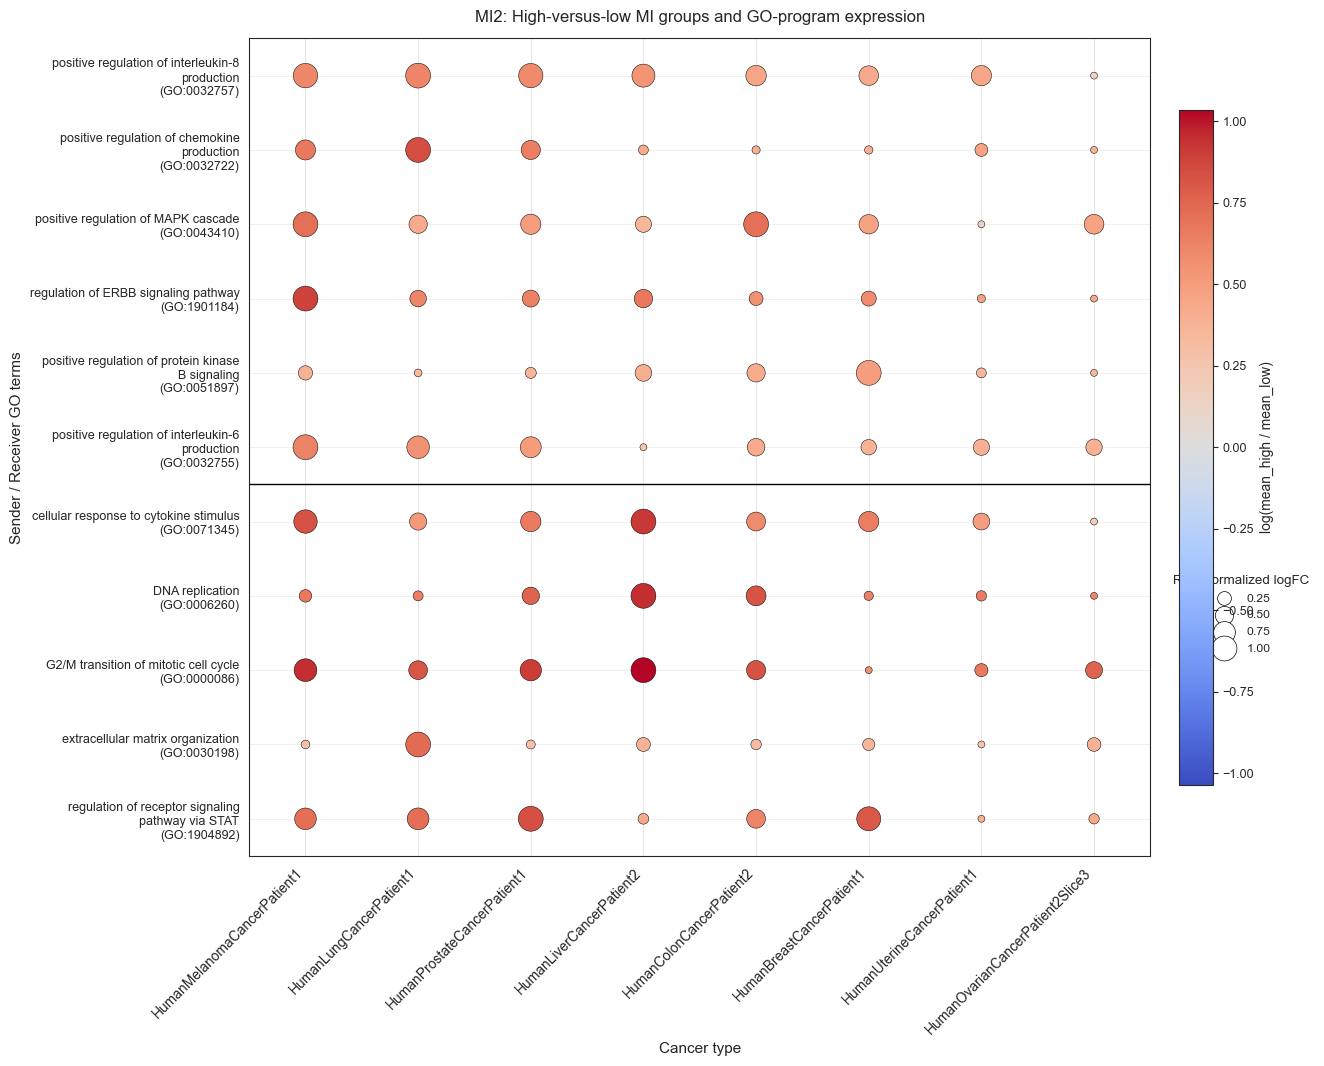

Saved dot plot to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_dotplot.png and D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_dotplot.pdf
Saved row-normalized table to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_dotplot_table_rowNorm.csv
Saved column order to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_column_order_by_meanRowNorm.csv


In [46]:
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
    }
)


def wrap_go_label(go_term, width=38):
    """Wrap GO-term text and move the accession to a separate line."""
    go_term = str(go_term).strip()
    m = re.match(r"^(.*?)(\s*\(\s*GO:\d+\s*\))$", go_term)
    if m:
        main_text = m.group(1).strip()
        go_id = m.group(2).strip()
    else:
        main_text = go_term
        go_id = ""

    wrapped = "\n".join(textwrap.wrap(main_text, width=width))
    if go_id != "":
        wrapped = wrapped + "\n" + go_id
    return wrapped


def make_row_label(side, go_term):
    return f"{side} | {go_term}"


def rowwise_minmax_norm(x):
    """
    Row-wise min-max normalization.
    Returns values in [0, 1].
    If a row has constant values or <2 finite values, assign 1.0 to finite entries.
    """
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    finite_mask = np.isfinite(x)
    if finite_mask.sum() == 0:
        return out

    vals = x[finite_mask]
    vmin = np.min(vals)
    vmax = np.max(vals)

    if np.isclose(vmax, vmin):
        out[finite_mask] = 1.0
    else:
        out[finite_mask] = (vals - vmin) / (vmax - vmin)

    return out


def plot_mi_go_logfc_dotplot(
    mi_go_effect_summary_df,
    sender_go_terms_order,
    receiver_go_terms_order,
    mi_label,
    MI_GO_OUTPUT_DIR,
):
    """
    Dot plot:
    - color = raw logFC
    - size = row-wise min-max normalized logFC
    - columns sorted by mean normalized logFC
    """
    plot_rows = []
    for _, row in mi_go_effect_summary_df.iterrows():
        plot_rows.append(
            {
                "Side": row["Side"],
                "CancerType": row["CancerType"],
                "GO_Term": row["GO_Term"],
                "RowLabel": make_row_label(row["Side"], row["GO_Term"]),
                "effect_value": row["log_fc_high_vs_low"],
                "n_cells": row["n_cells"],
                "n_high": row["n_high"],
                "n_low": row["n_low"],
                "mean_expr_high": row["mean_expr_high"],
                "mean_expr_low": row["mean_expr_low"],
            }
        )

    plot_summary_df = pd.DataFrame(plot_rows)
    plot_df = plot_summary_df.dropna(subset=["effect_value"]).copy()

    row_order = (
        [make_row_label("Sender", go_term) for go_term in sender_go_terms_order]
        + [make_row_label("Receiver", go_term) for go_term in receiver_go_terms_order]
    )

    row_to_term = {
        make_row_label("Sender", go_term): go_term for go_term in sender_go_terms_order
    }
    row_to_term.update(
        {make_row_label("Receiver", go_term): go_term for go_term in receiver_go_terms_order}
    )

    plot_df = plot_df[plot_df["RowLabel"].isin(row_order)].copy()

    plot_df["effect_norm_row"] = np.nan
    for row_label in row_order:
        idx = plot_df["RowLabel"] == row_label
        if idx.any():
            plot_df.loc[idx, "effect_norm_row"] = rowwise_minmax_norm(
                plot_df.loc[idx, "effect_value"].to_numpy(dtype=float)
            )

    col_order_df = (
        plot_df.groupby("CancerType", as_index=False)["effect_norm_row"]
        .mean()
        .rename(columns={"effect_norm_row": "mean_normalized_logFC"})
        .sort_values("mean_normalized_logFC", ascending=False)
        .reset_index(drop=True)
    )
    cancer_type_order_sorted = col_order_df["CancerType"].tolist()

    plot_df["CancerType"] = pd.Categorical(
        plot_df["CancerType"],
        categories=cancer_type_order_sorted,
        ordered=True,
    )
    plot_df["RowLabel"] = pd.Categorical(
        plot_df["RowLabel"],
        categories=row_order,
        ordered=True,
    )
    plot_df = plot_df.sort_values(["RowLabel", "CancerType"]).reset_index(drop=True)

    x_pos = {ct: i for i, ct in enumerate(cancer_type_order_sorted)}
    y_pos = {row_label: i for i, row_label in enumerate(row_order)}

    plot_df["x"] = plot_df["CancerType"].map(x_pos).astype(float)
    plot_df["y"] = plot_df["RowLabel"].map(y_pos).astype(float)

    max_abs_effect = np.nanmax(np.abs(plot_df["effect_value"].to_numpy(dtype=float)))
    if not np.isfinite(max_abs_effect) or max_abs_effect == 0:
        max_abs_effect = 1.0

    norm = TwoSlopeNorm(vmin=-max_abs_effect, vcenter=0.0, vmax=max_abs_effect)

    size_min = 25
    size_max = 320
    plot_df["dot_size"] = size_min + plot_df["effect_norm_row"].fillna(0.0) * (size_max - size_min)

    fig_width = max(8.0, 1.1 * len(cancer_type_order_sorted) + 4.5)
    fig_height = max(6.0, 0.75 * len(row_order) + 2.5)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    sc = ax.scatter(
        plot_df["x"],
        plot_df["y"],
        s=plot_df["dot_size"],
        c=plot_df["effect_value"],
        cmap="coolwarm",
        norm=norm,
        edgecolors="black",
        linewidths=0.35,
    )

    ax.set_xticks(range(len(cancer_type_order_sorted)))
    ax.set_xticklabels(cancer_type_order_sorted, rotation=45, ha="right", fontsize=10)

    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(
        [wrap_go_label(row_to_term[row_label]) for row_label in row_order],
        fontsize=9,
    )

    ax.set_ylim(len(row_order) - 0.5, -0.5)
    ax.set_xlim(-0.5, len(cancer_type_order_sorted) - 0.5)

    for x in np.arange(-0.5, len(cancer_type_order_sorted), 1):
        ax.axvline(x=x + 0.5, color="#E5E5E5", linewidth=0.7, zorder=0)
    for y in np.arange(-0.5, len(row_order), 1):
        ax.axhline(y=y + 0.5, color="#F0F0F0", linewidth=0.7, zorder=0)

    if len(sender_go_terms_order) > 0 and len(receiver_go_terms_order) > 0:
        ax.axhline(y=len(sender_go_terms_order) - 0.5, color="black", linewidth=1.0)

    ax.set_xlabel("Cancer type", fontsize=11)
    ax.set_ylabel("Sender / Receiver GO terms", fontsize=11)
    ax.set_title(
        f"{mi_label}: High-versus-low MI groups and GO-program expression",
        fontsize=12,
        pad=12,
    )

    cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("log(mean_high / mean_low)", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    legend_norm_vals = [0.25, 0.50, 0.75, 1.00]
    legend_handles = [
        plt.scatter(
            [],
            [],
            s=size_min + v * (size_max - size_min),
            facecolor="white",
            edgecolor="black",
            linewidth=0.5,
        )
        for v in legend_norm_vals
    ]
    legend_labels = [f"{v:.2f}" for v in legend_norm_vals]

    ax.legend(
        legend_handles,
        legend_labels,
        title="Row-normalized logFC",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 0.35),
        borderaxespad=0.0,
    )

    fig.tight_layout()

    plot_base = MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_medianSplit_logFC_dotplot"
    fig.savefig(f"{plot_base}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{plot_base}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    plot_df.to_csv(
        MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_medianSplit_logFC_dotplot_table_rowNorm.csv",
        index=False,
    )
    col_order_df.to_csv(
        MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_medianSplit_logFC_column_order_by_meanRowNorm.csv",
        index=False,
    )

    print(f"Saved dot plot to: {plot_base}.png and {plot_base}.pdf")
    print(
        "Saved row-normalized table to: "
        f"{MI_GO_OUTPUT_DIR / f'{mi_label}_sender_receiver_go_medianSplit_logFC_dotplot_table_rowNorm.csv'}"
    )
    print(
        "Saved column order to: "
        f"{MI_GO_OUTPUT_DIR / f'{mi_label}_sender_receiver_go_medianSplit_logFC_column_order_by_meanRowNorm.csv'}"
    )


plot_mi_go_logfc_dotplot(
    mi_go_effect_summary_df=mi_go_effect_summary_df,
    sender_go_terms_order=sender_go_terms_order,
    receiver_go_terms_order=receiver_go_terms_order,
    mi_label=mi_label,
    MI_GO_OUTPUT_DIR=MI_GO_OUTPUT_DIR,
)

C:\Users\junji\AppData\Local\Temp\ipykernel_15808\3742695113.py:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm").copy()


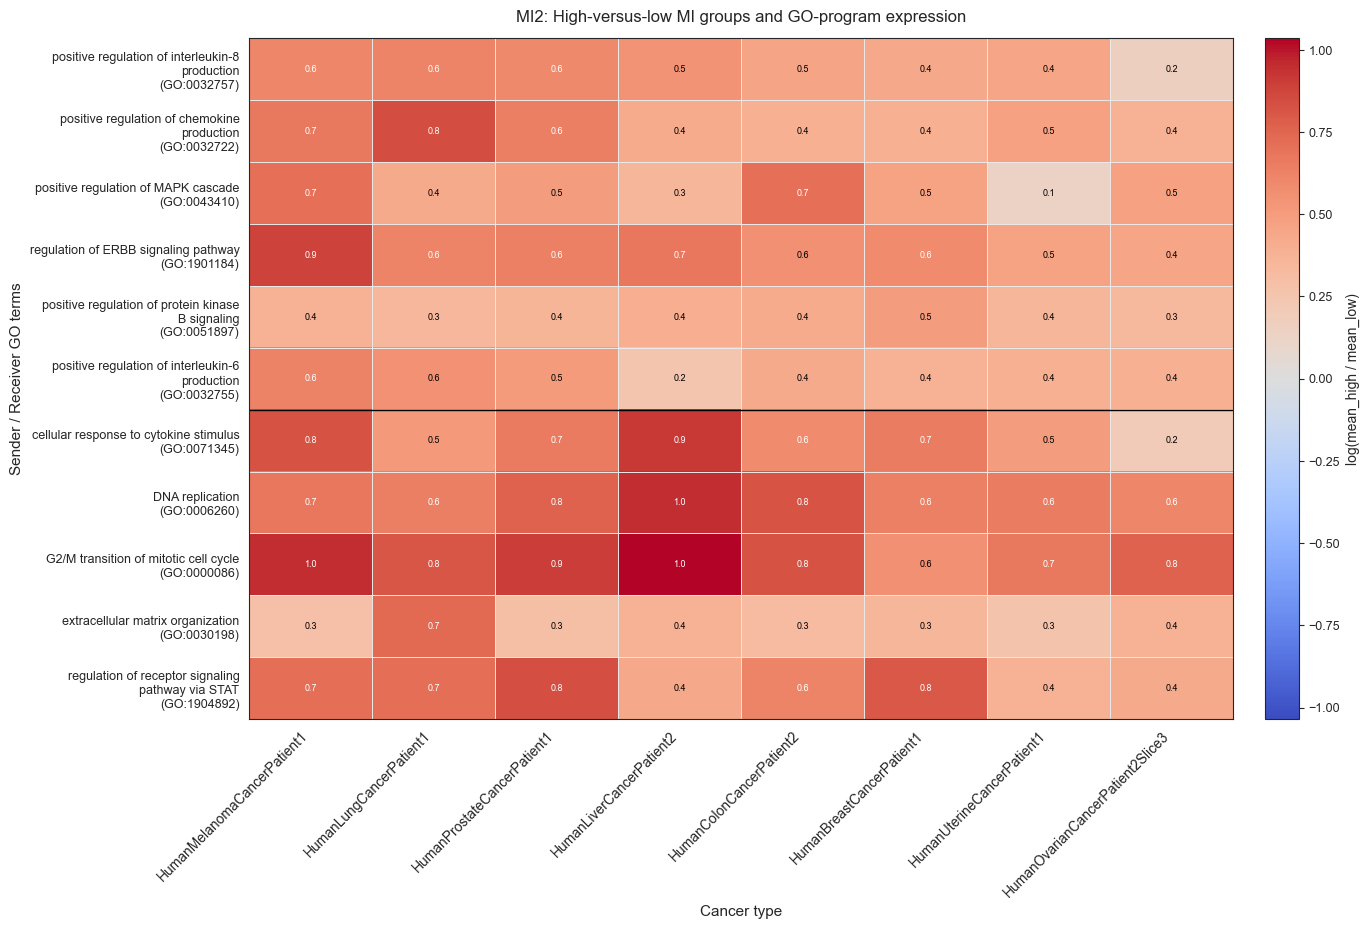

Saved heatmap to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_heatmap_colSumSorted.png and D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_heatmap_colSumSorted.pdf
Saved heatmap matrix to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_heatmap_matrix_colSumSorted.csv
Saved column order to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_column_order_by_colSum.csv


In [47]:
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
    }
)


def wrap_go_label(go_term, width=38):
    """Wrap GO-term text and move the accession to a separate line."""
    go_term = str(go_term).strip()
    m = re.match(r"^(.*?)(\s*\(\s*GO:\d+\s*\))$", go_term)
    if m:
        main_text = m.group(1).strip()
        go_id = m.group(2).strip()
    else:
        main_text = go_term
        go_id = ""

    wrapped = "\n".join(textwrap.wrap(main_text, width=width))
    if go_id != "":
        wrapped = wrapped + "\n" + go_id
    return wrapped


def make_row_label(side, go_term):
    return f"{side} | {go_term}"


def plot_mi_go_logfc_heatmap(
    mi_go_effect_summary_df,
    sender_go_terms_order,
    receiver_go_terms_order,
    mi_label,
    MI_GO_OUTPUT_DIR,
    show_values=True,
    value_fmt=".1f",
):
    """
    Heatmap:
    - rows = sender GO terms + receiver GO terms
    - columns sorted by column sum of raw logFC, descending
    - color = raw logFC
    - text in each cell = raw logFC
    """

    plot_rows = []
    for _, row in mi_go_effect_summary_df.iterrows():
        plot_rows.append(
            {
                "Side": row["Side"],
                "CancerType": row["CancerType"],
                "GO_Term": row["GO_Term"],
                "RowLabel": make_row_label(row["Side"], row["GO_Term"]),
                "effect_value": row["log_fc_high_vs_low"],
                "n_cells": row["n_cells"],
                "n_high": row["n_high"],
                "n_low": row["n_low"],
                "mean_expr_high": row["mean_expr_high"],
                "mean_expr_low": row["mean_expr_low"],
            }
        )

    plot_summary_df = pd.DataFrame(plot_rows)
    plot_df = plot_summary_df.dropna(subset=["effect_value"]).copy()

    row_order = (
        [make_row_label("Sender", go_term) for go_term in sender_go_terms_order]
        + [make_row_label("Receiver", go_term) for go_term in receiver_go_terms_order]
    )

    row_to_term = {
        make_row_label("Sender", go_term): go_term for go_term in sender_go_terms_order
    }
    row_to_term.update(
        {
            make_row_label("Receiver", go_term): go_term
            for go_term in receiver_go_terms_order
        }
    )

    plot_df = plot_df[plot_df["RowLabel"].isin(row_order)].copy()

    # Raw logFC matrix
    raw_matrix = (
        plot_df.pivot_table(
            index="RowLabel",
            columns="CancerType",
            values="effect_value",
            aggfunc="mean",
        )
        .reindex(index=row_order)
    )

    # Sort cancer types by column sum of raw logFC, descending
    col_order_df = (
        raw_matrix.sum(axis=0, skipna=True)
        .sort_values(ascending=False)
        .rename("column_sum_logFC")
        .reset_index()
        .rename(columns={"index": "CancerType"})
    )
    cancer_type_order_sorted = col_order_df["CancerType"].tolist()

    raw_matrix = raw_matrix.reindex(columns=cancer_type_order_sorted)

    heatmap_matrix = raw_matrix.copy()

    max_abs_effect = np.nanmax(np.abs(heatmap_matrix.to_numpy(dtype=float)))
    if not np.isfinite(max_abs_effect) or max_abs_effect == 0:
        max_abs_effect = 1.0

    norm = TwoSlopeNorm(vmin=-max_abs_effect, vcenter=0.0, vmax=max_abs_effect)

    cmap = mpl.cm.get_cmap("coolwarm").copy()
    cmap.set_bad("#F2F2F2")

    fig_width = max(8.5, 1.1 * len(cancer_type_order_sorted) + 5.0)
    fig_height = max(6.5, 0.58 * len(row_order) + 3.0)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    im = ax.imshow(
        heatmap_matrix.to_numpy(dtype=float),
        cmap=cmap,
        norm=norm,
        aspect="auto",
        interpolation="none",
    )

    # Ticks
    ax.set_xticks(np.arange(len(cancer_type_order_sorted)))
    ax.set_xticklabels(cancer_type_order_sorted, rotation=45, ha="right", fontsize=10)

    ax.set_yticks(np.arange(len(row_order)))
    ax.set_yticklabels(
        [wrap_go_label(row_to_term[row_label]) for row_label in row_order],
        fontsize=9,
    )

    # Gridlines
    ax.set_xticks(np.arange(-0.5, len(cancer_type_order_sorted), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_order), 1), minor=True)
    ax.grid(which="minor", color="#EAEAEA", linestyle="-", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Separate sender and receiver
    if len(sender_go_terms_order) > 0 and len(receiver_go_terms_order) > 0:
        ax.axhline(y=len(sender_go_terms_order) - 0.5, color="black", linewidth=1.0)

    ax.set_xlabel("Cancer type", fontsize=11)
    ax.set_ylabel("Sender / Receiver GO terms", fontsize=11)
    ax.set_title(
        f"{mi_label}: High-versus-low MI groups and GO-program expression",
        fontsize=12,
        pad=12,
    )

    # Add values in cells
    if show_values:
        matrix_for_text = heatmap_matrix.to_numpy(dtype=float)
        for i in range(matrix_for_text.shape[0]):
            for j in range(matrix_for_text.shape[1]):
                val = matrix_for_text[i, j]
                if np.isfinite(val):
                    # Use white text on strong colors, black otherwise
                    text_color = "white" if abs(val) >= 0.55 * max_abs_effect else "black"
                    ax.text(
                        j,
                        i,
                        format(val, value_fmt),
                        ha="center",
                        va="center",
                        fontsize=6.5,
                        color=text_color,
                    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("log(mean_high / mean_low)", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    fig.tight_layout()

    plot_base = MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_medianSplit_logFC_heatmap_colSumSorted"
    fig.savefig(f"{plot_base}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{plot_base}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    heatmap_matrix.to_csv(
        MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_medianSplit_logFC_heatmap_matrix_colSumSorted.csv"
    )
    col_order_df.to_csv(
        MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_medianSplit_logFC_column_order_by_colSum.csv",
        index=False,
    )

    print(f"Saved heatmap to: {plot_base}.png and {plot_base}.pdf")
    print(
        "Saved heatmap matrix to: "
        f"{MI_GO_OUTPUT_DIR / f'{mi_label}_sender_receiver_go_medianSplit_logFC_heatmap_matrix_colSumSorted.csv'}"
    )
    print(
        "Saved column order to: "
        f"{MI_GO_OUTPUT_DIR / f'{mi_label}_sender_receiver_go_medianSplit_logFC_column_order_by_colSum.csv'}"
    )


# ------------------------------------------------------------------
# Run
# ------------------------------------------------------------------
plot_mi_go_logfc_heatmap(
    mi_go_effect_summary_df=mi_go_effect_summary_df,
    sender_go_terms_order=sender_go_terms_order,
    receiver_go_terms_order=receiver_go_terms_order,
    mi_label=mi_label,
    MI_GO_OUTPUT_DIR=MI_GO_OUTPUT_DIR,
    show_values=True,
    value_fmt=".1f",
)

C:\Users\junji\AppData\Local\Temp\ipykernel_15808\1994642017.py:181: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  raw_matrix.stack(dropna=False)
C:\Users\junji\AppData\Local\Temp\ipykernel_15808\1994642017.py:188: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  size_matrix.stack(dropna=False)
C:\Users\junji\AppData\Local\Temp\ipykernel_15808\1994642017.py:219: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` i

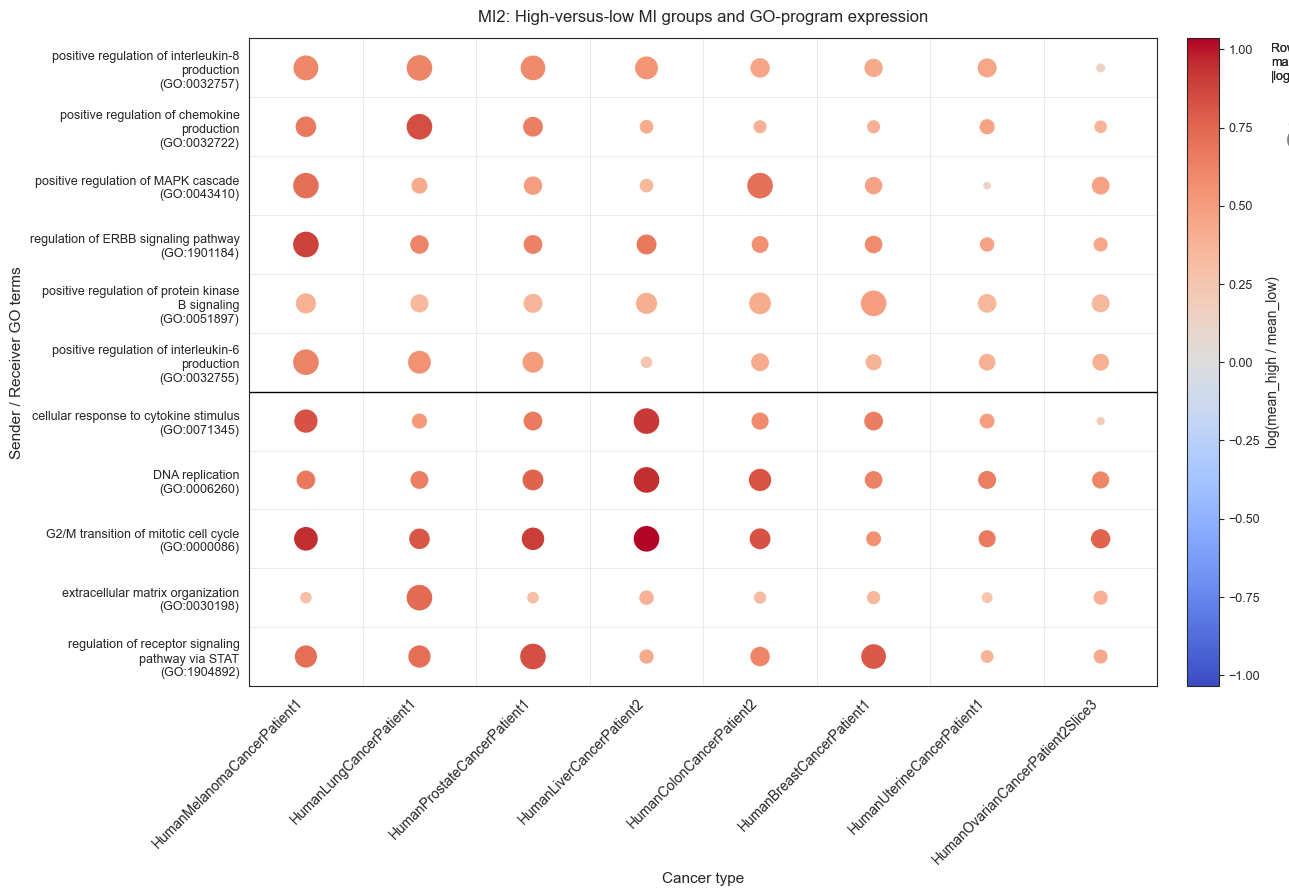

Saved dot plot to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_dotplot_rowMaxNorm.png and D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_dotplot_rowMaxNorm.pdf
Saved color matrix to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_dotplot_colorMatrix.csv
Saved size matrix to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_dotplot_sizeMatrix_rowMaxNorm.csv
Saved column order to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI2_GO_correlation\MI2_sender_receiver_go_medianSplit_logFC_dotplot_column_order_by_colSum.csv


In [50]:
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ------------------------------------------------------------------
# Global plotting style
# ------------------------------------------------------------------
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
    }
)


# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def wrap_go_label(go_term, width=38):
    """Wrap GO-term text and move the accession to a separate line."""
    go_term = str(go_term).strip()
    m = re.match(r"^(.*?)(\s*\(\s*GO:\d+\s*\))$", go_term)
    if m:
        main_text = m.group(1).strip()
        go_id = m.group(2).strip()
    else:
        main_text = go_term
        go_id = ""

    wrapped = "\n".join(textwrap.wrap(main_text, width=width))
    if go_id != "":
        wrapped = wrapped + "\n" + go_id
    return wrapped


def make_row_label(side, go_term):
    return f"{side} | {go_term}"


def rowwise_max_normalize_abs(df):
    """
    Row-wise max normalization on absolute values.
    For each row:
        norm_ij = abs(x_ij) / max_j(abs(x_ij))
    If a row is all zeros or all NaNs, keep as NaN/0 safely.
    """
    abs_df = df.abs()
    row_max = abs_df.max(axis=1, skipna=True).replace(0, np.nan)
    norm_df = abs_df.div(row_max, axis=0)
    return norm_df


# ------------------------------------------------------------------
# Main plotting function
# ------------------------------------------------------------------
def plot_mi_go_logfc_dotplot(
    mi_go_effect_summary_df,
    sender_go_terms_order,
    receiver_go_terms_order,
    mi_label,
    MI_GO_OUTPUT_DIR,
    min_dot_size=20,
    max_dot_size=340,
    sort_columns_by="colsum",   # "colsum" or "none"
    show_grid=True,
):
    """
    Dot plot:
    - rows = sender GO terms + receiver GO terms
    - columns = cancer types
    - color = raw logFC
    - size = row-wise max-normalized abs(logFC)

    Notes:
    - Row-wise normalization is done within each GO-term row across cancer types.
    - Missing values are not plotted.
    """

    # --------------------------------------------------------------
    # 1. Build plotting dataframe
    # --------------------------------------------------------------
    plot_rows = []
    for _, row in mi_go_effect_summary_df.iterrows():
        plot_rows.append(
            {
                "Side": row["Side"],
                "CancerType": row["CancerType"],
                "GO_Term": row["GO_Term"],
                "RowLabel": make_row_label(row["Side"], row["GO_Term"]),
                "effect_value": row["log_fc_high_vs_low"],
                "n_cells": row["n_cells"],
                "n_high": row["n_high"],
                "n_low": row["n_low"],
                "mean_expr_high": row["mean_expr_high"],
                "mean_expr_low": row["mean_expr_low"],
            }
        )

    plot_summary_df = pd.DataFrame(plot_rows)
    plot_df = plot_summary_df.dropna(subset=["effect_value"]).copy()

    # --------------------------------------------------------------
    # 2. Define row order
    # --------------------------------------------------------------
    row_order = (
        [make_row_label("Sender", go_term) for go_term in sender_go_terms_order]
        + [make_row_label("Receiver", go_term) for go_term in receiver_go_terms_order]
    )

    row_to_term = {
        make_row_label("Sender", go_term): go_term for go_term in sender_go_terms_order
    }
    row_to_term.update(
        {
            make_row_label("Receiver", go_term): go_term
            for go_term in receiver_go_terms_order
        }
    )

    plot_df = plot_df[plot_df["RowLabel"].isin(row_order)].copy()

    # --------------------------------------------------------------
    # 3. Construct raw logFC matrix
    # --------------------------------------------------------------
    raw_matrix = (
        plot_df.pivot_table(
            index="RowLabel",
            columns="CancerType",
            values="effect_value",
            aggfunc="mean",
        )
        .reindex(index=row_order)
    )

    # --------------------------------------------------------------
    # 4. Sort cancer types
    # --------------------------------------------------------------
    if sort_columns_by == "colsum":
        col_order_df = (
            raw_matrix.sum(axis=0, skipna=True)
            .sort_values(ascending=False)
            .rename("column_sum_logFC")
            .reset_index()
            .rename(columns={"index": "CancerType"})
        )
        cancer_type_order_sorted = col_order_df["CancerType"].tolist()
    else:
        cancer_type_order_sorted = raw_matrix.columns.tolist()
        col_order_df = pd.DataFrame(
            {
                "CancerType": cancer_type_order_sorted,
                "column_sum_logFC": raw_matrix.sum(axis=0, skipna=True).reindex(cancer_type_order_sorted).values,
            }
        )

    raw_matrix = raw_matrix.reindex(columns=cancer_type_order_sorted)

    # --------------------------------------------------------------
    # 5. Row-wise max-normalized size matrix
    #    size is based on abs(logFC), because dot size cannot be negative
    # --------------------------------------------------------------
    size_matrix = rowwise_max_normalize_abs(raw_matrix)
    size_matrix = np.power(size_matrix,2)

    # --------------------------------------------------------------
    # 6. Prepare long-format dataframe for scatter plotting
    # --------------------------------------------------------------
    plot_long = (
        raw_matrix.stack(dropna=False)
        .rename("logFC")
        .reset_index()
        .rename(columns={"level_0": "RowLabel", "level_1": "CancerType"})
    )

    size_long = (
        size_matrix.stack(dropna=False)
        .rename("size_norm")
        .reset_index()
        .rename(columns={"level_0": "RowLabel", "level_1": "CancerType"})
    )

    plot_long = plot_long.merge(size_long, on=["RowLabel", "CancerType"], how="left")
    plot_long = plot_long.dropna(subset=["logFC"]).copy()

    # Map x/y positions
    x_map = {ct: i for i, ct in enumerate(cancer_type_order_sorted)}
    y_map = {rl: i for i, rl in enumerate(row_order)}

    plot_long["x"] = plot_long["CancerType"].map(x_map)
    plot_long["y"] = plot_long["RowLabel"].map(y_map)

    # Convert normalized size to actual marker size
    plot_long["dot_size"] = (
        min_dot_size
        + (max_dot_size - min_dot_size) * plot_long["size_norm"].fillna(0)
    )

    # --------------------------------------------------------------
    # 7. Colormap normalization
    # --------------------------------------------------------------
    max_abs_effect = np.nanmax(np.abs(raw_matrix.to_numpy(dtype=float)))
    if not np.isfinite(max_abs_effect) or max_abs_effect == 0:
        max_abs_effect = 1.0

    norm = TwoSlopeNorm(vmin=-max_abs_effect, vcenter=0.0, vmax=max_abs_effect)

    cmap = mpl.cm.get_cmap("coolwarm").copy()
    cmap.set_bad("#F2F2F2")

    # --------------------------------------------------------------
    # 8. Figure size
    # --------------------------------------------------------------
    fig_width = max(8.5, 1.0 * len(cancer_type_order_sorted) + 5.0)
    fig_height = max(6.5, 0.55 * len(row_order) + 3.0)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # --------------------------------------------------------------
    # 9. Scatter plot
    # --------------------------------------------------------------
    sc = ax.scatter(
        plot_long["x"],
        plot_long["y"],
        s=plot_long["dot_size"],
        c=plot_long["logFC"],
        cmap=cmap,
        norm=norm,
        edgecolors="none",
    )

    # --------------------------------------------------------------
    # 10. Axes / ticks
    # --------------------------------------------------------------
    ax.set_xticks(np.arange(len(cancer_type_order_sorted)))
    ax.set_xticklabels(cancer_type_order_sorted, rotation=45, ha="right", fontsize=10)

    ax.set_yticks(np.arange(len(row_order)))
    ax.set_yticklabels(
        [wrap_go_label(row_to_term[row_label]) for row_label in row_order],
        fontsize=9,
    )

    ax.set_xlim(-0.5, len(cancer_type_order_sorted) - 0.5)
    ax.set_ylim(len(row_order) - 0.5, -0.5)  # invert y-axis manually

    if show_grid:
        ax.set_xticks(np.arange(-0.5, len(cancer_type_order_sorted), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(row_order), 1), minor=True)
        ax.grid(which="minor", color="#EAEAEA", linestyle="-", linewidth=0.7)
        ax.tick_params(which="minor", bottom=False, left=False)

    # Separate sender and receiver blocks
    if len(sender_go_terms_order) > 0 and len(receiver_go_terms_order) > 0:
        ax.axhline(y=len(sender_go_terms_order) - 0.5, color="black", linewidth=1.0)

    ax.set_xlabel("Cancer type", fontsize=11)
    ax.set_ylabel("Sender / Receiver GO terms", fontsize=11)
    ax.set_title(
        f"{mi_label}: High-versus-low MI groups and GO-program expression",
        fontsize=12,
        pad=12,
    )

    # --------------------------------------------------------------
    # 11. Colorbar
    # --------------------------------------------------------------
    cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("log(mean_high / mean_low)", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    # --------------------------------------------------------------
    # 12. Size legend
    # --------------------------------------------------------------
    size_legend_vals = [0.25, 0.5, 0.75, 1.0]
    size_legend_handles = []
    for v in size_legend_vals:
        s = min_dot_size + (max_dot_size - min_dot_size) * v
        h = ax.scatter([], [], s=s, color="gray", edgecolors="none")
        size_legend_handles.append(h)

    legend = ax.legend(
        size_legend_handles,
        [f"{v:.2f}" for v in size_legend_vals],
        title="Row-wise\nmax-normalized\n|logFC|",
        scatterpoints=1,
        frameon=False,
        fontsize=8,
        title_fontsize=9,
        loc="upper left",
        bbox_to_anchor=(1.12, 1.00),
        borderaxespad=0,
    )
    ax.add_artist(legend)

    fig.tight_layout()

    # --------------------------------------------------------------
    # 13. Save outputs
    # --------------------------------------------------------------
    plot_base = MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_medianSplit_logFC_dotplot_rowMaxNorm"

    fig.savefig(f"{plot_base}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{plot_base}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    raw_matrix.to_csv(
        MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_medianSplit_logFC_dotplot_colorMatrix.csv"
    )
    size_matrix.to_csv(
        MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_medianSplit_logFC_dotplot_sizeMatrix_rowMaxNorm.csv"
    )
    col_order_df.to_csv(
        MI_GO_OUTPUT_DIR / f"{mi_label}_sender_receiver_go_medianSplit_logFC_dotplot_column_order_by_colSum.csv",
        index=False,
    )

    print(f"Saved dot plot to: {plot_base}.png and {plot_base}.pdf")
    print(
        "Saved color matrix to: "
        f"{MI_GO_OUTPUT_DIR / f'{mi_label}_sender_receiver_go_medianSplit_logFC_dotplot_colorMatrix.csv'}"
    )
    print(
        "Saved size matrix to: "
        f"{MI_GO_OUTPUT_DIR / f'{mi_label}_sender_receiver_go_medianSplit_logFC_dotplot_sizeMatrix_rowMaxNorm.csv'}"
    )
    print(
        "Saved column order to: "
        f"{MI_GO_OUTPUT_DIR / f'{mi_label}_sender_receiver_go_medianSplit_logFC_dotplot_column_order_by_colSum.csv'}"
    )


# ------------------------------------------------------------------
# Run
# ------------------------------------------------------------------
plot_mi_go_logfc_dotplot(
    mi_go_effect_summary_df=mi_go_effect_summary_df,
    sender_go_terms_order=sender_go_terms_order,
    receiver_go_terms_order=receiver_go_terms_order,
    mi_label=mi_label,
    MI_GO_OUTPUT_DIR=MI_GO_OUTPUT_DIR,
    min_dot_size=20,
    max_dot_size=340,
    sort_columns_by="colsum",
    show_grid=True,
)

## In-silico knockout of top regulators and targets based on the loading

In [53]:
from pathlib import Path
import gc
import os
import pickle

import numpy as np
import pandas as pd
import torch

from SpiderNet.api import build_model

MI_PERTURB = "MI2"
NUM_TOP_FEATURES = 20
LOADING_THRESHOLD = 0.4
PERTURBATION_OUTPUT_DIR = run_dirs["run_dir"] / "MI2_spatial_perturbation"
PERTURBATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def ensure_processed_loaded():
    """Reload processed objects from disk if they are not already in memory."""
    if "processed" not in globals() or processed is None:
        from SpiderNet.io import load_processed_data
        return load_processed_data(run_dirs["run_dir"])
    return processed


processed = ensure_processed_loaded()


def ensure_model_loaded(processed_obj, checkpoint_path, cfg, device_name):
    """Build the model and load the trained checkpoint if the model is absent."""
    if "model" in globals() and model is not None:
        return model.to(device_name).eval()

    model_obj = build_model(
        processed=processed_obj,
        train_cfg=cfg,
        device=device_name,
    )

    checkpoint = torch.load(checkpoint_path, map_location=device_name)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif isinstance(checkpoint, dict):
        state_dict = checkpoint
    else:
        raise ValueError(
            "Unsupported checkpoint format. Expected a state-dict-like object, "
            f"but got: {type(checkpoint)}"
        )

    model_obj.load_state_dict(state_dict, strict=True)
    model_obj = model_obj.to(device_name)
    model_obj.eval()
    return model_obj


model = ensure_model_loaded(
    processed_obj=processed,
    checkpoint_path=reference_model_path,
    cfg=train_cfg,
    device_name=device,
)


def get_training_gene_names(processed_obj):
    """Return the training gene names as a NumPy string array."""
    if hasattr(processed_obj, "genenames_train") and processed_obj.genenames_train is not None:
        gene_names = processed_obj.genenames_train
        if hasattr(gene_names, "values"):
            gene_names = gene_names.values
        return np.asarray(gene_names).astype(str)
    return np.asarray(processed_obj.adata_list[0].var_names).astype(str)


GENE_NAMES_TRAIN = get_training_gene_names(processed)
GENE_INDEX_MAP = {gene: idx for idx, gene in enumerate(GENE_NAMES_TRAIN)}


def load_loading_matrices(run_dir, gene_names_train):
    """Load sender, receiver, and LR loading matrices from the saved result directory."""
    loading_receiver = np.load(run_dir / "loading_receiver_use.npy")
    loading_sender = np.load(run_dir / "loading_sender_use.npy")
    loading_lr = np.load(run_dir / "loading_LR_use.npy")

    mi_names = [f"MI{i + 1}" for i in range(loading_sender.shape[0])]

    loading_receiver_df = pd.DataFrame(loading_receiver, index=mi_names, columns=gene_names_train)
    loading_sender_df = pd.DataFrame(loading_sender, index=mi_names, columns=gene_names_train)

    with open(run_dir / "LR_list.pkl", "rb") as handle:
        lr_list = pickle.load(handle)

    lr_labels = []
    for ligand, receptor in lr_list:
        ligand_str = "+".join(np.asarray(ligand).astype(str).tolist())
        receptor_str = "+".join(np.asarray(receptor).astype(str).tolist())
        lr_labels.append(f"{ligand_str} -> {receptor_str}")

    loading_lr_df = pd.DataFrame(loading_lr, index=mi_names, columns=lr_labels)
    return loading_sender_df, loading_receiver_df, loading_lr_df


loading_sender_df, loading_receiver_df, loading_lr_df = load_loading_matrices(
    run_dirs["run_dir"],
    GENE_NAMES_TRAIN,
)


def normalize_by_column_sum(df, use_absolute=True):
    """Column-wise normalization with zero-safe denominators."""
    denom = df.abs().sum(axis=0) if use_absolute else df.sum(axis=0)
    denom = denom.replace(0, 1.0)
    return df.div(denom, axis=1).fillna(0.0)


loading_sender_norm = normalize_by_column_sum(loading_sender_df, use_absolute=True)
loading_receiver_norm = normalize_by_column_sum(loading_receiver_df, use_absolute=True)
loading_lr_norm = normalize_by_column_sum(loading_lr_df, use_absolute=False)


def get_top_feature_table(mi_name, n_top=20, loading_threshold=0.3):
    """Assemble the top ligands, receptors, sender genes, and receiver genes for one MI."""
    sender_series = loading_sender_norm.loc[mi_name].sort_values(ascending=False)
    receiver_series = loading_receiver_norm.loc[mi_name].sort_values(ascending=False)
    lr_series = loading_lr_norm.loc[mi_name].sort_values(ascending=False)

    top_sender = sender_series[sender_series > loading_threshold].head(n_top).index.tolist()
    top_receiver = receiver_series[receiver_series > loading_threshold].head(n_top).index.tolist()
    top_lr = lr_series[lr_series > loading_threshold].head(n_top).index.tolist()

    top_ligands = []
    top_receptors = []
    for lr_label in top_lr:
        ligand_str, receptor_str = lr_label.split(" -> ")
        top_ligands.extend([g for g in ligand_str.split("+") if g])
        top_receptors.extend([g for g in receptor_str.split("+") if g])

    top_ligands = sorted(pd.unique(pd.Series(top_ligands, dtype=str)).tolist()) if len(top_ligands) > 0 else []
    top_receptors = sorted(pd.unique(pd.Series(top_receptors, dtype=str)).tolist()) if len(top_receptors) > 0 else []

    topgene_df = pd.DataFrame(
        {
            "Genes": top_ligands + top_receptors + top_sender + top_receiver,
            "Type": (
                ["Ligand"] * len(top_ligands)
                + ["Receptor"] * len(top_receptors)
                + ["Top Sender"] * len(top_sender)
                + ["Top Receiver"] * len(top_receiver)
            ),
            "MI": mi_name,
        }
    ).drop_duplicates(ignore_index=True)

    return topgene_df, top_lr


topgene_df_mi2, toplr_mi2 = get_top_feature_table(
    MI_PERTURB,
    n_top=NUM_TOP_FEATURES,
    loading_threshold=LOADING_THRESHOLD,
)


def go_result_to_gene_table(go_result_df):
    """Expand a GO enrichment result table into a GO-term to gene mapping table."""
    gene_table = (
        go_result_df.loc[:, ["Term", "Genes"]]
        .assign(
            Gene=lambda d: (
                d["Genes"]
                .fillna("")
                .astype(str)
                .str.split(r"\s*;\s*")
            )
        )
        .explode("Gene")
        .rename(columns={"Term": "GO_Term"})
        .drop(columns=["Genes"])
    )
    gene_table["Gene"] = gene_table["Gene"].astype(str).str.strip()
    gene_table = gene_table[gene_table["Gene"] != ""].drop_duplicates(["Gene", "GO_Term"])
    return gene_table.reset_index(drop=True)



def keep_unique_genesets(go_gene_df):
    """Keep only one GO term for duplicated gene sets."""
    go_to_genes = go_gene_df.groupby("GO_Term")["Gene"].apply(
        lambda s: frozenset(str(x).strip() for x in s.dropna().unique())
    )

    seen_gene_sets = {}
    go_keep = []
    for go_term, gene_set in go_to_genes.items():
        if gene_set not in seen_gene_sets:
            seen_gene_sets[gene_set] = go_term
            go_keep.append(go_term)

    return go_gene_df[go_gene_df["GO_Term"].isin(go_keep)].copy().reset_index(drop=True)


sender_go_path = run_dirs["run_dir"] / "GO_enrichment_topregulator_MI2.csv"
receiver_go_path = run_dirs["run_dir"] / "GO_enrichment_toptarget_MI2.csv"

if not sender_go_path.exists() or not receiver_go_path.exists():
    raise FileNotFoundError(
        "GO enrichment tables for MI2 were not found. "
        "Please run the GO enrichment cells above before executing the perturbation section."
    )

sender_go_gene_table = keep_unique_genesets(
    go_result_to_gene_table(pd.read_csv(sender_go_path))
)
receiver_go_gene_table = keep_unique_genesets(
    go_result_to_gene_table(pd.read_csv(receiver_go_path))
)

excluded_genes = set(sender_go_gene_table["Gene"].tolist()) | set(receiver_go_gene_table["Gene"].tolist())
topgene_df_mi2_filtered = topgene_df_mi2[~topgene_df_mi2["Genes"].isin(excluded_genes)].copy().reset_index(drop=True)

knockout_upstream_genes = topgene_df_mi2_filtered[
    topgene_df_mi2_filtered["Type"].isin(["Ligand", "Top Sender"])
]["Genes"].tolist()
knockout_downstream_genes = topgene_df_mi2_filtered[
    topgene_df_mi2_filtered["Type"].isin(["Receptor", "Top Receiver"])
]["Genes"].tolist()

knockout_upstream_geneindex = [GENE_INDEX_MAP[g] for g in knockout_upstream_genes if g in GENE_INDEX_MAP]
knockout_downstream_geneindex = [GENE_INDEX_MAP[g] for g in knockout_downstream_genes if g in GENE_INDEX_MAP]

all_cell_types = sorted(
    pd.unique(
        pd.concat(
            [
                pd.Series(adata_i.obs[CELL_TYPE_COL].astype(str).values)
                for adata_i in processed.adata_list
            ],
            ignore_index=True,
        )
    ).tolist()
)
tumor_cell_types = sorted([ct for ct in all_cell_types if ct.endswith("-cancercell")])

batch_sample_ids = [
    str(np.asarray(processed.spidernet_data[i]["sample"])[0])
    for i in range(len(processed.spidernet_data))
]
batch_cancer_types = [sample_id.split("_")[0] for sample_id in batch_sample_ids]
unique_cancer_types = sorted(pd.unique(pd.Series(batch_cancer_types, dtype=str)).tolist())

print(f"Perturbation target: {MI_PERTURB}")
print(f"Number of upstream knockout genes: {len(knockout_upstream_geneindex)}")
print(f"Number of downstream knockout genes: {len(knockout_downstream_geneindex)}")
print("Tumor cell types used for both sender and receiver:")
print(tumor_cell_types)
print("Top MI2 feature table after removing GO genes:")
display(topgene_df_mi2_filtered)

Perturbation target: MI2
Number of upstream knockout genes: 11
Number of downstream knockout genes: 10
Tumor cell types used for both sender and receiver:
['Breast-cancercell', 'Colon-cancercell', 'Liver-cancercell', 'Lung-cancercell', 'Melanoma-cancercell', 'Ovarian-cancercell', 'Prostate-cancercell', 'Uterine-cancercell']
Top MI2 feature table after removing GO genes:


,Genes,Type,MI
0,FGF2,Ligand,MI2
1,ITGA1,Receptor,MI2
2,ITGB1,Receptor,MI2
3,MUC2,Top Sender,MI2
4,CA9,Top Sender,MI2
5,PPARGC1A,Top Sender,MI2
6,CCL28,Top Sender,MI2
7,CCR6,Top Sender,MI2
8,LAMB3,Top Sender,MI2
9,WNT3,Top Sender,MI2


In [54]:
toplr_mi2

['CDH1 -> ITGA1+ITGB1', 'CDH1 -> CDH1', 'FGF2 -> FGFR3']

In [56]:
from collections import OrderedDict


def to_device_copy(data_obj, device_name):
    """Clone a PyG data object and move it to the requested device."""
    data_copy = data_obj.clone()
    if hasattr(data_copy, "to"):
        data_copy = data_copy.to(device_name)
    return data_copy


def extract_reconstruction_tensor(model_output):
    """Extract the reconstructed expression tensor from different model-output formats."""
    if torch.is_tensor(model_output):
        return model_output

    if isinstance(model_output, (tuple, list)) and len(model_output) > 0:
        first_item = model_output[0]
        if torch.is_tensor(first_item):
            return first_item

    if isinstance(model_output, dict):
        for key in [
            "exprecon",
            "expression_reconstruction",
            "x_recon",
            "reconstruction",
            "expr_recon",
        ]:
            if key in model_output and torch.is_tensor(model_output[key]):
                return model_output[key]

    raise ValueError(
        "Could not identify the reconstructed expression tensor from the model output."
    )


def get_go_average_expression(expr_matrix, go_gene_table, gene_index_map):
    """Compute per-cell average reconstructed expression for each GO program."""
    go_avg = OrderedDict()
    for go_term in pd.unique(go_gene_table["GO_Term"]):
        genes_cur = go_gene_table.loc[go_gene_table["GO_Term"] == go_term, "Gene"].astype(str).tolist()
        gene_idx_cur = [gene_index_map[g] for g in genes_cur if g in gene_index_map]
        if len(gene_idx_cur) == 0:
            continue
        go_avg[go_term] = expr_matrix[:, gene_idx_cur].mean(axis=1)
    return go_avg


def compute_log2fc_dict(avg_expr_a_dict, avg_expr_b_dict, eps=1e-8):
    """
    Compute log2 fold change for each GO term:
    log2((A + eps) / (B + eps))

    Here:
    A = knockout
    B = original
    """
    out = OrderedDict()
    common_terms = [go_term for go_term in avg_expr_a_dict.keys() if go_term in avg_expr_b_dict]

    for go_term in common_terms:
        a = np.asarray(avg_expr_a_dict[go_term], dtype=np.float32)
        b = np.asarray(avg_expr_b_dict[go_term], dtype=np.float32)
        out[go_term] = np.log2((a + eps) / (b + eps)).astype(np.float32, copy=False)

    return out


def append_nested_results(store_dict, outer_key, inner_dict):
    """Append arrays from one batch into a nested cancer-type dictionary."""
    if outer_key not in store_dict:
        store_dict[outer_key] = {}

    for inner_key, values in inner_dict.items():
        if inner_key not in store_dict[outer_key]:
            store_dict[outer_key][inner_key] = []
        store_dict[outer_key][inner_key].extend(np.asarray(values, dtype=float).tolist())


exprecon_diff_list_sender_cancertype = {}
exprecon_diff_list_receiver_cancertype = {}
perturbation_batch_summary = []

LOGFC_EPS = 1e-8

for cancer_type_cur in unique_cancer_types:
    batch_indices_cur = [
        i for i, ct in enumerate(batch_cancer_types)
        if ct == cancer_type_cur
    ]

    print(f"Running MI2 perturbation for cancer type: {cancer_type_cur} ({len(batch_indices_cur)} batches)")

    for batch_idx in batch_indices_cur:
        adata_batch = processed.adata_list[batch_idx]
        cell_types_batch = adata_batch.obs[CELL_TYPE_COL].astype(str).values

        sender_idx = np.where(np.isin(cell_types_batch, tumor_cell_types))[0]
        receiver_idx = np.where(np.isin(cell_types_batch, tumor_cell_types))[0]

        if sender_idx.size == 0 or receiver_idx.size == 0:
            perturbation_batch_summary.append(
                {
                    "CancerType": cancer_type_cur,
                    "BatchIndex": batch_idx,
                    "SampleID": batch_sample_ids[batch_idx],
                    "n_sender_cells": int(sender_idx.size),
                    "n_receiver_cells": int(receiver_idx.size),
                    "status": "skipped_no_tumor_cells",
                }
            )
            continue

        data_original = to_device_copy(processed.spidernet_data[batch_idx], device)
        data_knockout = to_device_copy(processed.spidernet_data[batch_idx], device)

        if len(knockout_upstream_geneindex) > 0:
            data_knockout.x[
                torch.as_tensor(sender_idx, device=data_knockout.x.device).unsqueeze(1),
                torch.as_tensor(knockout_upstream_geneindex, device=data_knockout.x.device),
            ] = 0.0

        if len(knockout_downstream_geneindex) > 0:
            data_knockout.x[
                torch.as_tensor(receiver_idx, device=data_knockout.x.device).unsqueeze(1),
                torch.as_tensor(knockout_downstream_geneindex, device=data_knockout.x.device),
            ] = 0.0

        with torch.no_grad():
            exprecon_original = extract_reconstruction_tensor(model(data_original))
            exprecon_knockout = extract_reconstruction_tensor(model(data_knockout))

        exprecon_original = exprecon_original.detach().cpu().numpy().astype(np.float32)
        exprecon_knockout = exprecon_knockout.detach().cpu().numpy().astype(np.float32)

        sender_original = exprecon_original[sender_idx, :]
        sender_knockout = exprecon_knockout[sender_idx, :]
        receiver_original = exprecon_original[receiver_idx, :]
        receiver_knockout = exprecon_knockout[receiver_idx, :]

        sender_go_original = get_go_average_expression(
            sender_original,
            sender_go_gene_table,
            GENE_INDEX_MAP,
        )
        sender_go_knockout = get_go_average_expression(
            sender_knockout,
            sender_go_gene_table,
            GENE_INDEX_MAP,
        )
        receiver_go_original = get_go_average_expression(
            receiver_original,
            receiver_go_gene_table,
            GENE_INDEX_MAP,
        )
        receiver_go_knockout = get_go_average_expression(
            receiver_knockout,
            receiver_go_gene_table,
            GENE_INDEX_MAP,
        )

        # log2 fold change: log2(knockout / original)
        sender_go_diff = compute_log2fc_dict(
            avg_expr_a_dict=sender_go_knockout,
            avg_expr_b_dict=sender_go_original,
            eps=LOGFC_EPS,
        )
        receiver_go_diff = compute_log2fc_dict(
            avg_expr_a_dict=receiver_go_knockout,
            avg_expr_b_dict=receiver_go_original,
            eps=LOGFC_EPS,
        )
        
        # sender_go_diff = {
        #     go_term: sender_go_knockout[go_term] - sender_go_original[go_term]
        #     for go_term in sender_go_original.keys()
        #     if go_term in sender_go_knockout
        # }
        # receiver_go_diff = {
        #     go_term: receiver_go_knockout[go_term] - receiver_go_original[go_term]
        #     for go_term in receiver_go_original.keys()
        #     if go_term in receiver_go_knockout
        # }

        append_nested_results(exprecon_diff_list_sender_cancertype, cancer_type_cur, sender_go_diff)
        append_nested_results(exprecon_diff_list_receiver_cancertype, cancer_type_cur, receiver_go_diff)

        perturbation_batch_summary.append(
            {
                "CancerType": cancer_type_cur,
                "BatchIndex": batch_idx,
                "SampleID": batch_sample_ids[batch_idx],
                "n_sender_cells": int(sender_idx.size),
                "n_receiver_cells": int(receiver_idx.size),
                "status": "finished",
            }
        )

        release_memory(
            "adata_batch",
            "cell_types_batch",
            "data_original",
            "data_knockout",
            "exprecon_original",
            "exprecon_knockout",
            "sender_original",
            "sender_knockout",
            "receiver_original",
            "receiver_knockout",
            "sender_go_original",
            "sender_go_knockout",
            "receiver_go_original",
            "receiver_go_knockout",
            "sender_go_diff",
            "receiver_go_diff",
            namespace=globals(),
            run_gc=True,
            clear_cuda=True,
        )

perturbation_batch_summary_df = pd.DataFrame(perturbation_batch_summary)
perturbation_batch_summary_df.to_csv(
    PERTURBATION_OUTPUT_DIR / f"{MI_PERTURB}_perturbation_batch_summary.csv",
    index=False,
)

with open(PERTURBATION_OUTPUT_DIR / f"{MI_PERTURB}_sender_go_diff.pkl", "wb") as handle:
    pickle.dump(exprecon_diff_list_sender_cancertype, handle)
with open(PERTURBATION_OUTPUT_DIR / f"{MI_PERTURB}_receiver_go_diff.pkl", "wb") as handle:
    pickle.dump(exprecon_diff_list_receiver_cancertype, handle)

print("Finished MI2 perturbation analysis.")
display(perturbation_batch_summary_df)

Running MI2 perturbation for cancer type: HumanBreastCancerPatient1 (20 batches)
Running MI2 perturbation for cancer type: HumanColonCancerPatient2 (20 batches)
Running MI2 perturbation for cancer type: HumanLiverCancerPatient2 (20 batches)
Running MI2 perturbation for cancer type: HumanLungCancerPatient1 (20 batches)
Running MI2 perturbation for cancer type: HumanMelanomaCancerPatient1 (20 batches)
Running MI2 perturbation for cancer type: HumanOvarianCancerPatient2Slice3 (20 batches)
Running MI2 perturbation for cancer type: HumanProstateCancerPatient1 (20 batches)
Running MI2 perturbation for cancer type: HumanUterineCancerPatient1 (20 batches)
Finished MI2 perturbation analysis.


,CancerType,BatchIndex,SampleID,n_sender_cells,n_receiver_cells,status
0,HumanBreastCancerPatient1,0,HumanBreastCancerPatient1_subslice0,26090,26090,finished
1,HumanBreastCancerPatient1,1,HumanBreastCancerPatient1_subslice1,23753,23753,finished
2,HumanBreastCancerPatient1,2,HumanBreastCancerPatient1_subslice10,17482,17482,finished
3,HumanBreastCancerPatient1,3,HumanBreastCancerPatient1_subslice11,23113,23113,finished
4,HumanBreastCancerPatient1,4,HumanBreastCancerPatient1_subslice12,16479,16479,finished
...,...,...,...,...,...,...
155,HumanUterineCancerPatient1,155,HumanUterineCancerPatient1_subslice5,36927,36927,finished
156,HumanUterineCancerPatient1,156,HumanUterineCancerPatient1_subslice6,22089,22089,finished
157,HumanUterineCancerPatient1,157,HumanUterineCancerPatient1_subslice7,35885,35885,finished
158,HumanUterineCancerPatient1,158,HumanUterineCancerPatient1_subslice8,24654,24654,finished


C:\Users\junji\AppData\Local\Temp\ipykernel_50492\3410348472.py:311: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_50492\3410348472.py:311: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_50492\3410348472.py:311: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_50492\3410348472.py:311: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

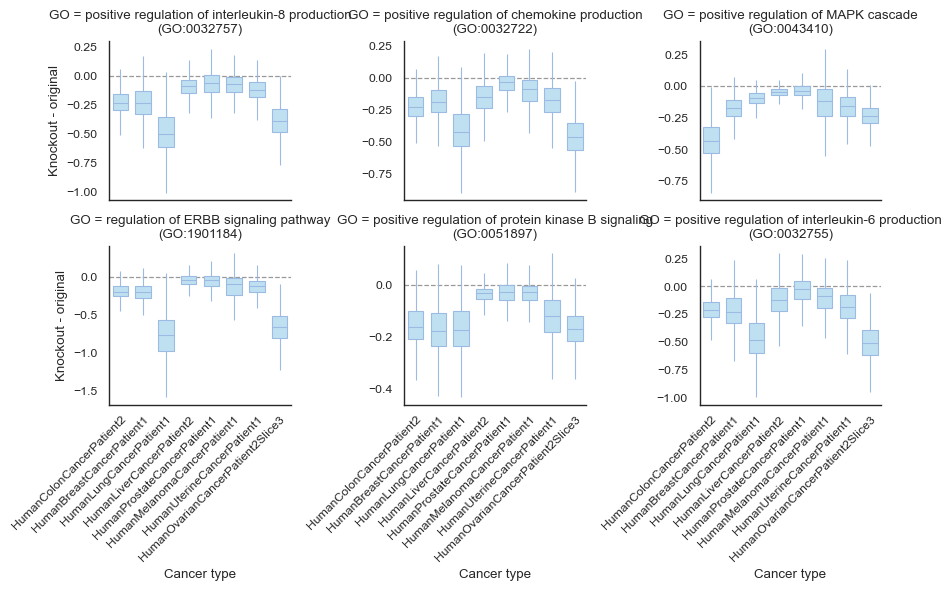

C:\Users\junji\AppData\Local\Temp\ipykernel_50492\3410348472.py:311: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_50492\3410348472.py:311: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_50492\3410348472.py:311: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_50492\3410348472.py:311: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

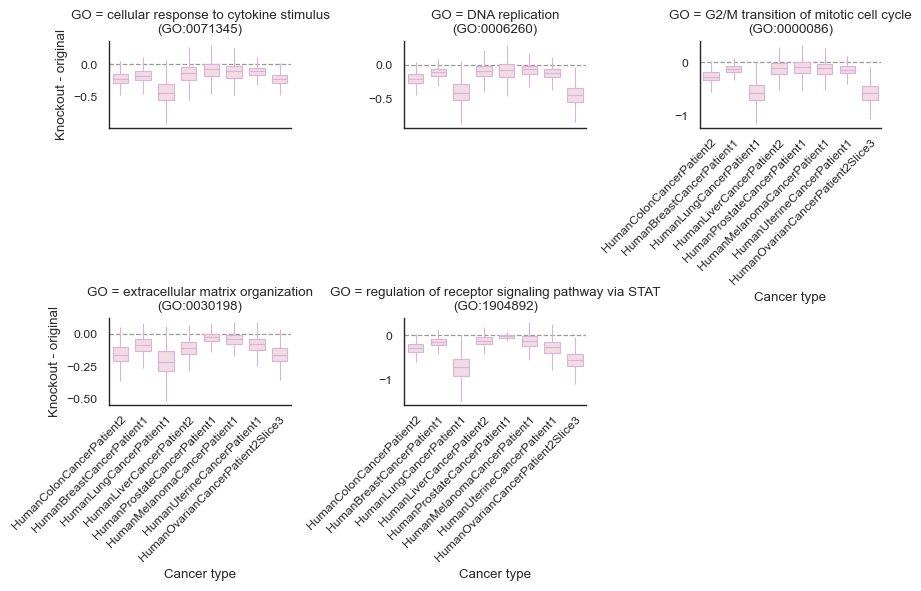

In [67]:
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
    }
)
sns.set_theme(style="white", context="paper")


def nested_dict_to_long_df(d, cancer_key="CancerType", go_key="GO", value_key="Value"):
    """Convert a nested cancer-type dictionary into a long-form DataFrame."""
    rows = []
    for cancer_type, go_dict in d.items():
        if go_dict is None:
            continue
        for go_term, vals in go_dict.items():
            if vals is None:
                continue
            if isinstance(vals, (list, tuple, np.ndarray, pd.Series)):
                for value in vals:
                    if pd.isna(value):
                        continue
                    rows.append(
                        {
                            cancer_key: cancer_type,
                            go_key: go_term,
                            value_key: float(value),
                        }
                    )
            else:
                if not pd.isna(vals):
                    rows.append(
                        {
                            cancer_key: cancer_type,
                            go_key: go_term,
                            value_key: float(vals),
                        }
                    )
    return pd.DataFrame(rows)


def wilcoxon_against_zero(values):
    """
    One-sample Wilcoxon signed-rank test against zero.

    Returns:
        dict with:
            - n
            - mean
            - median
            - p_less_0
            - p_greater_0
            - p_two_sided
    """
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    n_vals = int(values.size)

    result_dict = {
        "n": n_vals,
        "mean": np.nan,
        "median": np.nan,
        "p_less_0": np.nan,
        "p_greater_0": np.nan,
        "p_two_sided": np.nan,
    }

    if n_vals == 0:
        return result_dict

    result_dict["mean"] = float(np.mean(values))
    result_dict["median"] = float(np.median(values))

    if n_vals < 3:
        return result_dict

    if np.allclose(values, 0):
        result_dict["p_less_0"] = 1.0
        result_dict["p_greater_0"] = 1.0
        result_dict["p_two_sided"] = 1.0
        return result_dict

    try:
        result_dict["p_less_0"] = float(
            wilcoxon(values, alternative="less", zero_method="wilcox").pvalue
        )
    except Exception:
        pass

    try:
        result_dict["p_greater_0"] = float(
            wilcoxon(values, alternative="greater", zero_method="wilcox").pvalue
        )
    except Exception:
        pass

    try:
        result_dict["p_two_sided"] = float(
            wilcoxon(values, alternative="two-sided", zero_method="wilcox").pvalue
        )
    except Exception:
        pass

    return result_dict


def wrap_go_title(go_term):
    """Move the GO accession to a second line for compact facet titles."""
    return re.sub(r"\s*(\(\s*GO:\d+\s*\))\s*$", r"\n\1", str(go_term).strip())


def make_row_label(side, go_term):
    return f"{side} | {go_term}"


def rowwise_minmax_norm(x):
    """
    Row-wise min-max normalization.
    Returns values in [0, 1].
    If a row has constant values or <2 finite values, assign 1.0 to finite entries.
    """
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    finite_mask = np.isfinite(x)
    if finite_mask.sum() == 0:
        return out

    vals = x[finite_mask]
    vmin = np.min(vals)
    vmax = np.max(vals)

    if np.isclose(vmax, vmin):
        out[finite_mask] = 1.0
    else:
        out[finite_mask] = (vals - vmin) / (vmax - vmin)

    return out


def compute_cancer_order_from_spearman_corr(
    mi_go_corr_summary_df,
    sender_go_terms_order,
    receiver_go_terms_order,
):
    """
    Compute cancer-type order from the Spearman-correlation analysis.

    Logic:
    1. Use spearman_r from mi_go_corr_summary_df
    2. Build Sender/Receiver row labels
    3. Row-wise min-max normalize
    4. Average normalized Spearman corr within each cancer type
    5. Sort descending
    """
    plot_rows = []
    for _, row in mi_go_corr_summary_df.iterrows():
        plot_rows.append(
            {
                "Side": row["Side"],
                "CancerType": row["CancerType"],
                "GO_Term": row["GO_Term"],
                "RowLabel": make_row_label(row["Side"], row["GO_Term"]),
                "corr_value": row["spearman_r"],
            }
        )

    plot_df = pd.DataFrame(plot_rows)
    plot_df = plot_df.dropna(subset=["corr_value"]).copy()
    plot_df = plot_df[plot_df["CancerType"].astype(str) != "Pooled"].copy()

    row_order = (
        [make_row_label("Sender", go_term) for go_term in sender_go_terms_order]
        + [make_row_label("Receiver", go_term) for go_term in receiver_go_terms_order]
    )
    plot_df = plot_df[plot_df["RowLabel"].isin(row_order)].copy()

    plot_df["corr_norm_row"] = np.nan
    for row_label in row_order:
        idx = plot_df["RowLabel"] == row_label
        if idx.any():
            plot_df.loc[idx, "corr_norm_row"] = rowwise_minmax_norm(
                plot_df.loc[idx, "corr_value"].to_numpy(dtype=float)
            )

    order_df = (
        plot_df.groupby("CancerType", observed=True)["corr_norm_row"]
        .agg(["mean", "median", "count"])
        .reset_index()
        .rename(
            columns={
                "mean": "mean_normalized_spearman_corr",
                "median": "median_normalized_spearman_corr",
                "count": "n_values",
            }
        )
        .sort_values(
            ["mean_normalized_spearman_corr", "median_normalized_spearman_corr", "CancerType"],
            ascending=[False, False, True],
        )
        .reset_index(drop=True)
    )
    order_df["common_order_rank"] = np.arange(1, len(order_df) + 1)

    cancer_order = order_df["CancerType"].tolist()
    return cancer_order, order_df


def build_wilcoxon_stats_df(df_long, side_name):
    """
    Run one-sample Wilcoxon signed-rank test against 0 for each GO x CancerType boxplot.
    """
    test_rows = []
    for (go_term, cancer_type), sub_df in df_long.groupby(["GO", "CancerType"], observed=True):
        stats_dict = wilcoxon_against_zero(sub_df["Value"].values)
        test_rows.append(
            {
                "Side": side_name,
                "GO": go_term,
                "CancerType": cancer_type,
                "n": stats_dict["n"],
                "mean": stats_dict["mean"],
                "median": stats_dict["median"],
                "p_less_0": stats_dict["p_less_0"],
                "p_greater_0": stats_dict["p_greater_0"],
                "p_two_sided": stats_dict["p_two_sided"],
                "is_sig_less_p05": (
                    stats_dict["p_less_0"] < 0.05 if pd.notna(stats_dict["p_less_0"]) else False
                ),
                "is_sig_two_sided_p05": (
                    stats_dict["p_two_sided"] < 0.05 if pd.notna(stats_dict["p_two_sided"]) else False
                ),
            }
        )

    test_df = pd.DataFrame(test_rows).sort_values(
        ["Side", "GO", "CancerType"]
    ).reset_index(drop=True)

    return test_df


def plot_knockout_go_boxplots(
    result_dict,
    output_prefix,
    fill_color,
    edge_color,
    cancer_order,
    side_name,
    facet_wrap=3,
):
    """
    Plot faceted boxplots of GO-program changes using a precomputed cancer order.
    Also save the long-format data and per-boxplot Wilcoxon statistics.
    """
    df_long = nested_dict_to_long_df(result_dict)
    if df_long.empty:
        raise ValueError(f"No perturbation result is available for {output_prefix}.")

    df_long["Side"] = side_name
    df_long["CancerType"] = pd.Categorical(
        df_long["CancerType"],
        categories=cancer_order,
        ordered=True,
    )

    test_df = build_wilcoxon_stats_df(df_long, side_name=side_name)

    df_long.to_csv(str(output_prefix) + "_longformat.csv", index=False)
    test_df.to_csv(str(output_prefix) + "_wilcoxon_against0_results.csv", index=False)

    significance_lookup = {
        (row["GO"], row["CancerType"]): bool(row["is_sig_less_p05"])
        for _, row in test_df.iterrows()
    }

    grid = sns.FacetGrid(
        df_long,
        col="GO",
        col_wrap=facet_wrap,
        sharey=False,
        height=3.0,
        aspect=1.0,
        despine=False,
    )

    def facet_boxplot(data, **kwargs):
        ax = plt.gca()
        go_term = data["GO"].iloc[0]

        palette = {
            ct: (fill_color if significance_lookup.get((go_term, ct), False) else "#ECECEC")
            for ct in cancer_order
        }

        sns.boxplot(
            data=data,
            x="CancerType",
            y="Value",
            order=cancer_order,
            palette=palette,
            linewidth=0.8,
            showfliers=False,
            width=0.68,
            ax=ax,
            boxprops=dict(edgecolor=edge_color, linewidth=0.8),
            whiskerprops=dict(color=edge_color, linewidth=0.8),
            capprops=dict(color=edge_color, linewidth=0.0, alpha=0.0),
            medianprops=dict(color=edge_color, linewidth=0.8),
        )

        ax.axhline(y=0, linestyle="--", linewidth=0.9, color="0.6", zorder=0)

        ax.tick_params(axis="x", pad=2)
        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha="right",
            va="top",
            rotation_mode="anchor",
        )

        sns.despine(ax=ax)

    grid.map_dataframe(facet_boxplot)

    for ax in grid.axes.flatten():
        raw_title = ax.get_title()
        raw_term = raw_title.split("=", 1)[1].strip() if "=" in raw_title else raw_title.strip()
        ax.set_title("GO = " + wrap_go_title(raw_term))

    grid.set_axis_labels("Cancer type", "Knockout - original")
    plt.tight_layout()
    plt.savefig(str(output_prefix) + ".pdf", bbox_inches="tight")
    plt.savefig(str(output_prefix) + ".png", dpi=300, bbox_inches="tight")
    plt.show()

    return df_long, test_df


# ============================================================
# Build sender / receiver long-format data first
# ============================================================
sender_long_for_plot = nested_dict_to_long_df(exprecon_diff_list_sender_cancertype)
receiver_long_for_plot = nested_dict_to_long_df(exprecon_diff_list_receiver_cancertype)

if sender_long_for_plot.empty:
    raise ValueError("Sender perturbation result is empty.")
if receiver_long_for_plot.empty:
    raise ValueError("Receiver perturbation result is empty.")


# ============================================================
# Compute cancer-type order FROM SPEARMAN-CORR ANALYSIS
# ============================================================
common_cancer_order, common_cancer_order_df = compute_cancer_order_from_spearman_corr(
    mi_go_corr_summary_df=mi_go_corr_summary_df,
    sender_go_terms_order=sender_go_terms_order,
    receiver_go_terms_order=receiver_go_terms_order,
)

common_cancer_order_df.to_csv(
    PERTURBATION_OUTPUT_DIR / f"{MI_PERTURB}_common_cancer_order_from_spearman_corr.csv",
    index=False,
)


# ============================================================
# Plot sender with the Spearman-derived order
# ============================================================
sender_long_df, sender_test_df = plot_knockout_go_boxplots(
    result_dict=exprecon_diff_list_sender_cancertype,
    output_prefix=PERTURBATION_OUTPUT_DIR / f"{MI_PERTURB}_sender_GO_boxplot",
    fill_color="#b7e3f9",
    edge_color="#9BBBE2",
    cancer_order=common_cancer_order,
    side_name="Sender",
    facet_wrap=3,
)


# ============================================================
# Plot receiver with the same Spearman-derived order
# ============================================================
receiver_long_df, receiver_test_df = plot_knockout_go_boxplots(
    result_dict=exprecon_diff_list_receiver_cancertype,
    output_prefix=PERTURBATION_OUTPUT_DIR / f"{MI_PERTURB}_receiver_GO_boxplot",
    fill_color="#f6d7e2",
    edge_color="#D8B5D6",
    cancer_order=common_cancer_order,
    side_name="Receiver",
    facet_wrap=3,
)


# ============================================================
# Combine sender + receiver Wilcoxon results into one dataframe
# ============================================================
combined_wilcoxon_df = pd.concat(
    [sender_test_df, receiver_test_df],
    axis=0,
    ignore_index=True,
).sort_values(["Side", "GO", "CancerType"]).reset_index(drop=True)

combined_wilcoxon_df.to_csv(
    PERTURBATION_OUTPUT_DIR / f"{MI_PERTURB}_sender_receiver_combined_wilcoxon_against0_results.csv",
    index=False,
)


# ============================================================
# Optional: combine long-format data as well
# ============================================================
combined_long_df = pd.concat(
    [sender_long_df, receiver_long_df],
    axis=0,
    ignore_index=True,
).sort_values(["Side", "GO", "CancerType"]).reset_index(drop=True)

combined_long_df.to_csv(
    PERTURBATION_OUTPUT_DIR / f"{MI_PERTURB}_sender_receiver_combined_longformat.csv",
    index=False,
)


# ============================================================
# Release memory
# ============================================================
release_memory(
    "loading_sender_df",
    "loading_receiver_df",
    "loading_lr_df",
    "loading_sender_norm",
    "loading_receiver_norm",
    "loading_lr_norm",
    namespace=globals(),
    run_gc=True,
    clear_cuda=False,
)

In [59]:
# (combined_wilcoxon_df['p_less_0']).tolist()
combined_wilcoxon_df

,Side,GO,CancerType,n,mean,median,p_less_0,p_greater_0,p_two_sided,is_sig_less_p05,is_sig_two_sided_p05
0,Receiver,DNA replication (GO:0006260),HumanBreastCancerPatient1,362510,-0.113696,-0.115770,0.0,1.0,0.0,True,True
1,Receiver,DNA replication (GO:0006260),HumanColonCancerPatient2,520552,-0.200565,-0.211905,0.0,1.0,0.0,True,True
2,Receiver,DNA replication (GO:0006260),HumanLiverCancerPatient2,273713,-0.096909,-0.094209,0.0,1.0,0.0,True,True
3,Receiver,DNA replication (GO:0006260),HumanLungCancerPatient1,250986,-0.394309,-0.418533,0.0,1.0,0.0,True,True
4,Receiver,DNA replication (GO:0006260),HumanMelanomaCancerPatient1,239742,-0.082466,-0.071919,0.0,1.0,0.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...
83,Sender,regulation of ERBB signaling pathway (GO:1901184),HumanLungCancerPatient1,250986,-0.858479,-0.765595,0.0,1.0,0.0,True,True
84,Sender,regulation of ERBB signaling pathway (GO:1901184),HumanMelanomaCancerPatient1,239742,-0.134272,-0.095149,0.0,1.0,0.0,True,True
85,Sender,regulation of ERBB signaling pathway (GO:1901184),HumanOvarianCancerPatient2Slice3,119922,-0.669403,-0.659311,0.0,1.0,0.0,True,True
86,Sender,regulation of ERBB signaling pathway (GO:1901184),HumanProstateCancerPatient1,414867,-0.060379,-0.041989,0.0,1.0,0.0,True,True
